# Stage 1: Data Construction and Feature Engineering
This stage implements the data pipeline promised in the proposal. We build a synchronized multi-asset panel for BTC, ETH, SOL, BNB, and AVAX, clean missing or stale observations, compute daily log returns, and create block-level features such as volume, trade activity, rolling volatility, and rolling cross-asset dependence. The outputs saved here are the common inputs for the exact HMM baseline and for every stochastic-gradient sampler later in the notebook.


Install the lightweight packages needed for data download, preprocessing, and parquet export in Stage 1.


In [5]:
#%pip -q install --upgrade --force-reinstall "numpy==1.26.4" "pandas==2.2.3" "requests>=2.31,<3"

Note: you may need to restart the kernel to use updated packages.


Install a pinned base stack directly into the active Jupyter kernel so the rest of the notebook sees a consistent local environment. If this cell changes `numpy` or `pandas`, restart the kernel once and rerun from the top before continuing.


In [3]:
import time
import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import requests

Define the asset universe, Binance symbols, sample window, and output location for the cleaned dataset.


In [194]:
ASSETS = ["BTC", "ETH", "SOL", "BNB", "AVAX"]

# [Inference] These are the natural Binance spot symbols for a USD-stable quote.
# If you want a different quote currency, change them here.
SYMBOL_MAP = {
    "BTC": "BTCUSDT",
    "ETH": "ETHUSDT",
    "SOL": "SOLUSDT",
    "BNB": "BNBUSDT",
    "AVAX": "AVAXUSDT",
}

START_DATE = "2020-01-01"
END_DATE = None  # use None for "up to now"

PROJECT_DIR = Path.cwd().resolve()
OUT_DIR = PROJECT_DIR / "crypto_stage1_processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def has_parquet_engine() -> bool:
    try:
        import pyarrow  # noqa: F401
        return True
    except ImportError:
        try:
            import fastparquet  # noqa: F401
            return True
        except ImportError:
            return False


TABULAR_EXT = ".parquet" if has_parquet_engine() else ".pkl"
print("Tabular storage format:", TABULAR_EXT)


def table_path(base_path) -> Path:
    base = Path(base_path)
    if base.suffix in {".parquet", ".pkl"}:
        return base
    return base.with_suffix(TABULAR_EXT)



def resolve_table_path(base_path) -> Path:
    base = Path(base_path)
    candidates = []
    if base.suffix in {".parquet", ".pkl"}:
        candidates.append(base)
    else:
        candidates.extend([base.with_suffix(".parquet"), base.with_suffix(".pkl")])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"No saved table found for {base}")



def table_exists(base_path) -> bool:
    try:
        resolve_table_path(base_path)
        return True
    except FileNotFoundError:
        return False



def write_table(df: pd.DataFrame, base_path, index: bool = False) -> Path:
    path = table_path(base_path)

    if path.suffix == ".parquet":
        df.to_parquet(path, index=index)
    elif path.suffix == ".pkl":
        df_to_save = df if index else df.reset_index(drop=True)
        df_to_save.to_pickle(path)
    else:
        raise ValueError(f"Unsupported table suffix: {path.suffix}")

    return path



def read_table(base_path) -> pd.DataFrame:
    path = resolve_table_path(base_path)

    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".pkl":
        return pd.read_pickle(path)

    raise ValueError(f"Unsupported table suffix: {path.suffix}")



Tabular storage format: .pkl


Create helper functions that query Binance metadata and download daily kline data on a common schema.


In [196]:
BASE_URL = "https://data-api.binance.vision"


def dt_to_ms(dt_like: str | pd.Timestamp) -> int:
    return int(pd.Timestamp(dt_like, tz="UTC").timestamp() * 1000)


def get_exchange_info(symbol: str) -> dict:
    url = f"{BASE_URL}/api/v3/exchangeInfo"
    r = requests.get(url, params={"symbol": symbol}, timeout=30)
    r.raise_for_status()
    return r.json()


def fetch_klines(symbol: str,
                 interval: str = "1d",
                 start_date: str = "2020-01-01",
                 end_date: str | None = None,
                 pause: float = 0.15) -> pd.DataFrame:
    """
    Paginate Binance klines from start_date to end_date.
    """
    start_ms = dt_to_ms(start_date)
    end_ms = dt_to_ms(end_date) if end_date is not None else None

    rows = []
    current_start = start_ms

    while True:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "limit": 1000,  # Binance maximum
        }
        if end_ms is not None:
            params["endTime"] = end_ms

        r = requests.get(f"{BASE_URL}/api/v3/klines", params=params, timeout=30)
        r.raise_for_status()
        batch = r.json()

        if not batch:
            break

        rows.extend(batch)

        last_open_time = batch[-1][0]
        next_start = last_open_time + 1

        if len(batch) < 1000:
            break

        if end_ms is not None and next_start > end_ms:
            break

        current_start = next_start
        time.sleep(pause)

    cols = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_volume",
        "taker_buy_quote_volume",
        "ignore",
    ]

    df = pd.DataFrame(rows, columns=cols)

    if df.empty:
        return df

    df["date"] = pd.to_datetime(df["open_time"], unit="ms", utc=True).dt.normalize()

    numeric_cols = [
        "open", "high", "low", "close", "volume",
        "quote_asset_volume", "taker_buy_base_volume",
        "taker_buy_quote_volume"
    ]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["number_of_trades"] = pd.to_numeric(df["number_of_trades"], errors="coerce")

    return df.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

Sanity-check that every requested trading symbol is available before we start pulling data.


In [198]:
for asset, symbol in SYMBOL_MAP.items():
    info = get_exchange_info(symbol)
    symbols = info.get("symbols", [])
    print(asset, symbol, "FOUND" if len(symbols) == 1 else "NOT FOUND")

BTC BTCUSDT FOUND
ETH ETHUSDT FOUND
SOL SOLUSDT FOUND
BNB BNBUSDT FOUND
AVAX AVAXUSDT FOUND


Download the raw bar data for each cryptocurrency and preview the resulting tables.


In [200]:
raw_frames = {}

for asset in ASSETS:
    symbol = SYMBOL_MAP[asset]
    df = fetch_klines(
        symbol=symbol,
        interval="1d",
        start_date=START_DATE,
        end_date=END_DATE,
    )
    raw_frames[asset] = df
    print(asset, symbol, df.shape)
    display(df.head(2))

BTC BTCUSDT (2289, 13)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,date
0,1577836800000,7195.24,7255.0,7175.15,7200.85,16792.388165,1577923199999,1.212145e+08,194010,8946.955535,6.459779e+07,0,2020-01-01 00:00:00+00:00
1,1577923200000,7200.77,7212.5,6924.74,6965.71,31951.483932,1578009599999,2.259823e+08,302667,15141.611340,1.070608e+08,0,2020-01-02 00:00:00+00:00


ETH ETHUSDT (2289, 13)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,date
0,1577836800000,129.16,133.05,128.68,130.77,144770.52197,1577923199999,1.895232e+07,75888,71847.93883,9.407940e+06,0,2020-01-01 00:00:00+00:00
1,1577923200000,130.72,130.78,126.38,127.19,213757.05806,1578009599999,2.748685e+07,96193,105830.56192,1.361506e+07,0,2020-01-02 00:00:00+00:00


SOL SOLUSDT (2066, 13)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,date
0,1597104000000,2.8500,3.5208,2.8433,3.2985,1552384.78,1597190399999,4.939149e+06,13490,741770.79,2.370193e+06,0,2020-08-11 00:00:00+00:00
1,1597190400000,3.2985,3.9289,3.0800,3.7558,1737042.95,1597276799999,6.176154e+06,21118,889133.50,3.161944e+06,0,2020-08-12 00:00:00+00:00


BNB BNBUSDT (2289, 13)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,date
0,1577836800000,13.7159,13.8692,13.65,13.7184,940625.04,1577923199999,1.295062e+07,27635,577339.47,7.949621e+06,0,2020-01-01 00:00:00+00:00
1,1577923200000,13.7072,13.7302,12.98,13.0105,971190.67,1578009599999,1.299639e+07,35069,523045.56,7.015156e+06,0,2020-01-02 00:00:00+00:00


AVAX AVAXUSDT (2024, 13)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,date
0,1600732800000,0.8500,7.00,0.85,5.3193,31441883.16,1600819199999,1.667153e+08,375884,15867808.70,8.439180e+07,0,2020-09-22 00:00:00+00:00
1,1600819200000,5.3279,5.36,3.40,3.5350,12620608.01,1600905599999,5.315522e+07,168336,5975856.86,2.517780e+07,0,2020-09-23 00:00:00+00:00


Standardize each raw Binance table so every asset has the same close, volume, and trade-count columns.


In [202]:
def standardise_binance_frame(df: pd.DataFrame, asset: str) -> pd.DataFrame:
    out = pd.DataFrame()
    out["date"] = df["date"]
    out[f"{asset}_close"] = df["close"]
    out[f"{asset}_volume"] = df["volume"]
    out[f"{asset}_trade_count"] = df["number_of_trades"]
    return out

asset_frames = {
    asset: standardise_binance_frame(raw_frames[asset], asset)
    for asset in ASSETS
}

Merge the asset-level tables into one synchronized date-indexed panel.


In [204]:
panel = None
for asset in ASSETS:
    if panel is None:
        panel = asset_frames[asset].copy()
    else:
        panel = panel.merge(asset_frames[asset], on="date", how="outer")

panel = panel.sort_values("date").reset_index(drop=True)
panel.head()

,date,BTC_close,BTC_volume,BTC_trade_count,ETH_close,ETH_volume,ETH_trade_count,SOL_close,SOL_volume,SOL_trade_count,BNB_close,BNB_volume,BNB_trade_count,AVAX_close,AVAX_volume,AVAX_trade_count
0,2020-01-01 00:00:00+00:00,7200.85,16792.388165,194010,130.77,144770.52197,75888,NaN,NaN,NaN,13.7184,940625.04,27635,NaN,NaN,NaN
1,2020-01-02 00:00:00+00:00,6965.71,31951.483932,302667,127.19,213757.05806,96193,NaN,NaN,NaN,13.0105,971190.67,35069,NaN,NaN,NaN
2,2020-01-03 00:00:00+00:00,7344.96,68428.500451,519854,134.35,413055.18895,162310,NaN,NaN,NaN,13.6474,1458450.49,47990,NaN,NaN,NaN
3,2020-01-04 00:00:00+00:00,7354.11,29987.974977,279370,134.20,184276.17102,95488,NaN,NaN,NaN,13.8092,1231281.06,30669,NaN,NaN,NaN
4,2020-01-05 00:00:00+00:00,7358.75,38331.085604,329209,135.37,254120.45343,115106,NaN,NaN,NaN,14.0532,1458003.02,38389,NaN,NaN,NaN


Add missingness and stale-price flags so later analysis can track data quality issues explicitly.


In [206]:
def add_quality_flags(panel: pd.DataFrame, assets):
    out = panel.copy()

    for asset in assets:
        close_col = f"{asset}_close"
        vol_col = f"{asset}_volume"
        tc_col = f"{asset}_trade_count"

        out[f"{asset}_missing_close"] = out[close_col].isna()
        out[f"{asset}_missing_volume"] = out[vol_col].isna()
        out[f"{asset}_missing_trade_count"] = out[tc_col].isna()

        same1 = out[close_col].eq(out[close_col].shift(1))
        same2 = out[close_col].eq(out[close_col].shift(2))
        weak_activity = (out[vol_col] <= 0) | (out[tc_col] <= 0)

        out[f"{asset}_stale_flag"] = same1 & same2 & weak_activity

    return out

panel_flagged = add_quality_flags(panel, ASSETS)

Restrict the panel to dates with a complete set of close prices, matching the proposal's synchronized-panel requirement.


In [208]:
close_cols = [f"{a}_close" for a in ASSETS]

panel_complete = panel_flagged.dropna(subset=close_cols).copy()
panel_complete = panel_complete.sort_values("date").reset_index(drop=True)

print("Outer-joined rows:", len(panel_flagged))
print("Complete-panel rows:", len(panel_complete))

Outer-joined rows: 2289
Complete-panel rows: 2024


Compute log returns for each asset from the cleaned close-price panel.


In [210]:
returns = pd.DataFrame()
returns["date"] = panel_complete["date"]

for asset in ASSETS:
    close_col = f"{asset}_close"
    ret_col = f"{asset}_ret"
    returns[ret_col] = np.log(panel_complete[close_col]).diff()

returns = returns.dropna().reset_index(drop=True)

panel_complete = panel_complete.merge(
    returns[["date"]],
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

returns = returns.sort_values("date").reset_index(drop=True)

assert panel_complete["date"].equals(returns["date"])
returns.head()

,date,BTC_ret,ETH_ret,SOL_ret,BNB_ret,AVAX_ret
0,2020-09-23 00:00:00+00:00,-0.027747,-0.070683,-0.018533,-0.051791,-0.408628
1,2020-09-24 00:00:00+00:00,0.047188,0.084417,0.096271,0.073498,0.272238
2,2020-09-25 00:00:00+00:00,-0.004635,0.008418,0.015907,0.004786,0.015458
3,2020-09-26 00:00:00+00:00,0.003916,0.005667,-0.020563,0.059256,-0.041898
4,2020-09-27 00:00:00+00:00,0.004246,0.010036,0.009258,0.001952,0.028011


Build the block-level features used later for targeted subsampling, including volume, activity, rolling volatility, and rolling correlation.


In [212]:
def rolling_average_pairwise_correlation(ret_df: pd.DataFrame, ret_cols, window: int = 30) -> pd.Series:
    vals = []
    data = ret_df[ret_cols]

    for i in range(len(data)):
        if i < window - 1:
            vals.append(np.nan)
            continue

        sub = data.iloc[i - window + 1 : i + 1]
        corr = sub.corr().to_numpy()
        d = corr.shape[0]
        off_diag = corr[~np.eye(d, dtype=bool)]
        vals.append(np.nanmean(off_diag))

    return pd.Series(vals, index=ret_df.index)


features = pd.DataFrame()
features["date"] = returns["date"]

ret_cols = [f"{a}_ret" for a in ASSETS]

for asset in ASSETS:
    vol_col = f"{asset}_volume"
    tc_col = f"{asset}_trade_count"
    ret_col = f"{asset}_ret"

    features[f"{asset}_log1p_volume"] = np.log1p(panel_complete[vol_col].clip(lower=0))
    features[f"{asset}_log1p_trade_count"] = np.log1p(panel_complete[tc_col].clip(lower=0))
    features[f"{asset}_abs_ret"] = returns[ret_col].abs()
    features[f"{asset}_rollvol_7"] = returns[ret_col].rolling(7).std()
    features[f"{asset}_rollvol_30"] = returns[ret_col].rolling(30).std()

features["market_mean_ret"] = returns[ret_cols].mean(axis=1)
features["market_mean_abs_ret"] = returns[ret_cols].abs().mean(axis=1)
features["cross_sectional_dispersion"] = returns[ret_cols].std(axis=1)

features["rolling_cov_trace_30"] = (
    returns[ret_cols]
    .rolling(30)
    .cov()
    .groupby(level=0)
    .apply(lambda m: np.trace(m.to_numpy()) if m.shape == (len(ret_cols), len(ret_cols)) else np.nan)
    .reset_index(drop=True)
)

features["rolling_avg_corr_30"] = rolling_average_pairwise_correlation(returns, ret_cols, window=30)

features.head()

,date,BTC_log1p_volume,BTC_log1p_trade_count,BTC_abs_ret,BTC_rollvol_7,BTC_rollvol_30,ETH_log1p_volume,ETH_log1p_trade_count,ETH_abs_ret,ETH_rollvol_7,...,AVAX_log1p_volume,AVAX_log1p_trade_count,AVAX_abs_ret,AVAX_rollvol_7,AVAX_rollvol_30,market_mean_ret,market_mean_abs_ret,cross_sectional_dispersion,rolling_cov_trace_30,rolling_avg_corr_30
0,2020-09-23 00:00:00+00:00,10.856642,13.559833,0.027747,NaN,NaN,13.754598,12.686110,0.070683,NaN,...,16.350842,12.033723,0.408628,NaN,NaN,-0.115476,0.115476,0.165148,NaN,NaN
1,2020-09-24 00:00:00+00:00,10.962624,13.578880,0.047188,NaN,NaN,13.884762,12.825172,0.084417,NaN,...,15.776710,11.559876,0.272238,NaN,NaN,0.114723,0.114723,0.089903,NaN,NaN
2,2020-09-25 00:00:00+00:00,10.781081,13.505489,0.004635,NaN,NaN,13.665437,12.646058,0.008418,NaN,...,15.172916,11.269350,0.015458,NaN,NaN,0.007987,0.009841,0.008490,NaN,NaN
3,2020-09-26 00:00:00+00:00,10.254913,13.127691,0.003916,NaN,NaN,13.182292,12.291493,0.005667,NaN,...,14.411560,10.434616,0.041898,NaN,NaN,0.001276,0.026260,0.037845,NaN,NaN
4,2020-09-27 00:00:00+00:00,10.327136,13.153872,0.004246,NaN,NaN,13.252636,12.348123,0.010036,NaN,...,14.221066,10.160762,0.028011,NaN,NaN,0.010701,0.010701,0.010251,NaN,NaN


Create a standardized return matrix for any downstream step that benefits from scale normalization.


In [214]:
returns_std = returns.copy()

for c in ret_cols:
    mu = returns_std[c].mean()
    sd = returns_std[c].std()
    returns_std[c] = (returns_std[c] - mu) / sd

Assemble masks and metadata that document the preprocessing decisions and flagged observations.


In [216]:
mask = pd.DataFrame()
mask["date"] = panel_complete["date"]

for asset in ASSETS:
    for suffix in ["missing_close", "missing_volume", "missing_trade_count", "stale_flag"]:
        col = f"{asset}_{suffix}"
        mask[col] = panel_complete[col].astype(bool)

metadata = {
    "assets": ASSETS,
    "symbol_map": SYMBOL_MAP,
    "source": "Binance public market data API",
    "source_endpoint": "data-api.binance.vision/api/v3/klines",
    "start_date": START_DATE,
    "frequency": "1d",
    "complete_panel_rule": "drop dates with any missing close among the five assets",
    "feature_windows": [7, 30],
}

with open(OUT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

Partition the return series into non-overlapping blocks and summarize each block's feature profile.


In [218]:
def make_blocks(returns_df: pd.DataFrame,
                features_df: pd.DataFrame,
                L: int = 10):
    """
    Build non-overlapping centred blocks of width 2L+1.
    """
    if not returns_df["date"].equals(features_df["date"]):
        raise ValueError("returns_df and features_df must be aligned on date")

    T = len(returns_df)
    width = 2 * L + 1
    centres = list(range(L, T - L, width))

    block_rows = []
    W_rows = []

    feature_cols = [c for c in features_df.columns if c != "date"]
    ret_cols = [c for c in returns_df.columns if c.endswith("_ret")]

    for n, c in enumerate(centres, start=1):
        left = c - L
        right = c + L

        sub_r = returns_df.iloc[left:right + 1].copy()
        sub_x = features_df.iloc[left:right + 1].copy()

        block_rows.append({
            "block_id": n,
            "centre_idx": c,
            "left_idx": left,
            "right_idx": right,
            "start_date": sub_r["date"].iloc[0],
            "end_date": sub_r["date"].iloc[-1],
            "block_length": len(sub_r),
        })

        row = {"block_id": n}

        for col in feature_cols:
            row[f"W_mean__{col}"] = sub_x[col].mean()

        for col in ret_cols:
            row[f"W_maxabs__{col}"] = sub_r[col].abs().max()

        row["W_std__market_mean_ret"] = sub_x["market_mean_ret"].std()
        row["W_mean__cross_sectional_dispersion"] = sub_x["cross_sectional_dispersion"].mean()

        W_rows.append(row)

    block_index_df = pd.DataFrame(block_rows)
    block_features_df = pd.DataFrame(W_rows)

    return block_index_df, block_features_df

Save the cleaned panel, return series, masks, and block summaries for reuse in later stages.


In [220]:
block_index_df, block_features_df = make_blocks(returns, features, L=10)

saved_paths = [
    write_table(panel_complete, OUT_DIR / "panel_daily", index=False),
    write_table(returns, OUT_DIR / "returns_daily", index=False),
    write_table(returns_std, OUT_DIR / "returns_daily_standardised", index=False),
    write_table(features, OUT_DIR / "features_daily", index=False),
    write_table(mask, OUT_DIR / "mask_daily", index=False),
    write_table(block_index_df, OUT_DIR / "block_index_L10", index=False),
    write_table(block_features_df, OUT_DIR / "block_features_L10", index=False),
]

print("Saved:", sorted([p.name for p in saved_paths] + ["metadata.json"]))



Saved: ['block_features_L10.pkl', 'block_index_L10.pkl', 'features_daily.pkl', 'mask_daily.pkl', 'metadata.json', 'panel_daily.pkl', 'returns_daily.pkl', 'returns_daily_standardised.pkl']


# Stage 2: Exact Full-Sample Student-t HMM Baseline
This stage fits a full-sample hidden Markov model with three latent regimes and Student-t emissions. In the proposal, the exact benchmark provides a reference fit and good initial values for the approximate samplers; here it plays that role by producing a stable full-data estimate, regime ordering, and smoothed state probabilities before we move to buffered stochastic gradients.


Install the numerical packages needed for the exact HMM baseline.


In [223]:
%pip -q install --upgrade --force-reinstall "numpy==1.26.4" "scipy==1.11.4" "jax==0.4.28" "jaxlib==0.4.28" "optax==0.2.2"

/opt/anaconda3/envs/stat221-ps5/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


Install a pinned CPU-only JAX stack that matches the NumPy and SciPy versions used elsewhere in the notebook. Restart the kernel once after this cell finishes before running the import cell below.


In [225]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import optax

Load the processed returns, features, panel data, and metadata produced in Stage 1.


In [227]:
DATA_DIR = Path.cwd().resolve() / "crypto_stage1_processed"

returns = read_table(DATA_DIR / "returns_daily")
features = read_table(DATA_DIR / "features_daily")
panel = read_table(DATA_DIR / "panel_daily")

with open(DATA_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

ASSETS = metadata["assets"]
RET_COLS = [f"{a}_ret" for a in ASSETS]

returns.head()



,date,BTC_ret,ETH_ret,SOL_ret,BNB_ret,AVAX_ret
0,2020-09-23 00:00:00+00:00,-0.027747,-0.070683,-0.018533,-0.051791,-0.408628
1,2020-09-24 00:00:00+00:00,0.047188,0.084417,0.096271,0.073498,0.272238
2,2020-09-25 00:00:00+00:00,-0.004635,0.008418,0.015907,0.004786,0.015458
3,2020-09-26 00:00:00+00:00,0.003916,0.005667,-0.020563,0.059256,-0.041898
4,2020-09-27 00:00:00+00:00,0.004246,0.010036,0.009258,0.001952,0.028011


Convert the return table into the matrix form used by the HMM and record the sample dimensions.


In [229]:
dates = pd.to_datetime(returns["date"]).reset_index(drop=True)
R_np = returns[RET_COLS].to_numpy(dtype=np.float32)

T, d = R_np.shape
print("T =", T, "d =", d)
print("assets =", ASSETS)

T = 2023 d = 5
assets = ['BTC', 'ETH', 'SOL', 'BNB', 'AVAX']


Set the number of latent regimes and the prior hyperparameters for the exact model.


In [231]:
K = 3

# Weak prior scales in transformed / unconstrained coordinates.
# [Inference] These are practical defaults for a first exact implementation.
SIGMA_MU = 0.10
SIGMA_TRANS = 2.0
SIGMA_CHOL = 1.0
SIGMA_NU = 2.0

RIDGE = 1e-5
DIAG_FLOOR = 1e-4

R = jnp.array(R_np)

Define parameter-transformation utilities so transition probabilities, covariance factors, and degrees of freedom stay in valid domains.


In [233]:
def inv_softplus(x):
    x = np.asarray(x)
    return np.log(np.expm1(x))


def stationary_dist(A: jnp.ndarray, n_iter: int = 200) -> jnp.ndarray:
    """
    Power-iteration stationary distribution for a row-stochastic matrix A.
    """
    K = A.shape[0]

    def body_fun(_, pi):
        pi = pi @ A
        pi = pi / jnp.sum(pi)
        return pi

    pi0 = jnp.ones((K,)) / K
    return jax.lax.fori_loop(0, n_iter, body_fun, pi0)


def make_cholesky(chol_lower_raw: jnp.ndarray, chol_diag_raw: jnp.ndarray) -> jnp.ndarray:
    """
    chol_lower_raw: (K, d, d), only strictly lower-triangular part is used
    chol_diag_raw: (K, d)
    """
    strictly_lower = jnp.tril(chol_lower_raw, k=-1)
    diag = jax.nn.softplus(chol_diag_raw) + DIAG_FLOOR
    diag_mats = jax.vmap(jnp.diag)(diag)
    return strictly_lower + diag_mats


def unpack_transformed(params):
    """
    Returns transformed parameters:
      A: (K, K) row-stochastic transition matrix
      pi: (K,) stationary distribution
      mu: (K, d)
      L: (K, d, d) lower Cholesky factors
      Sigma: (K, d, d)
      nu: scalar > 2
    """
    A = jax.nn.softmax(params["trans_logits"], axis=1)
    pi = stationary_dist(A)
    mu = params["mu"]
    L = make_cholesky(params["chol_lower_raw"], params["chol_diag_raw"])
    Sigma = jnp.einsum("kij,klj->kil", L, L)
    nu = 2.0 + jax.nn.softplus(params["nu_raw"])
    return A, pi, mu, L, Sigma, nu

Code the Student-t emission density that allows heavier tails than a Gaussian benchmark.


In [235]:
def mvstudent_logpdf_one_state(y: jnp.ndarray,
                               mu: jnp.ndarray,
                               L: jnp.ndarray,
                               nu: jnp.ndarray) -> jnp.ndarray:
    """
    y: (T, d)
    mu: (d,)
    L: (d, d) lower Cholesky factor of Sigma
    nu: scalar
    returns: (T,)
    """
    d = y.shape[1]
    diff = y - mu[None, :]

    # Solve L z = diff^T  => z = L^{-1} diff
    z = jsp.linalg.solve_triangular(L, diff.T, lower=True).T
    mahal = jnp.sum(z ** 2, axis=1)

    logdet_sigma = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))

    c = (
        jsp.special.gammaln((nu + d) / 2.0)
        - jsp.special.gammaln(nu / 2.0)
        - 0.5 * (d * jnp.log(nu * jnp.pi) + logdet_sigma)
    )

    return c - 0.5 * (nu + d) * jnp.log1p(mahal / nu)


def emission_loglik_matrix(y: jnp.ndarray,
                           mu: jnp.ndarray,
                           L: jnp.ndarray,
                           nu: jnp.ndarray) -> jnp.ndarray:
    """
    y: (T, d)
    mu: (K, d)
    L: (K, d, d)
    returns: (T, K)
    """
    f = lambda mu_k, L_k: mvstudent_logpdf_one_state(y, mu_k, L_k, nu)
    statewise = jax.vmap(f, in_axes=(0, 0))(mu, L)   # (K, T)
    return statewise.T                                # (T, K)

Implement forward and backward recursions for HMM likelihood evaluation and smoothing.


In [237]:
def forward_pass(logpi: jnp.ndarray,
                 logA: jnp.ndarray,
                 emission_lp: jnp.ndarray):
    """
    emission_lp: (T, K)
    returns:
      loglik: scalar
      log_alpha: (T, K)
    """
    log_alpha0 = logpi + emission_lp[0]

    def step(log_alpha_prev, emission_t):
        log_alpha_t = emission_t + jsp.special.logsumexp(
            log_alpha_prev[:, None] + logA,
            axis=0
        )
        return log_alpha_t, log_alpha_t

    _, log_alpha_rest = jax.lax.scan(step, log_alpha0, emission_lp[1:])
    log_alpha = jnp.vstack([log_alpha0[None, :], log_alpha_rest])
    loglik = jsp.special.logsumexp(log_alpha[-1])
    return loglik, log_alpha


def backward_pass(logA: jnp.ndarray,
                  emission_lp: jnp.ndarray):
    """
    emission_lp: (T, K)
    returns:
      log_beta: (T, K)
    """
    T, K = emission_lp.shape
    log_beta_T = jnp.zeros((K,))

    def step(log_beta_next, emission_next):
        log_beta_t = jsp.special.logsumexp(
            logA + emission_next[None, :] + log_beta_next[None, :],
            axis=1
        )
        return log_beta_t, log_beta_t

    rev_inputs = emission_lp[1:][::-1]
    _, rev_betas = jax.lax.scan(step, log_beta_T, rev_inputs)

    log_beta = jnp.vstack([rev_betas[::-1], log_beta_T[None, :]])
    return log_beta

Combine the likelihood and priors into a full posterior objective for exact optimization.


In [239]:
def log_prior(params):
    lp = 0.0

    lp += -0.5 * jnp.sum((params["mu"] / SIGMA_MU) ** 2)
    lp += -0.5 * jnp.sum((params["trans_logits"] / SIGMA_TRANS) ** 2)
    lp += -0.5 * jnp.sum((params["chol_lower_raw"] / SIGMA_CHOL) ** 2)
    lp += -0.5 * jnp.sum((params["chol_diag_raw"] / SIGMA_CHOL) ** 2)
    lp += -0.5 * jnp.sum((params["nu_raw"] / SIGMA_NU) ** 2)

    return lp


def log_likelihood(params, y):
    A, pi, mu, L, Sigma, nu = unpack_transformed(params)

    logpi = jnp.log(pi + 1e-32)
    logA = jnp.log(A + 1e-32)

    emission_lp = emission_loglik_matrix(y, mu, L, nu)
    ll, _ = forward_pass(logpi, logA, emission_lp)
    return ll


def log_posterior(params, y):
    return log_likelihood(params, y) + log_prior(params)


def neg_log_posterior(params, y):
    return -log_posterior(params, y)

Construct data-driven initial values for regime means, transitions, and covariance factors.


In [241]:
def initialise_params_from_data(R_np: np.ndarray, K: int = 3):
    T, d = R_np.shape

    market = R_np.mean(axis=1)
    q1, q2 = np.quantile(market, [1/3, 2/3])
    labels = np.digitize(market, bins=[q1, q2])  # 0,1,2

    mu0 = np.zeros((K, d), dtype=np.float32)
    L0 = np.zeros((K, d, d), dtype=np.float32)

    for k in range(K):
        idx = np.where(labels == k)[0]
        if len(idx) < d + 2:
            sub = R_np
        else:
            sub = R_np[idx]

        mu_k = sub.mean(axis=0)
        cov_k = np.cov(sub.T) + 1e-4 * np.eye(d)

        mu0[k] = mu_k
        L0[k] = np.linalg.cholesky(cov_k)

    # crude initial transition matrix from the empirical bin labels
    counts = np.ones((K, K), dtype=np.float32)
    for t in range(1, T):
        counts[labels[t - 1], labels[t]] += 1.0
    A0 = counts / counts.sum(axis=1, keepdims=True)

    # sort states by increasing trace(Sigma): calm -> volatile
    traces = np.array([np.trace(L0[k] @ L0[k].T) for k in range(K)])
    order = np.argsort(traces)

    mu0 = mu0[order]
    L0 = L0[order]
    A0 = A0[order][:, order]

    chol_lower_raw = np.zeros((K, d, d), dtype=np.float32)
    chol_diag_raw = np.zeros((K, d), dtype=np.float32)

    for k in range(K):
        chol_lower_raw[k] = np.tril(L0[k], k=-1)
        diag_vals = np.diag(L0[k]).copy()
        diag_vals = np.maximum(diag_vals - DIAG_FLOOR, 1e-6)
        chol_diag_raw[k] = inv_softplus(diag_vals)

    # [Inference] Start with a moderately heavy-tailed shared nu.
    nu0 = 8.0
    nu_raw0 = np.array(inv_softplus(nu0 - 2.0), dtype=np.float32)

    params = {
        "trans_logits": jnp.array(np.log(A0 + 1e-6), dtype=jnp.float32),
        "mu": jnp.array(mu0, dtype=jnp.float32),
        "chol_lower_raw": jnp.array(chol_lower_raw, dtype=jnp.float32),
        "chol_diag_raw": jnp.array(chol_diag_raw, dtype=jnp.float32),
        "nu_raw": jnp.array(nu_raw0, dtype=jnp.float32),
    }
    return params

Inspect the initialized parameter values before optimization begins.


In [243]:
params0 = initialise_params_from_data(R_np, K=K)

A0, pi0, mu0, L0, Sigma0, nu0 = unpack_transformed(params0)

print("Initial nu =", float(nu0))
print("Initial stationary distribution =", np.array(pi0))
print("Initial A =\n", np.array(A0))
print("Initial state covariance traces =", np.trace(np.array(Sigma0), axis1=1, axis2=2))

Initial nu = 8.0
Initial stationary distribution = [0.33338934 0.33281562 0.33379504]
Initial A =
 [[0.39940807 0.29733738 0.30325451]
 [0.2968982  0.3426883  0.3604135 ]
 [0.3038349  0.35840702 0.3377581 ]]
Initial state covariance traces = [0.00272706 0.00851051 0.00898001]


Optimize the full-data negative log posterior to get an exact baseline fit and strong sampler initialization.


In [245]:
learning_rate = 1e-2
n_steps = 3000
print_every = 100

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params0)

loss_and_grad = jax.jit(jax.value_and_grad(neg_log_posterior))

params = params0
history = []

for step in range(1, n_steps + 1):
    loss_val, grads = loss_and_grad(params, R)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    if step % print_every == 0 or step == 1:
        history.append((step, float(loss_val)))
        print(f"step {step:4d} | neg log post = {float(loss_val):.4f}")

step    1 | neg log post = -21088.6602
step  100 | neg log post = -22792.1914
step  200 | neg log post = -22842.1309
step  300 | neg log post = -22860.2832
step  400 | neg log post = -22870.9023
step  500 | neg log post = -22896.2734
step  600 | neg log post = -22894.5684
step  700 | neg log post = -22889.1172
step  800 | neg log post = -22898.7812
step  900 | neg log post = -22896.5840
step 1000 | neg log post = -22905.0918
step 1100 | neg log post = -22902.7910
step 1200 | neg log post = -22898.6602
step 1300 | neg log post = -22890.3574
step 1400 | neg log post = -22905.1016
step 1500 | neg log post = -22903.4531
step 1600 | neg log post = -22895.9258
step 1700 | neg log post = -22903.1953
step 1800 | neg log post = -22899.3496
step 1900 | neg log post = -22899.0176
step 2000 | neg log post = -22897.9492
step 2100 | neg log post = -22890.9355
step 2200 | neg log post = -22903.0371
step 2300 | neg log post = -22904.3184
step 2400 | neg log post = -22902.8105
step 2500 | neg log post 

Summarize the fitted exact model and reorder the latent regimes by total variance for identifiability.


In [247]:
A_hat, pi_hat, mu_hat, L_hat, Sigma_hat, nu_hat = unpack_transformed(params)

A_hat_np = np.array(A_hat)
pi_hat_np = np.array(pi_hat)
mu_hat_np = np.array(mu_hat)
Sigma_hat_np = np.array(Sigma_hat)
nu_hat_np = float(nu_hat)

print("Fitted nu =", nu_hat_np)
print("Fitted stationary distribution =", pi_hat_np)
print("Fitted A =\n", A_hat_np)
print("Fitted state covariance traces =", np.trace(Sigma_hat_np, axis1=1, axis2=2))

def reorder_states(A, pi, mu, Sigma):
    order = np.argsort(np.trace(Sigma, axis1=1, axis2=2))

    A_new = A[order][:, order]
    pi_new = pi[order]
    mu_new = mu[order]
    Sigma_new = Sigma[order]

    return order, A_new, pi_new, mu_new, Sigma_new

order, A_ord, pi_ord, mu_ord, Sigma_ord = reorder_states(
    A_hat_np, pi_hat_np, mu_hat_np, Sigma_hat_np
)

print("state order =", order)
print("ordered traces =", np.trace(Sigma_ord, axis1=1, axis2=2))

Fitted nu = 3.9845480918884277
Fitted stationary distribution = [0.6374646  0.17537408 0.18716137]
Fitted A =
 [[0.9675821  0.01634526 0.01607255]
 [0.01459649 0.6340488  0.35135463]
 [0.0967368  0.2872324  0.6160309 ]]
Fitted state covariance traces = [0.0034271  0.01015451 0.01032385]
state order = [0 1 2]
ordered traces = [0.0034271  0.01015451 0.01032385]


Use forward-backward smoothing to recover regime probabilities under the exact baseline fit.


In [249]:
def smooth_states(params, y):
    A, pi, mu, L, Sigma, nu = unpack_transformed(params)

    logpi = jnp.log(pi + 1e-32)
    logA = jnp.log(A + 1e-32)

    emission_lp = emission_loglik_matrix(y, mu, L, nu)
    ll, log_alpha = forward_pass(logpi, logA, emission_lp)
    log_beta = backward_pass(logA, emission_lp)

    log_gamma = log_alpha + log_beta
    log_gamma = log_gamma - jsp.special.logsumexp(log_gamma, axis=1, keepdims=True)
    gamma = jnp.exp(log_gamma)

    return ll, gamma, log_alpha, log_beta

ll_hat, gamma_hat, log_alpha_hat, log_beta_hat = smooth_states(params, R)

gamma_hat_np = np.array(gamma_hat)[:, order]
most_likely_state = gamma_hat_np.argmax(axis=1)

print("Exact log-likelihood at fitted params =", float(ll_hat))
print("gamma shape =", gamma_hat_np.shape)

Exact log-likelihood at fitted params = 23014.80078125
gamma shape = (2023, 3)


Package the smoothed state probabilities into a tidy time-indexed table.


In [251]:
smoothed = pd.DataFrame({"date": dates})

for k in range(K):
    smoothed[f"state_{k}_prob"] = gamma_hat_np[:, k]

smoothed["most_likely_state"] = most_likely_state
smoothed.head()

,date,state_0_prob,state_1_prob,state_2_prob,most_likely_state
0,2020-09-23 00:00:00+00:00,0.000427,0.033165,0.967342,2
1,2020-09-24 00:00:00+00:00,0.000882,0.036142,0.963571,2
2,2020-09-25 00:00:00+00:00,0.052381,0.224003,0.723092,2
3,2020-09-26 00:00:00+00:00,0.007187,0.000345,0.992218,2
4,2020-09-27 00:00:00+00:00,0.038774,0.160715,0.800390,2


Save the exact-fit parameters, smoothing output, and optimization history to disk.


In [253]:
stage2_dir = DATA_DIR / "stage2_exact_student_hmm"
stage2_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    stage2_dir / "fitted_params.npz",
    A=A_ord,
    pi=pi_ord,
    mu=mu_ord,
    Sigma=Sigma_ord,
    nu=np.array([nu_hat_np], dtype=np.float32),
    state_order=order,
)

write_table(smoothed, stage2_dir / "smoothed_state_probs", index=False)

history_df = pd.DataFrame(history, columns=["step", "neg_log_posterior"])
write_table(history_df, stage2_dir / "optim_history", index=False)

print("Saved Stage 2 outputs to", stage2_dir)
print(sorted([p.name for p in stage2_dir.iterdir()]))



Saved Stage 2 outputs to /Users/diego/Stat 221/crypto_stage1_processed/stage2_exact_student_hmm
['fitted_params.npz', 'optim_history.pkl', 'smoothed_state_probs.pkl']


# Stage 3: Buffered Gradient Construction and Pilot Diagnostics
This stage turns the exact HMM objective into the buffered block approximation used by SG-MCMC. Following the proposal, we define central blocks with left and right buffers, compare buffered gradients to the exact full gradient on a shorter development segment, and measure how much error is introduced by stochastic subsampling before sampling begins.


Import a utility for flattening parameter pytrees, which will simplify later gradient and sampling code.


In [256]:
from jax.flatten_util import ravel_pytree

Define a shorter development subset and reference parameters for buffered-gradient diagnostics.


In [258]:
# Use a shorter segment first for development and gradient diagnostics.
T_full = R.shape[0]
T_DEV = min(800, T_full)

R_dev = R[:T_DEV]
dates_dev = dates.iloc[:T_DEV].reset_index(drop=True)

# Use the fitted Stage 2 parameters as the reference point.
params_ref = params

print("T_DEV =", T_DEV)

T_DEV = 800


Create the block-and-buffer indexing scheme used by the stochastic-gradient approximations.


In [260]:
BLOCK_TABLE_COLUMNS = [
    "block_id",
    "centre",
    "left",
    "right",
    "left_buf_start",
    "left_buf_end",
    "right_buf_start",
    "right_buf_end",
    "block_width",
]


def make_block_table(T: int, L: int, B: int) -> pd.DataFrame:
    """
    Non-overlapping central blocks of width 2L+1, each with buffers of length B.
    Indices are 0-based and inclusive.
    """
    width = 2 * L + 1
    centres = list(range(L, T - L, width))

    rows = []
    for block_id, c in enumerate(centres):
        left = c - L
        right = c + L

        left_buf_start = max(0, left - B)
        left_buf_end = left - 1

        right_buf_start = right + 1
        right_buf_end = min(T - 1, right + B)

        rows.append({
            "block_id": block_id,
            "centre": c,
            "left": left,
            "right": right,
            "left_buf_start": left_buf_start,
            "left_buf_end": left_buf_end,
            "right_buf_start": right_buf_start,
            "right_buf_end": right_buf_end,
            "block_width": width,
        })

    return pd.DataFrame(rows, columns=BLOCK_TABLE_COLUMNS)


def prepare_block_rows(blocks_df: pd.DataFrame):
    records = blocks_df[BLOCK_TABLE_COLUMNS].to_dict(orient="records")
    return [{key: int(value) for key, value in row.items()} for row in records]


def get_block_row(blocks, j: int):
    if isinstance(blocks, pd.DataFrame):
        return blocks.iloc[int(j)]
    return blocks[int(j)]


Choose the central block width and buffer length for the pilot diagnostics.


In [262]:
# [Inference] Reasonable first daily-data defaults.
L = 10
B = 10

blocks_df = make_block_table(T=T_DEV, L=L, B=B)
print("number of blocks =", len(blocks_df))
blocks_df.head()

number of blocks = 38


,block_id,centre,left,right,left_buf_start,left_buf_end,right_buf_start,right_buf_end,block_width
0,0,10,0,20,0,-1,21,30,21
1,1,31,21,41,11,20,42,51,21
2,2,52,42,62,32,41,63,72,21
3,3,73,63,83,53,62,84,93,21
4,4,94,84,104,74,83,105,114,21


Define small helper operations for adding, scaling, and comparing parameter pytrees.


In [264]:
def tree_add(a, b):
    return jax.tree_util.tree_map(lambda x, y: x + y, a, b)


def tree_sub(a, b):
    return jax.tree_util.tree_map(lambda x, y: x - y, a, b)


def tree_scale(a, s):
    return jax.tree_util.tree_map(lambda x: s * x, a)


def tree_zeros_like(a):
    return jax.tree_util.tree_map(jnp.zeros_like, a)


def tree_l2_norm(a):
    flat, _ = ravel_pytree(a)
    return jnp.linalg.norm(flat)


def tree_rmse(a, b):
    flat_a, _ = ravel_pytree(a)
    flat_b, _ = ravel_pytree(b)
    return jnp.sqrt(jnp.mean((flat_a - flat_b) ** 2))


def tree_clip_by_global_norm(a, max_norm: float):
    norm = float(tree_l2_norm(a))

    if (max_norm is None) or (max_norm <= 0):
        return a, norm, 1.0

    if not np.isfinite(norm):
        return a, norm, 0.0

    scale = min(1.0, float(max_norm) / (norm + 1e-12))
    return tree_scale(a, scale), norm, scale


def tree_all_finite(a) -> bool:
    leaves = jax.tree_util.tree_leaves(a)
    return all(np.all(np.isfinite(np.asarray(leaf))) for leaf in leaves)


def clip_unconstrained_params(params, max_abs: float | None = None):
    if (max_abs is None) or (max_abs <= 0):
        return params

    bound = float(max_abs)
    return jax.tree_util.tree_map(lambda x: jnp.clip(x, -bound, bound), params)


Compute emission probabilities and approximate boundary messages needed for buffered HMM blocks.


In [266]:
def emission_prob_matrix(params, y):
    """
    Returns emission probabilities p(y_t | z_t = k, theta) as a (T, K) array.
    """
    A, pi, mu, Lchol, Sigma, nu = unpack_transformed(params)
    logp = emission_loglik_matrix(y, mu, Lchol, nu)   # (T, K)
    p = jnp.exp(logp)
    p = jnp.clip(p, a_min=1e-32, a_max=jnp.inf)
    return p


def left_message_truncated(params, y, left_buf_start: int, left_buf_end: int):
    """
    Approximate left boundary message:
    M_{left-1} ... M_{left-B} pi
    where M_t = diag(emission_t) A.
    """
    A, pi, mu, Lchol, Sigma, nu = unpack_transformed(params)
    emis = emission_prob_matrix(params, y)

    msg = pi
    msg = msg / jnp.sum(msg)

    if left_buf_end < left_buf_start:
        return msg

    for t in range(left_buf_start, left_buf_end + 1):
        msg = emis[t] * (A @ msg)
        msg = msg / (jnp.sum(msg) + 1e-32)

    return msg


def right_message_truncated(params, y, right_buf_start: int, right_buf_end: int):
    """
    Approximate right boundary row message:
    1^T M_{right+B} ... M_{right+1}
    """
    A, pi, mu, Lchol, Sigma, nu = unpack_transformed(params)
    emis = emission_prob_matrix(params, y)

    row = jnp.ones((A.shape[0],))
    row = row / jnp.sum(row)

    if right_buf_end < right_buf_start:
        return row

    for t in range(right_buf_end, right_buf_start - 1, -1):
        row = (row * emis[t]) @ A
        row = row / (jnp.sum(row) + 1e-32)

    return row

Define the buffered block log score whose gradient approximates the contribution of a local subsequence.


In [268]:
def buffered_block_logscore(params, y, block_row):
    """
    Scalar buffered block score for one central block.

    The boundary messages are computed from the truncated buffers and then detached
    via stop_gradient. The gradient is therefore taken only through the central block.
    """
    A, pi, mu, Lchol, Sigma, nu = unpack_transformed(params)
    emis = emission_prob_matrix(params, y)

    left = int(block_row["left"])
    right = int(block_row["right"])
    left_buf_start = int(block_row["left_buf_start"])
    left_buf_end = int(block_row["left_buf_end"])
    right_buf_start = int(block_row["right_buf_start"])
    right_buf_end = int(block_row["right_buf_end"])

    left_msg = left_message_truncated(params, y, left_buf_start, left_buf_end)
    right_row = right_message_truncated(params, y, right_buf_start, right_buf_end)

    left_msg = jax.lax.stop_gradient(left_msg / (jnp.sum(left_msg) + 1e-32))
    right_row = jax.lax.stop_gradient(right_row / (jnp.sum(right_row) + 1e-32))

    msg = left_msg
    log_norm = 0.0

    for t in range(left, right + 1):
        msg = emis[t] * (A @ msg)
        c = jnp.sum(msg) + 1e-32
        msg = msg / c
        log_norm = log_norm + jnp.log(c)

    final_scalar = jnp.dot(right_row, msg) + 1e-32
    return log_norm + jnp.log(final_scalar)

Turn the buffered block score into a differentiable blockwise loss and gradient operator.


In [270]:
def block_nll(params, y, block_row):
    return -buffered_block_logscore(params, y, block_row)


block_grad_fn = jax.grad(block_nll)

Create exact and prior-only gradients so we can benchmark the buffered approximation.


In [272]:
def neg_log_prior_only(params):
    return -log_prior(params)


full_grad_fn = jax.grad(neg_log_posterior)
prior_grad_fn = jax.grad(neg_log_prior_only)

Aggregate all buffered block gradients into a deterministic full buffered-gradient surrogate.


In [274]:
def summed_buffered_grad(params, y, blocks_df):
    total = tree_zeros_like(params)

    for _, row in blocks_df.iterrows():
        g_n = block_grad_fn(params, y, row)
        total = tree_add(total, g_n)

    total = tree_add(total, prior_grad_fn(params))
    return total

Define the uniform subsampling estimator that randomly selects a few buffered blocks at each step.


In [276]:
def block_grad_cached(params, y, blocks, j: int, grad_cache=None):
    j = int(j)
    if grad_cache is not None and j in grad_cache:
        return grad_cache[j]

    row = get_block_row(blocks, j)
    g_n = block_grad_fn(params, y, row)

    if grad_cache is not None:
        grad_cache[j] = g_n
    return g_n



def uniform_stochastic_grad(params, y, blocks, M: int, rng_key, grad_cache=None):
    N = len(blocks)
    idx = jax.random.randint(rng_key, shape=(M,), minval=0, maxval=N)
    idx_np = np.asarray(idx, dtype=np.int32)

    total = tree_zeros_like(params)
    for j in idx_np:
        g_n = block_grad_cached(params, y, blocks, int(j), grad_cache=grad_cache)
        total = tree_add(total, g_n)

    total = tree_scale(total, N / M)
    total = tree_add(total, prior_grad_fn(params))
    return total, idx_np


Compare the exact gradient to the deterministic buffered approximation on the development segment.


In [278]:
g_full = full_grad_fn(params_ref, R_dev)
g_buffered = summed_buffered_grad(params_ref, R_dev, blocks_df)

print("|| full grad ||_2       =", float(tree_l2_norm(g_full)))
print("|| buffered grad ||_2   =", float(tree_l2_norm(g_buffered)))
print("RMSE(full, buffered)    =", float(tree_rmse(g_full, g_buffered)))

|| full grad ||_2       = 6824.841796875
|| buffered grad ||_2   = 7080.30712890625
RMSE(full, buffered)    = 102.43750762939453


Estimate the Monte Carlo error of the stochastic gradient under repeated random subsamples.


In [280]:
def monte_carlo_gradient_rmse(params, y, blocks_df, M: int = 4, n_rep: int = 50, seed: int = 0):
    key = jax.random.PRNGKey(seed)
    g_full = full_grad_fn(params, y)

    errs = []
    norms = []

    for _ in range(n_rep):
        key, subkey = jax.random.split(key)
        g_hat, idx = uniform_stochastic_grad(params, y, blocks_df, M=M, rng_key=subkey)
        errs.append(float(tree_rmse(g_hat, g_full)))
        norms.append(float(tree_l2_norm(g_hat)))

    return {
        "M": M,
        "n_rep": n_rep,
        "rmse_mean": float(np.mean(errs)),
        "rmse_std": float(np.std(errs)),
        "ghat_norm_mean": float(np.mean(norms)),
        "ghat_norm_std": float(np.std(norms)),
    }

Evaluate how the gradient RMSE changes as we vary the number of sampled blocks.


In [282]:
for M in [1, 2, 4]:
    out = monte_carlo_gradient_rmse(params_ref, R_dev, blocks_df, M=M, n_rep=40, seed=123)
    print(out)

{'M': 1, 'n_rep': 40, 'rmse_mean': 3342.8652008056642, 'rmse_std': 953.3534817254802, 'ghat_norm_mean': 35934.92446289062, 'ghat_norm_std': 11168.326214095343}
{'M': 2, 'n_rep': 40, 'rmse_mean': 2744.3476745605467, 'rmse_std': 757.6595065007994, 'ghat_norm_mean': 30148.827270507812, 'ghat_norm_std': 8942.838059183203}
{'M': 4, 'n_rep': 40, 'rmse_mean': 1824.2740905761718, 'rmse_std': 508.77564824314595, 'ghat_norm_mean': 20655.421459960937, 'ghat_norm_std': 6376.45121521231}


Compute block-specific gradient norms to see which parts of the series drive the posterior most strongly.


In [284]:
block_grad_norm_rows = []

for _, row in blocks_df.iterrows():
    g_n = block_grad_fn(params_ref, R_dev, row)
    block_grad_norm_rows.append({
        "block_id": int(row["block_id"]),
        "centre": int(row["centre"]),
        "left": int(row["left"]),
        "right": int(row["right"]),
        "grad_l2_norm": float(tree_l2_norm(g_n)),
    })

block_grad_norms_df = pd.DataFrame(block_grad_norm_rows)
block_grad_norms_df.head()

,block_id,centre,left,right,grad_l2_norm
0,0,10,0,20,710.002441
1,1,31,21,41,794.393555
2,2,52,42,62,630.225220
3,3,73,63,83,656.340515
4,4,94,84,104,815.884155


Join the pilot gradient diagnostics to the precomputed block features so they can inform targeted subsampling.


In [286]:
# Optional: only if you saved block features for the same L and same dev period.
block_feat_base = DATA_DIR / f"block_features_L{L}"

if table_exists(block_feat_base):
    block_features_df = read_table(block_feat_base)

    # Keep only the first len(blocks_df) rows if the Stage 1 block file was built on the full sample.
    block_features_dev = block_features_df.iloc[:len(blocks_df)].copy().reset_index(drop=True)

    block_pilot_df = block_grad_norms_df.merge(block_features_dev, on="block_id", how="left")
    display(block_pilot_df.head())
else:
    print("No matching Stage 1 block feature file found.")



,block_id,centre,left,right,grad_l2_norm,W_mean__BTC_log1p_volume,W_mean__BTC_log1p_trade_count,W_mean__BTC_abs_ret,W_mean__BTC_rollvol_7,W_mean__BTC_rollvol_30,...,W_mean__market_mean_abs_ret,W_mean__cross_sectional_dispersion,W_mean__rolling_cov_trace_30,W_mean__rolling_avg_corr_30,W_maxabs__BTC_ret,W_maxabs__ETH_ret,W_maxabs__SOL_ret,W_maxabs__BNB_ret,W_maxabs__AVAX_ret,W_std__market_mean_ret
0,0,10,0,20,710.002441,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,31,21,41,794.393555,10.613855,13.320142,0.012912,0.012951,NaN,...,0.036866,0.039710,NaN,NaN,0.047188,0.084417,0.198821,0.073498,0.408628,0.046802
2,2,52,42,62,630.225220,10.897427,13.556098,0.016590,0.019804,0.018125,...,0.026997,0.026592,0.009123,0.563994,0.070579,0.058697,0.119684,0.047277,0.091664,0.025800
3,3,73,63,83,656.340515,11.390543,14.150024,0.024669,0.031996,0.027885,...,0.038575,0.036926,0.011161,0.507369,0.097340,0.089953,0.304882,0.090789,0.080916,0.036561
4,4,94,84,104,815.884155,11.123222,14.015545,0.027605,0.036888,0.035323,...,0.037835,0.024656,0.013757,0.653047,0.087578,0.091257,0.170381,0.102884,0.132102,0.043777


Persist the Stage 3 block definitions and gradient diagnostics for later reuse.


In [288]:
stage3_dir = DATA_DIR / "stage3_buffered_gradients"
stage3_dir.mkdir(parents=True, exist_ok=True)

write_table(blocks_df, stage3_dir / f"blocks_L{L}_B{B}_dev", index=False)
write_table(block_grad_norms_df, stage3_dir / f"block_grad_norms_L{L}_B{B}_dev", index=False)

grad_diag = {
    "T_DEV": int(T_DEV),
    "L": int(L),
    "B": int(B),
    "full_grad_l2": float(tree_l2_norm(g_full)),
    "buffered_grad_l2": float(tree_l2_norm(g_buffered)),
    "buffered_vs_full_rmse": float(tree_rmse(g_full, g_buffered)),
}

with open(stage3_dir / f"grad_diag_L{L}_B{B}_dev.json", "w") as f:
    json.dump(grad_diag, f, indent=2)

print("Saved Stage 3 outputs to", stage3_dir)
print(sorted([p.name for p in stage3_dir.iterdir()]))



Saved Stage 3 outputs to /Users/diego/Stat 221/crypto_stage1_processed/stage3_buffered_gradients
['block_grad_norms_L10_B10_dev.pkl', 'blocks_L10_B10_dev.pkl', 'grad_diag_L10_B10_dev.json']


# Stage 4: Uniform Buffered SG-MCMC Baseline
This stage runs the first SG-MCMC benchmark from the proposal: buffered SGLD with uniformly sampled blocks. We now run multiple chains so that downstream diagnostics like split-R-hat and ESS are well defined, and we save both chain-level outputs and a combined posterior summary for later comparison.


Build the buffered block table for the full sample before running SG-MCMC.


In [1]:
# Full-sample buffered blocks
T_full = R.shape[0]

# Reuse L and B from Stage 3 unless you want to change them
L = 10
B = 10

blocks_full_df = make_block_table(T=T_full, L=L, B=B)
blocks_full_rows = prepare_block_rows(blocks_full_df)
N_BLOCKS_FULL = len(blocks_full_rows)
UNIFORM_BLOCK_PROBS = np.full(N_BLOCKS_FULL, 1.0 / N_BLOCKS_FULL, dtype=np.float64)
UNIFORM_BLOCK_PROBS_JAX = jnp.asarray(UNIFORM_BLOCK_PROBS, dtype=jnp.float32)

print("T_full =", T_full)
print("number of full-sample blocks =", N_BLOCKS_FULL)
blocks_full_df.head()


NameError: name 'R' is not defined

Define a helper that injects Gaussian noise into an entire parameter pytree.


In [293]:
def tree_random_normal_like(tree, rng_key):
    leaves, treedef = jax.tree_util.tree_flatten(tree)
    keys = jax.random.split(rng_key, len(leaves))

    noisy_leaves = []
    for leaf, key in zip(leaves, keys):
        noisy_leaves.append(jax.random.normal(key, shape=leaf.shape, dtype=leaf.dtype))

    return jax.tree_util.tree_unflatten(treedef, noisy_leaves)

Specify the polynomially decaying step-size schedule used by every SGLD variant.


In [295]:
def sgld_stepsize(t: int,
                  eta0: float = 5e-4,
                  gamma: float = 0.55,
                  t0: float = 100.0) -> float:
    """
    Polynomially decaying step size:
      eta_t = eta0 * (1 + t / t0)^(-gamma)
    """
    return float(eta0 * (1.0 + t / t0) ** (-gamma))

Implement one uniform buffered SGLD update using a stochastic gradient and Langevin noise.


In [297]:
def sgld_one_step(params,
                  y,
                  blocks,
                  M: int,
                  step_index: int,
                  rng_key,
                  eta0: float = 1e-4,
                  gamma: float = 0.55,
                  t0: float = 100.0,
                  max_grad_norm: float = 2500.0,
                  max_param_abs: float = 12.0):
    """
    One uniform buffered SGLD step in unconstrained coordinates.
    """
    key_grad, key_noise = jax.random.split(rng_key)

    eta = sgld_stepsize(step_index, eta0=eta0, gamma=gamma, t0=t0)

    g_hat, sampled_idx = uniform_stochastic_grad(
        params=params,
        y=y,
        blocks=blocks,
        M=M,
        rng_key=key_grad,
        grad_cache={},
    )

    raw_grad_norm = float(tree_l2_norm(g_hat))
    grad_is_finite = np.isfinite(raw_grad_norm) and tree_all_finite(g_hat)

    if grad_is_finite:
        g_hat_used, _, grad_clip_scale = tree_clip_by_global_norm(g_hat, max_grad_norm)
        noise = tree_random_normal_like(params, key_noise)
        noise = tree_scale(noise, np.sqrt(eta))

        drift = tree_scale(g_hat_used, -0.5 * eta)
        params_new = tree_add(params, drift)
        params_new = tree_add(params_new, noise)
        params_new = clip_unconstrained_params(params_new, max_abs=max_param_abs)
        proposal_is_finite = tree_all_finite(params_new)
    else:
        g_hat_used = g_hat
        grad_clip_scale = 0.0
        params_new = params
        proposal_is_finite = False

    accepted = int(grad_is_finite and proposal_is_finite)
    if not accepted:
        params_new = params

    info = {
        "eta": eta,
        "grad_norm": float(tree_l2_norm(g_hat_used)) if accepted else np.nan,
        "raw_grad_norm": raw_grad_norm,
        "grad_clip_scale": float(grad_clip_scale),
        "grad_is_finite": int(grad_is_finite),
        "proposal_is_finite": int(proposal_is_finite),
        "accepted": accepted,
        "sampled_idx": sampled_idx,
    }
    return params_new, info


Define reusable helpers for multi-chain runs, transformed summaries, posterior averaging, and chain-level saving.


In [ ]:
RESULTS_DIR = DATA_DIR / "sgmcmc_results"

METHOD_SLUG_FIELDS = {
    "uniform": [
        ("L", "L"), ("B", "B"), ("M", "M"), ("N_STEPS", "steps"),
        ("BURN_IN", "burn"), ("SAVE_EVERY", "save"), ("ETA0", "eta"),
        ("GAMMA", "gamma"), ("T0", "t0"), ("MAX_GRAD_NORM", "gclip"),
    ],
    "young_static": [
        ("L", "L"), ("B", "B"), ("M_EMIT", "Me"), ("M_TRANS", "Mt"),
        ("N_STEPS", "steps"), ("BURN_IN", "burn"), ("SAVE_EVERY", "save"),
        ("ETA0", "eta"), ("GAMMA", "gamma"), ("T0", "t0"), ("MAX_GRAD_NORM", "gclip"),
    ],
    "online_feature": [
        ("L", "L"), ("B", "B"), ("M_EMIT", "Me"), ("M_TRANS", "Mt"),
        ("N_STEPS", "steps"), ("BURN_IN", "burn"), ("SAVE_EVERY", "save"),
        ("N_WARMUP_UNIFORM", "warm"), ("ETA0", "eta"), ("GAMMA", "gamma"),
        ("T0", "t0"), ("EXPLORE_EPS", "eps"), ("RIDGE", "ridge"), ("DISCOUNT", "disc"),
        ("MAX_GRAD_NORM", "gclip"),
    ],
}


PARAM_TREE_KEYS = [
    "trans_logits",
    "mu",
    "chol_lower_raw",
    "chol_diag_raw",
    "nu_raw",
]


def format_slug_value(value):
    if isinstance(value, (bool, np.bool_)):
        return str(int(value))
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)):
        text = f"{float(value):.6g}"
    else:
        text = str(value)
    return text.replace("-", "m").replace("+", "").replace(".", "p")



def build_run_slug(method_name, run_config):
    parts = []
    for key, prefix in METHOD_SLUG_FIELDS[method_name]:
        if key in run_config:
            parts.append(f"{prefix}{format_slug_value(run_config[key])}")
    return "_".join(parts)



def init_run_layout(method_name, run_config):
    run_slug = build_run_slug(method_name, run_config)
    run_dir = RESULTS_DIR / method_name / run_slug
    layout = {
        "method_name": method_name,
        "run_slug": run_slug,
        "run_dir": run_dir,
        "chains_dir": run_dir / "chains",
        "summaries_dir": run_dir / "summaries",
        "artifacts_dir": run_dir / "artifacts",
    }
    for key in ["run_dir", "chains_dir", "summaries_dir", "artifacts_dir"]:
        layout[key].mkdir(parents=True, exist_ok=True)
    return layout



def summary_out(run_layout, stem):
    return run_layout["summaries_dir"] / stem



def artifact_out(run_layout, stem):
    return run_layout["artifacts_dir"] / stem



def chain_dir(run_layout, chain_id):
    return run_layout["chains_dir"] / f"chain_{chain_id}"



def chain_checkpoint_dir(run_layout, chain_id):
    return chain_dir(run_layout, chain_id) / "_checkpoint"



def chain_final_exists(run_layout, chain_id):
    return (chain_dir(run_layout, chain_id) / "run_config.json").exists()



def params_tree_to_numpy(params):
    return {key: np.asarray(params[key], dtype=np.float32) for key in PARAM_TREE_KEYS}



def params_tree_from_numpy(npz_obj):
    return {key: jnp.array(np.asarray(npz_obj[key]), dtype=jnp.float32) for key in PARAM_TREE_KEYS}



def checkpoint_state_path(run_layout, chain_id):
    return chain_checkpoint_dir(run_layout, chain_id) / "sampler_state.npz"



def save_chain_checkpoint(run_layout,
                          chain_id,
                          params_chain,
                          rng_key,
                          step,
                          bad_step_count,
                          trace_rows,
                          saved_param_rows,
                          saved_flat_samples,
                          runtime_seconds,
                          seed,
                          n_steps,
                          burn_in,
                          save_every):
    ckpt_dir = chain_checkpoint_dir(run_layout, chain_id)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    np.savez(
        checkpoint_state_path(run_layout, chain_id),
        step=np.array([step], dtype=np.int32),
        bad_step_count=np.array([bad_step_count], dtype=np.int32),
        runtime_seconds=np.array([runtime_seconds], dtype=np.float64),
        seed=np.array([seed], dtype=np.int32),
        n_steps=np.array([n_steps], dtype=np.int32),
        burn_in=np.array([burn_in], dtype=np.int32),
        save_every=np.array([save_every], dtype=np.int32),
    )
    np.save(ckpt_dir / "rng_key.npy", np.asarray(rng_key, dtype=np.uint32))
    np.savez(ckpt_dir / "params_unconstrained.npz", **params_tree_to_numpy(params_chain))
    np.save(ckpt_dir / "saved_flat_samples.npy", np.asarray(saved_flat_samples, dtype=np.float32))

    write_table(pd.DataFrame(trace_rows), ckpt_dir / "trace_df", index=False)
    write_table(pd.DataFrame(saved_param_rows), ckpt_dir / "posterior_summary_samples", index=False)

    manifest = {
        "step": int(step),
        "bad_step_count": int(bad_step_count),
        "runtime_seconds": float(runtime_seconds),
        "seed": int(seed),
        "n_steps": int(n_steps),
        "burn_in": int(burn_in),
        "save_every": int(save_every),
        "n_trace_rows": int(len(trace_rows)),
        "n_saved_rows": int(len(saved_param_rows)),
    }
    with open(ckpt_dir / "checkpoint_manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)



def load_chain_checkpoint(run_layout, chain_id):
    ckpt_dir = chain_checkpoint_dir(run_layout, chain_id)
    state_path = checkpoint_state_path(run_layout, chain_id)
    params_path = ckpt_dir / "params_unconstrained.npz"
    rng_path = ckpt_dir / "rng_key.npy"

    if not (state_path.exists() and params_path.exists() and rng_path.exists()):
        return None

    state = np.load(state_path, allow_pickle=True)
    params_npz = np.load(params_path, allow_pickle=True)
    trace_df = read_table(ckpt_dir / "trace_df") if table_exists(ckpt_dir / "trace_df") else pd.DataFrame()
    samples_df = read_table(ckpt_dir / "posterior_summary_samples") if table_exists(ckpt_dir / "posterior_summary_samples") else pd.DataFrame()

    saved_flat_path = ckpt_dir / "saved_flat_samples.npy"
    if saved_flat_path.exists():
        saved_flat_samples = np.load(saved_flat_path)
    else:
        saved_flat_samples = np.empty((0,), dtype=np.float32)

    return {
        "step": int(np.asarray(state["step"]).reshape(-1)[0]),
        "bad_step_count": int(np.asarray(state["bad_step_count"]).reshape(-1)[0]),
        "runtime_seconds": float(np.asarray(state["runtime_seconds"]).reshape(-1)[0]),
        "seed": int(np.asarray(state["seed"]).reshape(-1)[0]),
        "n_steps": int(np.asarray(state["n_steps"]).reshape(-1)[0]),
        "burn_in": int(np.asarray(state["burn_in"]).reshape(-1)[0]),
        "save_every": int(np.asarray(state["save_every"]).reshape(-1)[0]),
        "rng_key": np.load(rng_path),
        "params_chain": params_tree_from_numpy(params_npz),
        "trace_rows": trace_df.to_dict(orient="records"),
        "saved_param_rows": samples_df.to_dict(orient="records"),
        "saved_flat_samples": saved_flat_samples,
    }



def clear_chain_checkpoint(run_layout, chain_id):
    import shutil

    shutil.rmtree(chain_checkpoint_dir(run_layout, chain_id), ignore_errors=True)



def params_from_transformed(A_np, mu_np, Sigma_np, nu_np):
    A_np = np.asarray(A_np, dtype=np.float32)
    A_np = np.clip(A_np, 1e-6, 1.0)
    A_np = A_np / A_np.sum(axis=1, keepdims=True)

    mu_np = np.asarray(mu_np, dtype=np.float32)
    Sigma_np = np.asarray(Sigma_np, dtype=np.float32)

    eye = np.eye(Sigma_np.shape[-1], dtype=np.float32)
    L_np = np.stack([
        np.linalg.cholesky(Sigma_np[k] + 1e-6 * eye)
        for k in range(Sigma_np.shape[0])
    ], axis=0)

    chol_lower_raw = np.tril(L_np, k=-1)
    diag_vals = np.diagonal(L_np, axis1=1, axis2=2).copy()
    diag_vals = np.maximum(diag_vals - DIAG_FLOOR, 1e-6)
    chol_diag_raw = inv_softplus(diag_vals)

    nu_raw = np.array(inv_softplus(max(float(nu_np) - 2.0, 1e-6)), dtype=np.float32)

    return {
        "trans_logits": jnp.array(np.log(A_np), dtype=jnp.float32),
        "mu": jnp.array(mu_np, dtype=jnp.float32),
        "chol_lower_raw": jnp.array(chol_lower_raw, dtype=jnp.float32),
        "chol_diag_raw": jnp.array(chol_diag_raw, dtype=jnp.float32),
        "nu_raw": jnp.array(nu_raw, dtype=jnp.float32),
    }



def transformed_summary(params, reorder_states=False):
    A, pi, mu, Lchol, Sigma, nu = unpack_transformed(params)

    A_np = np.array(A)
    pi_np = np.array(pi)
    mu_np = np.array(mu)
    Sigma_np = np.array(Sigma)
    nu_np = float(nu)

    order = np.arange(A_np.shape[0])
    if reorder_states:
        order = np.argsort(np.trace(Sigma_np, axis1=1, axis2=2))
        A_np = A_np[order][:, order]
        pi_np = pi_np[order]
        mu_np = mu_np[order]
        Sigma_np = Sigma_np[order]

    return {
        "order": order,
        "A": A_np,
        "pi": pi_np,
        "mu": mu_np,
        "Sigma": Sigma_np,
        "nu": nu_np,
    }



def trace_summarise_params(params, reorder_states=False):
    A, pi, mu, Lchol, Sigma, nu = unpack_transformed(params)

    A_np = np.array(A)
    pi_np = np.array(pi)
    Sigma_np = np.array(Sigma)
    nu_np = float(nu)

    traces = np.trace(Sigma_np, axis1=1, axis2=2)
    if reorder_states:
        order = np.argsort(traces)
        A_np = A_np[order][:, order]
        pi_np = pi_np[order]
        traces = traces[order]

    row = {
        "nu": nu_np,
    }

    for k in range(A_np.shape[0]):
        row[f"pi_{k}"] = pi_np[k]
        row[f"A_{k}{k}"] = A_np[k, k]
        row[f"trace_Sigma_{k}"] = traces[k]

    return row



def summarise_params(params, reorder_states=False):
    summary = transformed_summary(params, reorder_states=reorder_states)

    A_np = summary["A"]
    pi_np = summary["pi"]
    mu_np = summary["mu"]
    Sigma_np = summary["Sigma"]
    nu_np = summary["nu"]

    traces = np.trace(Sigma_np, axis1=1, axis2=2)

    row = {
        "nu": nu_np,
    }

    for k in range(A_np.shape[0]):
        row[f"pi_{k}"] = pi_np[k]
        row[f"A_{k}{k}"] = A_np[k, k]
        row[f"trace_Sigma_{k}"] = traces[k]

    for k in range(mu_np.shape[0]):
        for j in range(mu_np.shape[1]):
            row[f"mu_{k}_{j}"] = mu_np[k, j]

    return row



def perturb_params(params, rng_key, scale=0.005):
    if scale <= 0:
        return params

    noise = tree_random_normal_like(params, rng_key)
    return tree_add(params, tree_scale(noise, scale))



def extract_scalar_info(info):
    out = {}
    for key, value in info.items():
        if isinstance(value, (dict, list, tuple, set)):
            continue

        try:
            arr = np.asarray(value)
        except Exception:
            continue

        if arr.dtype == object or arr.ndim != 0:
            continue

        item = arr.item()
        if isinstance(item, (bool, np.bool_)):
            out[key] = int(item)
        elif isinstance(item, (int, np.integer)):
            out[key] = int(item)
        elif isinstance(item, (float, np.floating)):
            out[key] = float(item)
    return out



def load_saved_chain_run(run_layout, chain_id):
    cdir = chain_dir(run_layout, chain_id)
    cfg = json.loads((cdir / "run_config.json").read_text())
    ordered_npz = np.load(cdir / "posterior_mean_transformed.npz", allow_pickle=True)
    ordered_summary = {
        "order": np.asarray(ordered_npz["order"]),
        "A": np.asarray(ordered_npz["A"]),
        "pi": np.asarray(ordered_npz["pi"]),
        "mu": np.asarray(ordered_npz["mu"]),
        "Sigma": np.asarray(ordered_npz["Sigma"]),
        "nu": float(np.asarray(ordered_npz["nu"]).reshape(-1)[0]),
    }

    params_post_mean = params_from_transformed(
        ordered_summary["A"],
        ordered_summary["mu"],
        ordered_summary["Sigma"],
        ordered_summary["nu"],
    )

    return {
        "seed": int(cfg["seed"]),
        "trace_df": read_table(cdir / "trace_df"),
        "samples_df": read_table(cdir / "posterior_summary_samples"),
        "saved_flat_samples": np.load(cdir / "saved_flat_samples.npy"),
        "params_post_mean": params_post_mean,
        "ordered_summary": ordered_summary,
        "runtime_seconds": float(cfg["runtime_seconds"]),
    }



def run_sgld_chain(params_init,
                   n_steps,
                   burn_in,
                   save_every,
                   seed,
                   step_fn,
                   label,
                   progress_every=250,
                   checkpoint_every=100,
                   trace_every=10,
                   max_bad_steps=25,
                   run_layout=None,
                   chain_id=None,
                   resume=True):
    rng = jax.random.PRNGKey(seed)

    params_chain = params_init
    trace_rows = []
    saved_param_rows = []
    saved_flat_samples = []

    _, unravel_fn = ravel_pytree(params_chain)

    runtime_offset = 0.0
    start_step = 1
    bad_step_count = 0

    if (run_layout is not None) and (chain_id is not None) and resume:
        checkpoint = load_chain_checkpoint(run_layout, chain_id)
        if checkpoint is not None:
            if checkpoint["seed"] != int(seed):
                raise ValueError(f"Checkpoint seed mismatch for {label}: expected {seed}, found {checkpoint['seed']}")

            params_chain = checkpoint["params_chain"]
            rng = jnp.array(checkpoint["rng_key"], dtype=jnp.uint32)
            trace_rows = checkpoint["trace_rows"]
            saved_param_rows = checkpoint["saved_param_rows"]
            saved_flat_samples = [np.asarray(x) for x in checkpoint["saved_flat_samples"]]
            runtime_offset = float(checkpoint["runtime_seconds"])
            bad_step_count = int(checkpoint["bad_step_count"])
            start_step = int(checkpoint["step"]) + 1

            print(
                f"{label} resuming from step {checkpoint['step']} "
                f"with {len(saved_param_rows)} saved draws already checkpointed."
            )

    t_start = time.time()

    for step in range(start_step, n_steps + 1):
        rng, subkey = jax.random.split(rng)
        params_candidate, info = step_fn(params_chain, step, subkey)

        accepted = int(info.get("accepted", 1))
        if accepted:
            params_chain = params_candidate
            bad_step_count = 0
        else:
            bad_step_count += 1

        scalar_info = extract_scalar_info(info)
        should_save_sample = step > burn_in and ((step - burn_in) % save_every == 0)
        should_trace = (
            step == 1 or
            step == n_steps or
            not accepted or
            (trace_every and step % trace_every == 0) or
            should_save_sample
        )

        trace_row = None
        if should_trace:
            trace_row = {"step": step, "bad_step_streak": bad_step_count}
            trace_row.update(scalar_info)
            trace_row.update(trace_summarise_params(params_chain, reorder_states=True))
            trace_rows.append(trace_row)

        if should_save_sample:
            flat, _ = ravel_pytree(params_chain)
            saved_flat_samples.append(np.array(flat))

            save_row = {"step": step}
            save_row.update(summarise_params(params_chain, reorder_states=True))
            save_row.update({
                "accepted": accepted,
                "bad_step_streak": bad_step_count,
            })
            saved_param_rows.append(save_row)

        if step == 1 or step % progress_every == 0 or not accepted:
            if trace_row is None:
                trace_row = {"step": step, "bad_step_streak": bad_step_count}
                trace_row.update(scalar_info)
                trace_row.update(trace_summarise_params(params_chain, reorder_states=True))

            prefix_bits = []
            if "using_online_probs" in trace_row:
                prefix_bits.append(f"online={trace_row['using_online_probs']}")
            prefix_bits.append(f"accepted={accepted}")
            if "grad_clip_scale" in trace_row:
                prefix_bits.append(f"clip={trace_row['grad_clip_scale']:.3f}")

            prefix = " | ".join(prefix_bits)
            if prefix:
                prefix = prefix + " | "

            print(
                f"{label} step {step:4d} | {prefix}"
                f"eta={trace_row['eta']:.6g} | "
                f"raw_grad_norm={trace_row.get('raw_grad_norm', np.nan):.4f} | "
                f"nu={trace_row['nu']:.4f}"
            )

        if (run_layout is not None) and (chain_id is not None):
            should_checkpoint = (
                step == 1 or
                step == n_steps or
                (checkpoint_every and step % checkpoint_every == 0) or
                (not accepted)
            )
            if should_checkpoint:
                runtime_elapsed = runtime_offset + (time.time() - t_start)
                save_chain_checkpoint(
                    run_layout=run_layout,
                    chain_id=chain_id,
                    params_chain=params_chain,
                    rng_key=rng,
                    step=step,
                    bad_step_count=bad_step_count,
                    trace_rows=trace_rows,
                    saved_param_rows=saved_param_rows,
                    saved_flat_samples=saved_flat_samples,
                    runtime_seconds=runtime_elapsed,
                    seed=seed,
                    n_steps=n_steps,
                    burn_in=burn_in,
                    save_every=save_every,
                )

        if bad_step_count >= max_bad_steps:
            raise RuntimeError(
                f"{label} encountered {bad_step_count} consecutive unstable proposals by step {step}. "
                "Reduce ETA0, increase M, or inspect the exact-fit initialisation before rerunning."
            )

    runtime_seconds = runtime_offset + (time.time() - t_start)

    trace_df = pd.DataFrame(trace_rows)
    samples_df = pd.DataFrame(saved_param_rows)
    saved_flat_samples = np.asarray(saved_flat_samples, dtype=np.float32)

    if saved_flat_samples.size == 0:
        raise ValueError("No posterior samples were saved; increase N_STEPS or reduce BURN_IN.")

    flat_mean = saved_flat_samples.mean(axis=0)
    params_post_mean = unravel_fn(jnp.array(flat_mean))
    ordered_summary = transformed_summary(params_post_mean, reorder_states=True)

    if (run_layout is not None) and (chain_id is not None):
        clear_chain_checkpoint(run_layout, chain_id)

    return {
        "seed": int(seed),
        "trace_df": trace_df,
        "samples_df": samples_df,
        "saved_flat_samples": saved_flat_samples,
        "params_post_mean": params_post_mean,
        "ordered_summary": ordered_summary,
        "runtime_seconds": float(runtime_seconds),
    }



def average_ordered_chain_summaries(chain_outputs):
    A_mean = np.mean([out["ordered_summary"]["A"] for out in chain_outputs], axis=0)
    mu_mean = np.mean([out["ordered_summary"]["mu"] for out in chain_outputs], axis=0)
    Sigma_mean = np.mean([out["ordered_summary"]["Sigma"] for out in chain_outputs], axis=0)
    nu_mean = float(np.mean([out["ordered_summary"]["nu"] for out in chain_outputs]))

    params_mean = params_from_transformed(A_mean, mu_mean, Sigma_mean, nu_mean)
    ordered_summary = transformed_summary(params_mean, reorder_states=True)
    return ordered_summary, params_mean



def save_chain_run(run_layout, chain_id, chain_result, run_config, extra_arrays=None, extra_frames=None):
    cdir = chain_dir(run_layout, chain_id)
    cdir.mkdir(parents=True, exist_ok=True)

    write_table(chain_result["trace_df"], cdir / "trace_df", index=False)
    write_table(chain_result["samples_df"], cdir / "posterior_summary_samples", index=False)
    np.save(cdir / "saved_flat_samples.npy", chain_result["saved_flat_samples"])

    ordered = chain_result["ordered_summary"]
    np.savez(
        cdir / "posterior_mean_transformed.npz",
        A=ordered["A"],
        pi=ordered["pi"],
        mu=ordered["mu"],
        Sigma=ordered["Sigma"],
        nu=np.array([ordered["nu"]], dtype=np.float32),
        order=ordered["order"],
    )

    cfg = dict(run_config)
    cfg.update({
        "chain_id": int(chain_id),
        "seed": int(chain_result["seed"]),
        "runtime_seconds": float(chain_result["runtime_seconds"]),
    })

    with open(cdir / "run_config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    if extra_arrays:
        for name, arr in extra_arrays.items():
            np.save(cdir / f"{name}.npy", arr)

    if extra_frames:
        for name, df in extra_frames.items():
            write_table(df, cdir / name, index=False)

    clear_chain_checkpoint(run_layout, chain_id)


Set the multi-chain configuration for the uniform buffered-SGLD baseline.


In [ ]:
# Start from the exact Stage 2 fit
params_init = params_ref

# Multi-chain settings. With four chains we shorten each chain a bit
# so the notebook still remains practical to run end-to-end.
N_CHAINS = 4
CHAIN_INIT_NOISE = 0.005
BASE_SEED_STAGE4 = 123
MAX_GRAD_NORM = 2500.0
MAX_PARAM_ABS = 12.0
CHECKPOINT_EVERY = 100
TRACE_EVERY = 10

# Uniform block subsampling settings
M = 4                 # number of sampled blocks per iteration
N_STEPS = 2000        # total SGLD iterations per chain
BURN_IN = 500
SAVE_EVERY = 10

# Step-size schedule
ETA0 = 1e-4
GAMMA = 0.55
T0 = 100.0

print("n_chains =", N_CHAINS)
print("initial step size =", sgld_stepsize(0, ETA0, GAMMA, T0))
print("late step size    =", sgld_stepsize(N_STEPS - 1, ETA0, GAMMA, T0))
print("grad clip norm    =", MAX_GRAD_NORM)
print("checkpoint every  =", CHECKPOINT_EVERY)
print("trace every       =", TRACE_EVERY)
print("saved draws / chain =", sum((step > BURN_IN) and ((step - BURN_IN) % SAVE_EVERY == 0) for step in range(1, N_STEPS + 1)))


Run and save the uniform multi-chain sampler exactly as Stage 7 expects for diagnostics.


In [ ]:
stage4_chain_outputs = []

stage4_chain_config = {
    "method": "uniform",
    "K": int(K),
    "L": int(L),
    "B": int(B),
    "M": int(M),
    "N_STEPS": int(N_STEPS),
    "BURN_IN": int(BURN_IN),
    "SAVE_EVERY": int(SAVE_EVERY),
    "ETA0": float(ETA0),
    "GAMMA": float(GAMMA),
    "T0": float(T0),
    "MAX_GRAD_NORM": float(MAX_GRAD_NORM),
    "MAX_PARAM_ABS": float(MAX_PARAM_ABS),
    "CHECKPOINT_EVERY": int(CHECKPOINT_EVERY),
    "TRACE_EVERY": int(TRACE_EVERY),
    "N_CHAINS": int(N_CHAINS),
    "CHAIN_INIT_NOISE": float(CHAIN_INIT_NOISE),
}

stage4_run_layout = init_run_layout("uniform", stage4_chain_config)
stage4_dir = stage4_run_layout["run_dir"]

for chain_id in range(N_CHAINS):
    if chain_final_exists(stage4_run_layout, chain_id):
        print(f"Loading saved uniform chain {chain_id} from disk.")
        chain_out = load_saved_chain_run(stage4_run_layout, chain_id)
    else:
        init_key = jax.random.PRNGKey(BASE_SEED_STAGE4 + 10_000 + chain_id)
        params_init_chain = params_init if chain_id == 0 else perturb_params(params_init, init_key, scale=CHAIN_INIT_NOISE)

        def step_fn(params_chain, step, subkey):
            return sgld_one_step(
                params=params_chain,
                y=R,
                blocks=blocks_full_rows,
                M=M,
                step_index=step,
                rng_key=subkey,
                eta0=ETA0,
                gamma=GAMMA,
                t0=T0,
                max_grad_norm=MAX_GRAD_NORM,
                max_param_abs=MAX_PARAM_ABS,
            )

        chain_out = run_sgld_chain(
            params_init=params_init_chain,
            n_steps=N_STEPS,
            burn_in=BURN_IN,
            save_every=SAVE_EVERY,
            seed=BASE_SEED_STAGE4 + chain_id,
            step_fn=step_fn,
            label=f"uniform chain {chain_id}",
            checkpoint_every=CHECKPOINT_EVERY,
            trace_every=TRACE_EVERY,
            run_layout=stage4_run_layout,
            chain_id=chain_id,
        )
        save_chain_run(stage4_run_layout, chain_id, chain_out, stage4_chain_config)

    stage4_chain_outputs.append(chain_out)

trace_df = stage4_chain_outputs[0]["trace_df"].copy()
samples_df = stage4_chain_outputs[0]["samples_df"].copy()
saved_flat_samples = stage4_chain_outputs[0]["saved_flat_samples"].copy()


Summarize runtime and saved-draw counts across the uniform chains.


In [ ]:
stage4_runtime_df = pd.DataFrame({
    "chain": np.arange(N_CHAINS),
    "runtime_seconds": [out["runtime_seconds"] for out in stage4_chain_outputs],
    "n_saved_draws": [len(out["samples_df"]) for out in stage4_chain_outputs],
})

print("trace_df shape (chain 0)   =", trace_df.shape)
print("samples_df shape (chain 0) =", samples_df.shape)
display(stage4_runtime_df)



Check that each uniform chain produced the expected saved-sample shape.


In [ ]:
saved_shapes_stage4 = [out["saved_flat_samples"].shape for out in stage4_chain_outputs]
print("saved_flat_samples shapes by chain =", saved_shapes_stage4)



Average the ordered chain summaries to form a combined posterior mean for downstream comparisons.


In [ ]:
ordered_summary, params_post_mean = average_ordered_chain_summaries(stage4_chain_outputs)

A_pm_np = ordered_summary["A"]
pi_pm_np = ordered_summary["pi"]
mu_pm_np = ordered_summary["mu"]
Sigma_pm_np = ordered_summary["Sigma"]
nu_pm_np = float(ordered_summary["nu"])

print("posterior-mean nu =", nu_pm_np)
print("posterior-mean stationary distribution =", pi_pm_np)
print("posterior-mean A =\n", A_pm_np)
print("posterior-mean state covariance traces =", np.trace(Sigma_pm_np, axis1=1, axis2=2))



Report the final variance-based state ordering used to stabilize interpretation across chains.


In [ ]:
print("state order =", ordered_summary["order"])
print("ordered covariance traces =", np.trace(ordered_summary["Sigma"], axis1=1, axis2=2))



Smooth latent states under the combined Stage 4 posterior mean so we can compare regime probabilities over time.


In [ ]:
ll_sgld, gamma_sgld, _, _ = smooth_states(params_post_mean, R)
gamma_sgld_np = np.array(gamma_sgld)

smoothed_sgld_df = pd.DataFrame({"date": dates})

for k in range(K):
    smoothed_sgld_df[f"state_{k}_prob"] = gamma_sgld_np[:, k]

smoothed_sgld_df["most_likely_state"] = gamma_sgld_np.argmax(axis=1)

print("Combined posterior-mean log-likelihood =", float(ll_sgld))
smoothed_sgld_df.head()



Import plotting utilities for the trace and diagnostic figures that follow.


In [ ]:
import matplotlib.pyplot as plt

Plot the multi-chain trace of the shared Student-t degrees-of-freedom parameter.


In [ ]:
plt.figure(figsize=(10, 4))
for chain_id, chain_out in enumerate(stage4_chain_outputs):
    plt.plot(chain_out["trace_df"]["step"], chain_out["trace_df"]["nu"], alpha=0.7, label=f"chain {chain_id}")
plt.title("Trace of shared Student-t degrees of freedom")
plt.xlabel("step")
plt.ylabel("nu")
plt.legend()
plt.show()



Plot the multi-chain traces of the diagonal transition probabilities.


In [ ]:
plt.figure(figsize=(10, 4))
for chain_id, chain_out in enumerate(stage4_chain_outputs):
    df = chain_out["trace_df"]
    for k in range(K):
        label = f"chain {chain_id} A_{k}{k}" if chain_id == 0 else None
        plt.plot(df["step"], df[f"A_{k}{k}"], alpha=0.25 + 0.15 * (chain_id == 0), label=label)
plt.title("Trace of diagonal transition probabilities")
plt.xlabel("step")
plt.ylabel("value")
plt.legend(ncol=3)
plt.show()



Plot the multi-chain traces of regime-specific covariance traces.


In [ ]:
plt.figure(figsize=(10, 4))
for chain_id, chain_out in enumerate(stage4_chain_outputs):
    df = chain_out["trace_df"]
    for k in range(K):
        label = f"chain {chain_id} trace_Sigma_{k}" if chain_id == 0 else None
        plt.plot(df["step"], df[f"trace_Sigma_{k}"], alpha=0.25 + 0.15 * (chain_id == 0), label=label)
plt.title("Trace of state covariance traces")
plt.xlabel("step")
plt.ylabel("value")
plt.legend(ncol=3)
plt.show()



Save chain-level and aggregate outputs for the uniform SG-MCMC baseline.


In [ ]:
combined_stage4_samples_df = pd.concat(
    [out["samples_df"].assign(chain=chain_id) for chain_id, out in enumerate(stage4_chain_outputs)],
    ignore_index=True,
)

write_table(trace_df, summary_out(stage4_run_layout, "trace_df_reference_chain"), index=False)
write_table(samples_df, summary_out(stage4_run_layout, "posterior_summary_samples_reference_chain"), index=False)
write_table(combined_stage4_samples_df, summary_out(stage4_run_layout, "posterior_summary_samples_all_chains"), index=False)
write_table(smoothed_sgld_df, summary_out(stage4_run_layout, "smoothed_state_probs"), index=False)
write_table(stage4_runtime_df, summary_out(stage4_run_layout, "chain_runtime_summary"), index=False)

np.save(artifact_out(stage4_run_layout, "saved_flat_samples_reference_chain.npy"), saved_flat_samples)

np.savez(
    summary_out(stage4_run_layout, "posterior_mean_transformed.npz"),
    A=ordered_summary["A"],
    pi=ordered_summary["pi"],
    mu=ordered_summary["mu"],
    Sigma=ordered_summary["Sigma"],
    nu=np.array([nu_pm_np], dtype=np.float32),
    order=ordered_summary["order"],
)

run_config = dict(stage4_chain_config)
run_config.update({
    "run_slug": stage4_run_layout["run_slug"],
    "runtime_seconds_total": float(stage4_runtime_df["runtime_seconds"].sum()),
    "runtime_seconds_mean": float(stage4_runtime_df["runtime_seconds"].mean()),
})

with open(stage4_dir / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print("Saved Stage 4 outputs to", stage4_dir)
print(sorted([p.name for p in stage4_dir.iterdir()]))



# Stage 5: Static TASS with Fixed Targeted Weights
This stage implements the proposal's static targeted subsampling baseline. We use a one-time clustering step to build fixed emission and transition weights, then run multi-chain buffered SGLD with those weights to see whether targeted subsampling improves gradient quality and posterior efficiency relative to uniform sampling.


Install scikit-learn for the one-time clustering step behind the static TASS weights.


In [ ]:
%pip -q install --upgrade --force-reinstall "numpy==1.26.4" "scikit-learn==1.5.2"

Install the clustering utilities used by the static targeted-subsampling baseline into the current notebook kernel.


In [ ]:
import json
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Standardize returns for clustering and fit a simple k-means partition of the sample.


In [ ]:
# Standardise returns for clustering only
scaler = StandardScaler()
R_cluster = scaler.fit_transform(np.array(R_np))

kmeans = KMeans(
    n_clusters=K,
    n_init=20,
    random_state=123,
)

z_raw = kmeans.fit_predict(R_cluster)
print("cluster counts (raw labels):", np.bincount(z_raw, minlength=K))

Relabel the clusters by covariance trace so the static weights respect a stable regime ordering.


In [ ]:
def reorder_cluster_labels_by_trace(R_np: np.ndarray, z_raw: np.ndarray, K: int):
    traces = []
    for k in range(K):
        idx = np.where(z_raw == k)[0]
        if len(idx) < 2:
            cov_k = np.eye(R_np.shape[1]) * 1e-6
        else:
            cov_k = np.cov(R_np[idx].T) + 1e-6 * np.eye(R_np.shape[1])
        traces.append(np.trace(cov_k))

    order = np.argsort(np.array(traces))
    relabel = {old: new for new, old in enumerate(order)}
    z = np.array([relabel[c] for c in z_raw], dtype=int)

    return z, order, np.array(traces)

z_hat, cluster_order, cluster_traces_raw = reorder_cluster_labels_by_trace(R_np, z_raw, K)

print("cluster order by trace:", cluster_order)
print("cluster counts (ordered):", np.bincount(z_hat, minlength=K))

Build the fixed Young-style emission and transition weights from the cluster assignments and block structure.


In [ ]:
def _safe_cov(X: np.ndarray, d: int):
    if X.shape[0] < 2:
        return np.zeros((d, d), dtype=float)
    return np.cov(X.T)



def build_young_static_weights(R_np: np.ndarray,
                               z_hat: np.ndarray,
                               blocks,
                               K: int,
                               mix_uniform: float = 1e-3,
                               eps: float = 1e-10):
    """
    Returns:
      emit_probs: (K, N_blocks)
      trans_probs: (K, N_blocks)
      stats_df: block-level diagnostics
    """

    _, d = R_np.shape
    block_rows = prepare_block_rows(blocks) if isinstance(blocks, pd.DataFrame) else list(blocks)
    N_blocks = len(block_rows)

    global_mean = np.zeros((K, d), dtype=float)
    global_cov = np.zeros((K, d, d), dtype=float)

    for k in range(K):
        idx = np.where(z_hat == k)[0]
        Xk = R_np[idx]
        global_mean[k] = Xk.mean(axis=0)
        global_cov[k] = _safe_cov(Xk, d)

    emit_w = np.zeros((K, N_blocks), dtype=float)
    trans_w = np.zeros((K, N_blocks), dtype=float)
    stats_rows = []

    for n, row in enumerate(block_rows):
        left = int(row["left"])
        right = int(row["right"])

        idx = np.arange(left, right + 1)
        z_block = z_hat[idx]
        X_block = R_np[idx]

        for k in range(K):
            mask_k = (z_block == k)
            c_nk = int(mask_k.sum())

            if c_nk > 0:
                X_nk = X_block[mask_k]
                mean_nk = X_nk.mean(axis=0)
                cov_nk = _safe_cov(X_nk, d)

                mean_score = c_nk * np.linalg.norm(mean_nk - global_mean[k], ord=2)
                cov_score = c_nk * np.linalg.norm(cov_nk - global_cov[k], ord="fro")
            else:
                mean_score = 0.0
                cov_score = 0.0

            emit_w[k, n] = np.sqrt(mean_score ** 2 + cov_score ** 2)

            origin_count = 0
            self_count = 0
            for t in idx:
                if t <= 0:
                    continue
                if z_hat[t - 1] == k:
                    origin_count += 1
                    if z_hat[t] == k:
                        self_count += 1

            trans_w[k, n] = origin_count + 0.5 * self_count

            stats_rows.append({
                "block_id": int(row["block_id"]),
                "state": k,
                "count_in_block": c_nk,
                "emit_weight_raw": emit_w[k, n],
                "trans_weight_raw": trans_w[k, n],
            })

    emit_probs = emit_w + eps
    trans_probs = trans_w + eps

    emit_probs = emit_probs / emit_probs.sum(axis=1, keepdims=True)
    trans_probs = trans_probs / trans_probs.sum(axis=1, keepdims=True)

    emit_probs = (1.0 - mix_uniform) * emit_probs + mix_uniform * (np.ones_like(emit_probs) / N_blocks)
    trans_probs = (1.0 - mix_uniform) * trans_probs + mix_uniform * (np.ones_like(trans_probs) / N_blocks)

    emit_probs = emit_probs / emit_probs.sum(axis=1, keepdims=True)
    trans_probs = trans_probs / trans_probs.sum(axis=1, keepdims=True)

    stats_df = pd.DataFrame(stats_rows)
    return emit_probs, trans_probs, stats_df


Compute the static emission and transition sampling probabilities and inspect their basic behavior.


In [ ]:
emit_probs, trans_probs, young_weight_stats_df = build_young_static_weights(
    R_np=R_np,
    z_hat=z_hat,
    blocks=blocks_full_rows,
    K=K,
    mix_uniform=1e-3,
)

emit_probs_jax = jnp.asarray(emit_probs, dtype=jnp.float32)
trans_probs_jax = jnp.asarray(trans_probs, dtype=jnp.float32)

print("emit_probs shape :", emit_probs.shape)
print("trans_probs shape:", trans_probs.shape)

for k in range(K):
    print(f"state {k} emit weight top blocks:", np.argsort(-emit_probs[k])[:5])
    print(f"state {k} trans weight top blocks:", np.argsort(-trans_probs[k])[:5])


Define an importance-weighted group-gradient helper for fixed-probability block sampling.


In [ ]:
def weighted_group_grad(params, y, blocks, probs, M, rng_key, grad_cache=None, probs_jax=None):
    """
    Importance-corrected average of M block gradients
    using fixed block probabilities probs.
    """
    N = len(blocks)
    p = probs_jax if probs_jax is not None else jnp.asarray(probs, dtype=jnp.float32)
    probs_np = np.asarray(probs, dtype=np.float64)

    idx = jax.random.choice(
        rng_key,
        a=N,
        shape=(M,),
        replace=True,
        p=p,
    )
    idx_np = np.asarray(idx, dtype=np.int32)

    total = tree_zeros_like(params)

    for j in idx_np:
        g = block_grad_cached(params, y, blocks, int(j), grad_cache=grad_cache)
        total = tree_add(total, tree_scale(g, 1.0 / float(probs_np[int(j)])))

    total = tree_scale(total, 1.0 / M)
    return total, idx_np


Assemble the full static-TASS gradient by stitching together emission-group and transition-group estimates.


In [ ]:
def young_static_tass_grad(params,
                           y,
                           blocks,
                           emit_probs,
                           trans_probs,
                           M_emit: int,
                           M_trans: int,
                           rng_key,
                           emit_probs_jax=None,
                           trans_probs_jax=None):
    """
    Young-style static TASS gradient:
      - one fixed emission weight distribution per state k
      - one fixed transition-row weight distribution per state k
    """
    keys = jax.random.split(rng_key, 2 * K)
    grad_cache = {}

    emit_grads = []
    trans_grads = []
    emit_idx = {}
    trans_idx = {}

    for k in range(K):
        g_e, idx_e = weighted_group_grad(
            params=params,
            y=y,
            blocks=blocks,
            probs=emit_probs[k],
            probs_jax=None if emit_probs_jax is None else emit_probs_jax[k],
            M=M_emit,
            rng_key=keys[k],
            grad_cache=grad_cache,
        )
        emit_grads.append(g_e)
        emit_idx[k] = idx_e

    for k in range(K):
        g_t, idx_t = weighted_group_grad(
            params=params,
            y=y,
            blocks=blocks,
            probs=trans_probs[k],
            probs_jax=None if trans_probs_jax is None else trans_probs_jax[k],
            M=M_trans,
            rng_key=keys[K + k],
            grad_cache=grad_cache,
        )
        trans_grads.append(g_t)
        trans_idx[k] = idx_t

    out = tree_zeros_like(params)

    trans_logits = out["trans_logits"]
    mu = out["mu"]
    chol_lower_raw = out["chol_lower_raw"]
    chol_diag_raw = out["chol_diag_raw"]
    nu_raw = jnp.array(0.0, dtype=out["nu_raw"].dtype)

    for k in range(K):
        trans_logits = trans_logits.at[k, :].set(trans_grads[k]["trans_logits"][k, :])
        mu = mu.at[k, :].set(emit_grads[k]["mu"][k, :])
        chol_lower_raw = chol_lower_raw.at[k, :, :].set(emit_grads[k]["chol_lower_raw"][k, :, :])
        chol_diag_raw = chol_diag_raw.at[k, :].set(emit_grads[k]["chol_diag_raw"][k, :])
        nu_raw = nu_raw + emit_grads[k]["nu_raw"]

    nu_raw = nu_raw / K

    out = {
        "trans_logits": trans_logits,
        "mu": mu,
        "chol_lower_raw": chol_lower_raw,
        "chol_diag_raw": chol_diag_raw,
        "nu_raw": nu_raw,
    }

    out = tree_add(out, prior_grad_fn(params))

    info = {
        "emit_idx": emit_idx,
        "trans_idx": trans_idx,
        "grad_norm": float(tree_l2_norm(out)),
    }
    return out, info


Add a Monte Carlo gradient-quality check for the static-TASS estimator.


In [ ]:
def monte_carlo_young_rmse(params, y, blocks_df, emit_probs, trans_probs,
                           M_emit=2, M_trans=2, n_rep=30, seed=123):
    key = jax.random.PRNGKey(seed)
    g_full = full_grad_fn(params, y)

    errs = []
    norms = []

    for _ in range(n_rep):
        key, subkey = jax.random.split(key)
        g_hat, info = young_static_tass_grad(
            params=params,
            y=y,
            blocks_df=blocks_df,
            emit_probs=emit_probs,
            trans_probs=trans_probs,
            M_emit=M_emit,
            M_trans=M_trans,
            rng_key=subkey,
        )
        errs.append(float(tree_rmse(g_hat, g_full)))
        norms.append(float(tree_l2_norm(g_hat)))

    return {
        "n_rep": n_rep,
        "M_emit": M_emit,
        "M_trans": M_trans,
        "rmse_mean": float(np.mean(errs)),
        "rmse_std": float(np.std(errs)),
        "ghat_norm_mean": float(np.mean(norms)),
        "ghat_norm_std": float(np.std(norms)),
    }

# Optional: run on a shorter dev segment if you still have R_dev / blocks_df / params_ref
# out = monte_carlo_young_rmse(params_ref, R_dev, blocks_df, emit_probs[:, :len(blocks_df)], trans_probs[:, :len(blocks_df)])
# print(out)

Implement one SGLD update under the fixed static-TASS block probabilities.


In [ ]:
def young_tass_sgld_one_step(params,
                             y,
                             blocks,
                             emit_probs,
                             trans_probs,
                             M_emit,
                             M_trans,
                             step_index,
                             rng_key,
                             eta0=1e-4,
                             gamma=0.55,
                             t0=100.0,
                             max_grad_norm=2500.0,
                             max_param_abs=12.0,
                             emit_probs_jax=None,
                             trans_probs_jax=None):
    eta = sgld_stepsize(step_index, eta0=eta0, gamma=gamma, t0=t0)

    key_grad, key_noise = jax.random.split(rng_key)

    g_hat, info = young_static_tass_grad(
        params=params,
        y=y,
        blocks=blocks,
        emit_probs=emit_probs,
        trans_probs=trans_probs,
        M_emit=M_emit,
        M_trans=M_trans,
        rng_key=key_grad,
        emit_probs_jax=emit_probs_jax,
        trans_probs_jax=trans_probs_jax,
    )

    raw_grad_norm = float(tree_l2_norm(g_hat))
    grad_is_finite = np.isfinite(raw_grad_norm) and tree_all_finite(g_hat)

    if grad_is_finite:
        g_hat_used, _, grad_clip_scale = tree_clip_by_global_norm(g_hat, max_grad_norm)
        noise = tree_random_normal_like(params, key_noise)
        noise = tree_scale(noise, np.sqrt(eta))

        drift = tree_scale(g_hat_used, -0.5 * eta)
        params_new = tree_add(params, drift)
        params_new = tree_add(params_new, noise)
        params_new = clip_unconstrained_params(params_new, max_abs=max_param_abs)
        proposal_is_finite = tree_all_finite(params_new)
    else:
        g_hat_used = g_hat
        grad_clip_scale = 0.0
        params_new = params
        proposal_is_finite = False

    accepted = int(grad_is_finite and proposal_is_finite)
    if not accepted:
        params_new = params

    info["eta"] = eta
    info["grad_norm"] = float(tree_l2_norm(g_hat_used)) if accepted else np.nan
    info["raw_grad_norm"] = raw_grad_norm
    info["grad_clip_scale"] = float(grad_clip_scale)
    info["grad_is_finite"] = int(grad_is_finite)
    info["proposal_is_finite"] = int(proposal_is_finite)
    info["accepted"] = accepted
    return params_new, info


Set the multi-chain tuning parameters for the static targeted-subsampling run.


In [ ]:
params_init_young = params_ref

BASE_SEED_STAGE5 = 456

M_EMIT = 2
M_TRANS = 2

N_STEPS_YOUNG = 2000
BURN_IN_YOUNG = 500
SAVE_EVERY_YOUNG = 10

ETA0_YOUNG = 1e-4
GAMMA_YOUNG = 0.55
T0_YOUNG = 100.0
MAX_GRAD_NORM_YOUNG = 2500.0
MAX_PARAM_ABS_YOUNG = 12.0
CHECKPOINT_EVERY_YOUNG = 100
TRACE_EVERY_YOUNG = 10

print("n_chains =", N_CHAINS)
print("initial eta =", sgld_stepsize(0, ETA0_YOUNG, GAMMA_YOUNG, T0_YOUNG))
print("late eta    =", sgld_stepsize(N_STEPS_YOUNG - 1, ETA0_YOUNG, GAMMA_YOUNG, T0_YOUNG))
print("grad clip norm =", MAX_GRAD_NORM_YOUNG)
print("checkpoint every =", CHECKPOINT_EVERY_YOUNG)
print("trace every      =", TRACE_EVERY_YOUNG)


Execute and save the multi-chain static-TASS sampler.


In [ ]:
stage5_chain_outputs = []

stage5_chain_config = {
    "method": "young_static",
    "K": int(K),
    "L": int(L),
    "B": int(B),
    "M_EMIT": int(M_EMIT),
    "M_TRANS": int(M_TRANS),
    "N_STEPS": int(N_STEPS_YOUNG),
    "BURN_IN": int(BURN_IN_YOUNG),
    "SAVE_EVERY": int(SAVE_EVERY_YOUNG),
    "ETA0": float(ETA0_YOUNG),
    "GAMMA": float(GAMMA_YOUNG),
    "T0": float(T0_YOUNG),
    "MAX_GRAD_NORM": float(MAX_GRAD_NORM_YOUNG),
    "MAX_PARAM_ABS": float(MAX_PARAM_ABS_YOUNG),
    "CHECKPOINT_EVERY": int(CHECKPOINT_EVERY_YOUNG),
    "TRACE_EVERY": int(TRACE_EVERY_YOUNG),
    "N_CHAINS": int(N_CHAINS),
    "CHAIN_INIT_NOISE": float(CHAIN_INIT_NOISE),
    "cluster_order": [int(x) for x in cluster_order],
}

stage5_run_layout = init_run_layout("young_static", stage5_chain_config)
stage5_dir = stage5_run_layout["run_dir"]

for chain_id in range(N_CHAINS):
    if chain_final_exists(stage5_run_layout, chain_id):
        print(f"Loading saved young chain {chain_id} from disk.")
        chain_out = load_saved_chain_run(stage5_run_layout, chain_id)
    else:
        init_key = jax.random.PRNGKey(BASE_SEED_STAGE5 + 10_000 + chain_id)
        params_init_chain = params_init_young if chain_id == 0 else perturb_params(params_init_young, init_key, scale=CHAIN_INIT_NOISE)

        def step_fn(params_chain, step, subkey):
            return young_tass_sgld_one_step(
                params=params_chain,
                y=R,
                blocks=blocks_full_rows,
                emit_probs=emit_probs,
                trans_probs=trans_probs,
                emit_probs_jax=emit_probs_jax,
                trans_probs_jax=trans_probs_jax,
                M_emit=M_EMIT,
                M_trans=M_TRANS,
                step_index=step,
                rng_key=subkey,
                eta0=ETA0_YOUNG,
                gamma=GAMMA_YOUNG,
                t0=T0_YOUNG,
                max_grad_norm=MAX_GRAD_NORM_YOUNG,
                max_param_abs=MAX_PARAM_ABS_YOUNG,
            )

        chain_out = run_sgld_chain(
            params_init=params_init_chain,
            n_steps=N_STEPS_YOUNG,
            burn_in=BURN_IN_YOUNG,
            save_every=SAVE_EVERY_YOUNG,
            seed=BASE_SEED_STAGE5 + chain_id,
            step_fn=step_fn,
            label=f"young chain {chain_id}",
            checkpoint_every=CHECKPOINT_EVERY_YOUNG,
            trace_every=TRACE_EVERY_YOUNG,
            run_layout=stage5_run_layout,
            chain_id=chain_id,
        )
        save_chain_run(stage5_run_layout, chain_id, chain_out, stage5_chain_config)

    stage5_chain_outputs.append(chain_out)

trace_df_young = stage5_chain_outputs[0]["trace_df"].copy()
samples_df_young = stage5_chain_outputs[0]["samples_df"].copy()
saved_flat_samples_young = stage5_chain_outputs[0]["saved_flat_samples"].copy()


Summarize runtime and draw counts for the static-TASS chains.


In [ ]:
stage5_runtime_df = pd.DataFrame({
    "chain": np.arange(N_CHAINS),
    "runtime_seconds": [out["runtime_seconds"] for out in stage5_chain_outputs],
    "n_saved_draws": [len(out["samples_df"]) for out in stage5_chain_outputs],
})

print("trace_df_young shape (chain 0)   =", trace_df_young.shape)
print("samples_df_young shape (chain 0) =", samples_df_young.shape)
print("saved_flat_samples_young shapes  =", [out["saved_flat_samples"].shape for out in stage5_chain_outputs])



Average the ordered Stage 5 chain summaries into one posterior mean.


In [ ]:
ordered_summary_young, params_post_mean_young = average_ordered_chain_summaries(stage5_chain_outputs)

A_y_np = ordered_summary_young["A"]
pi_y_np = ordered_summary_young["pi"]
mu_y_np = ordered_summary_young["mu"]
Sigma_y_np = ordered_summary_young["Sigma"]
nu_y_np = float(ordered_summary_young["nu"])

print("posterior-mean nu =", nu_y_np)
print("posterior-mean stationary distribution =", pi_y_np)
print("posterior-mean A =\n", A_y_np)
print("posterior-mean covariance traces =", np.trace(Sigma_y_np, axis1=1, axis2=2))



Smooth the latent state probabilities under the combined static-TASS posterior mean.


In [ ]:
order_y = ordered_summary_young["order"]

ll_young, gamma_young, _, _ = smooth_states(params_post_mean_young, R)
gamma_young_np = np.array(gamma_young)

smoothed_young_df = pd.DataFrame({"date": dates})

for k in range(K):
    smoothed_young_df[f"state_{k}_prob"] = gamma_young_np[:, k]

smoothed_young_df["most_likely_state"] = gamma_young_np.argmax(axis=1)

print("Combined posterior-mean log-likelihood =", float(ll_young))
smoothed_young_df.head()



Save chain-level and aggregate outputs for the static-TASS baseline.


In [ ]:
combined_stage5_samples_df = pd.concat(
    [out["samples_df"].assign(chain=chain_id) for chain_id, out in enumerate(stage5_chain_outputs)],
    ignore_index=True,
)

write_table(trace_df_young, summary_out(stage5_run_layout, "trace_df_reference_chain"), index=False)
write_table(samples_df_young, summary_out(stage5_run_layout, "posterior_summary_samples_reference_chain"), index=False)
write_table(combined_stage5_samples_df, summary_out(stage5_run_layout, "posterior_summary_samples_all_chains"), index=False)
write_table(smoothed_young_df, summary_out(stage5_run_layout, "smoothed_state_probs"), index=False)
write_table(stage5_runtime_df, summary_out(stage5_run_layout, "chain_runtime_summary"), index=False)

write_table(young_weight_stats_df, artifact_out(stage5_run_layout, "young_weight_stats"), index=False)
np.save(artifact_out(stage5_run_layout, "z_hat_cluster_labels.npy"), z_hat)
np.save(artifact_out(stage5_run_layout, "saved_flat_samples_reference_chain.npy"), saved_flat_samples_young)
np.save(artifact_out(stage5_run_layout, "emit_probs.npy"), emit_probs)
np.save(artifact_out(stage5_run_layout, "trans_probs.npy"), trans_probs)

np.savez(
    summary_out(stage5_run_layout, "posterior_mean_transformed.npz"),
    A=ordered_summary_young["A"],
    pi=ordered_summary_young["pi"],
    mu=ordered_summary_young["mu"],
    Sigma=ordered_summary_young["Sigma"],
    nu=np.array([nu_y_np], dtype=np.float32),
    order=ordered_summary_young["order"],
)

run_config_young = dict(stage5_chain_config)
run_config_young.update({
    "run_slug": stage5_run_layout["run_slug"],
    "runtime_seconds_total": float(stage5_runtime_df["runtime_seconds"].sum()),
    "runtime_seconds_mean": float(stage5_runtime_df["runtime_seconds"].mean()),
})

with open(stage5_dir / "run_config.json", "w") as f:
    json.dump(run_config_young, f, indent=2)

print("Saved Stage 5 outputs to", stage5_dir)
print(sorted([p.name for p in stage5_dir.iterdir()]))



# Stage 6: Online Feature-Informed Targeted Subsampling
This is the main proposed method. Instead of freezing weights after one pilot step, we learn feature-to-gradient relationships online with discounted ridge updates, convert those predictions into adaptive block probabilities, and then compare the resulting sampler against the uniform and static-TASS baselines.


Import the general packages used in the online feature-informed subsampling stage.


In [ ]:
import json
import numpy as np
import pandas as pd

Load and align the Stage 1 block features to the full-sample buffered block table.


In [ ]:
block_feat_base = DATA_DIR / f"block_features_L{L}"
block_features_all = read_table(block_feat_base).copy()

# Align to the full-sample blocks used in Stages 4 and 5
block_features_df = block_features_all.iloc[:len(blocks_full_df)].copy().reset_index(drop=True)

assert len(block_features_df) == len(blocks_full_df)

expected_block_ids = blocks_full_df["block_id"].to_numpy()
observed_block_ids = block_features_df["block_id"].to_numpy()

if not np.array_equal(observed_block_ids, expected_block_ids):
    same_relative_order = np.array_equal(
        observed_block_ids - observed_block_ids[0],
        expected_block_ids - expected_block_ids[0],
    )
    if same_relative_order:
        block_features_df["block_id"] = expected_block_ids
    else:
        raise ValueError("Stage 1 block feature rows are not aligned with the Stage 4/6 block table.")

assert np.all(block_features_df["block_id"].to_numpy() == expected_block_ids)

block_features_df.head()


Standardize the block features and form the regression design matrix used for online weighting.


In [ ]:
# Use all numeric block summary columns except block_id
feature_cols = [c for c in block_features_df.columns if c != "block_id"]

W_raw = block_features_df[feature_cols].to_numpy(dtype=np.float64)

# Replace any NaNs/Infs conservatively
W_raw = np.nan_to_num(W_raw, nan=0.0, posinf=0.0, neginf=0.0)

# Standardise once
W_mean = W_raw.mean(axis=0, keepdims=True)
W_std = W_raw.std(axis=0, keepdims=True)
W_std[W_std < 1e-8] = 1.0

W_scaled = (W_raw - W_mean) / W_std

# Add intercept
W = np.concatenate([np.ones((W_scaled.shape[0], 1)), W_scaled], axis=1)

N_BLOCKS, P = W.shape
print("N_BLOCKS =", N_BLOCKS, "feature_dim =", P)

Define the discounted ridge-regression model that updates feature-to-gradient relationships online.


In [ ]:
class DiscountedRidge:
    def __init__(self, p, ridge=5.0, discount=0.995):
        self.p = p
        self.ridge = float(ridge)
        self.discount = float(discount)

        self.A = self.ridge * np.eye(p, dtype=np.float64)
        self.b = np.zeros(p, dtype=np.float64)

    def update(self, x, y):
        x = np.asarray(x, dtype=np.float64)
        y = float(y)

        self.A = self.discount * self.A + np.outer(x, x)
        self.b = self.discount * self.b + x * y

    def coef(self):
        return np.linalg.solve(self.A, self.b)

    def predict(self, X):
        beta = self.coef()
        return np.asarray(X, dtype=np.float64) @ beta

Define squared-gradient targets for emission and transition parameter groups.


In [ ]:
def emit_group_sqnorm(g, k: int):
    """
    Squared norm for emission-related parameters of state k.
    """
    mu_part = np.asarray(g["mu"][k])
    chol_lower_part = np.asarray(g["chol_lower_raw"][k])
    chol_diag_part = np.asarray(g["chol_diag_raw"][k])

    # Share nu contribution equally across emission groups
    nu_part = np.asarray(g["nu_raw"]) / K

    total = (
        np.sum(mu_part ** 2)
        + np.sum(chol_lower_part ** 2)
        + np.sum(chol_diag_part ** 2)
        + np.sum(nu_part ** 2)
    )
    return float(total)


def trans_group_sqnorm(g, k: int):
    """
    Squared norm for transition-row parameters of state k.
    """
    row = np.asarray(g["trans_logits"][k, :])
    return float(np.sum(row ** 2))

Initialize the online regression models for each latent-state group.


In [ ]:
RIDGE = 5.0
DISCOUNT = 0.995

emit_models = [DiscountedRidge(P, ridge=RIDGE, discount=DISCOUNT) for _ in range(K)]
trans_models = [DiscountedRidge(P, ridge=RIDGE, discount=DISCOUNT) for _ in range(K)]

Convert predicted gradient magnitudes into sampling probabilities with a small exploration component.


In [ ]:
def probs_from_model(model, W, explore_eps=0.05, clip_pred=(-20.0, 20.0)):
    pred = model.predict(W)
    pred = np.clip(pred, clip_pred[0], clip_pred[1])

    score = np.exp(0.5 * pred)
    score = np.maximum(score, 1e-12)

    probs = score / score.sum()
    probs = (1.0 - explore_eps) * probs + explore_eps * (np.ones_like(probs) / len(probs))
    probs = probs / probs.sum()

    return probs, jnp.asarray(probs, dtype=jnp.float32), pred


Draw weighted group gradients while also collecting the regression observations needed for online learning.


In [ ]:
def weighted_group_grad_online(params,
                               y,
                               blocks,
                               probs,
                               M,
                               group_type,
                               group_k,
                               rng_key,
                               grad_cache=None,
                               probs_jax=None):
    """
    Importance-corrected group gradient plus online regression observations.
    """
    N = len(blocks)
    p = probs_jax if probs_jax is not None else jnp.asarray(probs, dtype=jnp.float32)
    probs_np = np.asarray(probs, dtype=np.float64)

    idx = jax.random.choice(
        rng_key,
        a=N,
        shape=(M,),
        replace=True,
        p=p,
    )
    idx_np = np.asarray(idx, dtype=np.int32)

    total = tree_zeros_like(params)
    obs = []

    for j in idx_np:
        block_id = int(j)
        g = block_grad_cached(params, y, blocks, block_id, grad_cache=grad_cache)
        total = tree_add(total, tree_scale(g, 1.0 / float(probs_np[block_id])))

        if group_type == "emit":
            sq = emit_group_sqnorm(g, group_k)
        elif group_type == "trans":
            sq = trans_group_sqnorm(g, group_k)
        else:
            raise ValueError("group_type must be 'emit' or 'trans'")

        target = float(np.log(sq + 1e-16))
        obs.append((block_id, target))

    total = tree_scale(total, 1.0 / M)
    return total, idx_np, obs


Assemble the full online feature-informed stochastic gradient from the groupwise pieces.


In [ ]:
def online_feature_grad(params,
                        y,
                        blocks,
                        W,
                        emit_models,
                        trans_models,
                        M_emit,
                        M_trans,
                        rng_key,
                        use_online_probs=True,
                        explore_eps=0.05,
                        uniform_probs=None,
                        uniform_probs_jax=None):
    keys = jax.random.split(rng_key, 2 * K)
    grad_cache = {}

    emit_grads = []
    trans_grads = []

    emit_obs_all = {}
    trans_obs_all = {}

    emit_probs_dict = {}
    trans_probs_dict = {}

    if uniform_probs is None:
        uniform_probs = np.full(len(blocks), 1.0 / len(blocks), dtype=np.float64)
    if uniform_probs_jax is None:
        uniform_probs_jax = jnp.asarray(uniform_probs, dtype=jnp.float32)

    for k in range(K):
        if use_online_probs:
            emit_probs_k, emit_probs_k_jax, emit_pred_k = probs_from_model(emit_models[k], W, explore_eps=explore_eps)
        else:
            emit_probs_k = uniform_probs
            emit_probs_k_jax = uniform_probs_jax

        g_e, idx_e, obs_e = weighted_group_grad_online(
            params=params,
            y=y,
            blocks=blocks,
            probs=emit_probs_k,
            probs_jax=emit_probs_k_jax,
            M=M_emit,
            group_type="emit",
            group_k=k,
            rng_key=keys[k],
            grad_cache=grad_cache,
        )

        emit_grads.append(g_e)
        emit_obs_all[k] = obs_e
        emit_probs_dict[k] = emit_probs_k

    for k in range(K):
        if use_online_probs:
            trans_probs_k, trans_probs_k_jax, trans_pred_k = probs_from_model(trans_models[k], W, explore_eps=explore_eps)
        else:
            trans_probs_k = uniform_probs
            trans_probs_k_jax = uniform_probs_jax

        g_t, idx_t, obs_t = weighted_group_grad_online(
            params=params,
            y=y,
            blocks=blocks,
            probs=trans_probs_k,
            probs_jax=trans_probs_k_jax,
            M=M_trans,
            group_type="trans",
            group_k=k,
            rng_key=keys[K + k],
            grad_cache=grad_cache,
        )

        trans_grads.append(g_t)
        trans_obs_all[k] = obs_t
        trans_probs_dict[k] = trans_probs_k

    out = tree_zeros_like(params)

    trans_logits = out["trans_logits"]
    mu = out["mu"]
    chol_lower_raw = out["chol_lower_raw"]
    chol_diag_raw = out["chol_diag_raw"]
    nu_raw = jnp.array(0.0, dtype=out["nu_raw"].dtype)

    for k in range(K):
        trans_logits = trans_logits.at[k, :].set(trans_grads[k]["trans_logits"][k, :])
        mu = mu.at[k, :].set(emit_grads[k]["mu"][k, :])
        chol_lower_raw = chol_lower_raw.at[k, :, :].set(emit_grads[k]["chol_lower_raw"][k, :, :])
        chol_diag_raw = chol_diag_raw.at[k, :].set(emit_grads[k]["chol_diag_raw"][k, :])
        nu_raw = nu_raw + emit_grads[k]["nu_raw"]

    nu_raw = nu_raw / K

    out = {
        "trans_logits": trans_logits,
        "mu": mu,
        "chol_lower_raw": chol_lower_raw,
        "chol_diag_raw": chol_diag_raw,
        "nu_raw": nu_raw,
    }

    out = tree_add(out, prior_grad_fn(params))

    info = {
        "grad_norm": float(tree_l2_norm(out)),
        "emit_obs_all": emit_obs_all,
        "trans_obs_all": trans_obs_all,
        "emit_probs_dict": emit_probs_dict,
        "trans_probs_dict": trans_probs_dict,
    }
    return out, info


Update the online regression models with the most recent sampled gradient information.


In [ ]:
def update_online_models(emit_models, trans_models, W, emit_obs_all, trans_obs_all):
    W_np = np.asarray(W, dtype=np.float64)

    for k in range(K):
        for block_id, target in emit_obs_all[k]:
            emit_models[k].update(W_np[block_id], target)

        for block_id, target in trans_obs_all[k]:
            trans_models[k].update(W_np[block_id], target)


Implement one online feature-informed SGLD step that alternates gradient estimation and weight learning.


In [ ]:
def online_feature_sgld_one_step(params,
                                 y,
                                 blocks,
                                 W,
                                 emit_models,
                                 trans_models,
                                 M_emit,
                                 M_trans,
                                 step_index,
                                 rng_key,
                                 use_online_probs,
                                 eta0=1e-4,
                                 gamma=0.55,
                                 t0=100.0,
                                 explore_eps=0.05,
                                 max_grad_norm=2500.0,
                                 max_param_abs=12.0,
                                 uniform_probs=None,
                                 uniform_probs_jax=None):
    eta = sgld_stepsize(step_index, eta0=eta0, gamma=gamma, t0=t0)

    key_grad, key_noise = jax.random.split(rng_key)

    g_hat, info = online_feature_grad(
        params=params,
        y=y,
        blocks=blocks,
        W=W,
        emit_models=emit_models,
        trans_models=trans_models,
        M_emit=M_emit,
        M_trans=M_trans,
        rng_key=key_grad,
        use_online_probs=use_online_probs,
        explore_eps=explore_eps,
        uniform_probs=uniform_probs,
        uniform_probs_jax=uniform_probs_jax,
    )

    update_online_models(
        emit_models=emit_models,
        trans_models=trans_models,
        W=W,
        emit_obs_all=info["emit_obs_all"],
        trans_obs_all=info["trans_obs_all"],
    )

    raw_grad_norm = float(tree_l2_norm(g_hat))
    grad_is_finite = np.isfinite(raw_grad_norm) and tree_all_finite(g_hat)

    if grad_is_finite:
        g_hat_used, _, grad_clip_scale = tree_clip_by_global_norm(g_hat, max_grad_norm)
        noise = tree_random_normal_like(params, key_noise)
        noise = tree_scale(noise, np.sqrt(eta))

        drift = tree_scale(g_hat_used, -0.5 * eta)
        params_new = tree_add(params, drift)
        params_new = tree_add(params_new, noise)
        params_new = clip_unconstrained_params(params_new, max_abs=max_param_abs)
        proposal_is_finite = tree_all_finite(params_new)
    else:
        g_hat_used = g_hat
        grad_clip_scale = 0.0
        params_new = params
        proposal_is_finite = False

    accepted = int(grad_is_finite and proposal_is_finite)
    if not accepted:
        params_new = params

    info["eta"] = eta
    info["grad_norm"] = float(tree_l2_norm(g_hat_used)) if accepted else np.nan
    info["raw_grad_norm"] = raw_grad_norm
    info["grad_clip_scale"] = float(grad_clip_scale)
    info["grad_is_finite"] = int(grad_is_finite)
    info["proposal_is_finite"] = int(proposal_is_finite)
    info["accepted"] = accepted
    return params_new, info


Set the tuning parameters for the online multi-chain sampler, including the warmup period with uniform weights.


In [ ]:
params_init_online = params_ref

BASE_SEED_STAGE6 = 789

M_EMIT_ONLINE = 2
M_TRANS_ONLINE = 2

N_STEPS_ONLINE = 2000
BURN_IN_ONLINE = 500
SAVE_EVERY_ONLINE = 10

# Pilot phase: use uniform block sampling, but update the online models
N_WARMUP_UNIFORM = 300

ETA0_ONLINE = 1e-4
GAMMA_ONLINE = 0.55
T0_ONLINE = 100.0
MAX_GRAD_NORM_ONLINE = 2500.0
MAX_PARAM_ABS_ONLINE = 12.0
CHECKPOINT_EVERY_ONLINE = 100
TRACE_EVERY_ONLINE = 10

EXPLORE_EPS = 0.05

print("n_chains =", N_CHAINS)
print("initial eta =", sgld_stepsize(0, ETA0_ONLINE, GAMMA_ONLINE, T0_ONLINE))
print("late eta    =", sgld_stepsize(N_STEPS_ONLINE - 1, ETA0_ONLINE, GAMMA_ONLINE, T0_ONLINE))
print("grad clip norm =", MAX_GRAD_NORM_ONLINE)
print("checkpoint every =", CHECKPOINT_EVERY_ONLINE)
print("trace every      =", TRACE_EVERY_ONLINE)


Run the online feature-informed sampler across multiple chains and save each chain's learned weighting model outputs.


In [ ]:
stage6_chain_outputs = []
stage6_emit_beta_dfs = []
stage6_trans_beta_dfs = []

stage6_chain_config = {
    "method": "online_feature",
    "K": int(K),
    "L": int(L),
    "B": int(B),
    "M_EMIT": int(M_EMIT_ONLINE),
    "M_TRANS": int(M_TRANS_ONLINE),
    "N_STEPS": int(N_STEPS_ONLINE),
    "BURN_IN": int(BURN_IN_ONLINE),
    "SAVE_EVERY": int(SAVE_EVERY_ONLINE),
    "N_WARMUP_UNIFORM": int(N_WARMUP_UNIFORM),
    "ETA0": float(ETA0_ONLINE),
    "GAMMA": float(GAMMA_ONLINE),
    "T0": float(T0_ONLINE),
    "EXPLORE_EPS": float(EXPLORE_EPS),
    "RIDGE": float(RIDGE),
    "DISCOUNT": float(DISCOUNT),
    "MAX_GRAD_NORM": float(MAX_GRAD_NORM_ONLINE),
    "MAX_PARAM_ABS": float(MAX_PARAM_ABS_ONLINE),
    "CHECKPOINT_EVERY": int(CHECKPOINT_EVERY_ONLINE),
    "TRACE_EVERY": int(TRACE_EVERY_ONLINE),
    "N_CHAINS": int(N_CHAINS),
    "CHAIN_INIT_NOISE": float(CHAIN_INIT_NOISE),
}

stage6_run_layout = init_run_layout("online_feature", stage6_chain_config)
stage6_dir = stage6_run_layout["run_dir"]

for chain_id in range(N_CHAINS):
    cdir = chain_dir(stage6_run_layout, chain_id)
    emit_models_chain = [DiscountedRidge(P, ridge=RIDGE, discount=DISCOUNT) for _ in range(K)]
    trans_models_chain = [DiscountedRidge(P, ridge=RIDGE, discount=DISCOUNT) for _ in range(K)]

    if chain_final_exists(stage6_run_layout, chain_id):
        print(f"Loading saved online chain {chain_id} from disk.")
        chain_out = load_saved_chain_run(stage6_run_layout, chain_id)
        emit_beta_df_chain = read_table(cdir / "emit_model_coefficients")
        trans_beta_df_chain = read_table(cdir / "trans_model_coefficients")
    else:
        init_key = jax.random.PRNGKey(BASE_SEED_STAGE6 + 10_000 + chain_id)
        params_init_chain = params_init_online if chain_id == 0 else perturb_params(params_init_online, init_key, scale=CHAIN_INIT_NOISE)

        def step_fn(params_chain, step, subkey):
            use_online_probs = (step > N_WARMUP_UNIFORM)
            params_new, info = online_feature_sgld_one_step(
                params=params_chain,
                y=R,
                blocks=blocks_full_rows,
                W=W,
                emit_models=emit_models_chain,
                trans_models=trans_models_chain,
                M_emit=M_EMIT_ONLINE,
                M_trans=M_TRANS_ONLINE,
                step_index=step,
                rng_key=subkey,
                use_online_probs=use_online_probs,
                eta0=ETA0_ONLINE,
                gamma=GAMMA_ONLINE,
                t0=T0_ONLINE,
                explore_eps=EXPLORE_EPS,
                max_grad_norm=MAX_GRAD_NORM_ONLINE,
                max_param_abs=MAX_PARAM_ABS_ONLINE,
                uniform_probs=UNIFORM_BLOCK_PROBS,
                uniform_probs_jax=UNIFORM_BLOCK_PROBS_JAX,
            )
            info["using_online_probs"] = int(use_online_probs)
            return params_new, info

        chain_out = run_sgld_chain(
            params_init=params_init_chain,
            n_steps=N_STEPS_ONLINE,
            burn_in=BURN_IN_ONLINE,
            save_every=SAVE_EVERY_ONLINE,
            seed=BASE_SEED_STAGE6 + chain_id,
            step_fn=step_fn,
            label=f"online chain {chain_id}",
            checkpoint_every=CHECKPOINT_EVERY_ONLINE,
            trace_every=TRACE_EVERY_ONLINE,
            run_layout=stage6_run_layout,
            chain_id=chain_id,
        )

        emit_beta_df_chain = pd.DataFrame(
            {f"emit_state_{k}": emit_models_chain[k].coef() for k in range(K)},
            index=["intercept"] + feature_cols,
        )
        trans_beta_df_chain = pd.DataFrame(
            {f"trans_state_{k}": trans_models_chain[k].coef() for k in range(K)},
            index=["intercept"] + feature_cols,
        )

        save_chain_run(
            stage6_run_layout,
            chain_id,
            chain_out,
            stage6_chain_config,
            extra_frames={
                "emit_model_coefficients": emit_beta_df_chain,
                "trans_model_coefficients": trans_beta_df_chain,
            },
        )

    stage6_chain_outputs.append(chain_out)
    stage6_emit_beta_dfs.append(emit_beta_df_chain)
    stage6_trans_beta_dfs.append(trans_beta_df_chain)

trace_df_online = stage6_chain_outputs[0]["trace_df"].copy()
samples_df_online = stage6_chain_outputs[0]["samples_df"].copy()
saved_flat_samples_online = stage6_chain_outputs[0]["saved_flat_samples"].copy()


Summarize runtime and saved-draw counts for the online chains.


In [ ]:
stage6_runtime_df = pd.DataFrame({
    "chain": np.arange(N_CHAINS),
    "runtime_seconds": [out["runtime_seconds"] for out in stage6_chain_outputs],
    "n_saved_draws": [len(out["samples_df"]) for out in stage6_chain_outputs],
})

print("trace_df_online shape (chain 0)   =", trace_df_online.shape)
print("samples_df_online shape (chain 0) =", samples_df_online.shape)
print("saved_flat_samples_online shapes  =", [out["saved_flat_samples"].shape for out in stage6_chain_outputs])



Average the ordered Stage 6 chains into a combined posterior mean.


In [ ]:
ordered_summary_online, params_post_mean_online = average_ordered_chain_summaries(stage6_chain_outputs)

A_o_np = ordered_summary_online["A"]
pi_o_np = ordered_summary_online["pi"]
mu_o_np = ordered_summary_online["mu"]
Sigma_o_np = ordered_summary_online["Sigma"]
nu_o_np = float(ordered_summary_online["nu"])

print("posterior-mean nu =", nu_o_np)
print("posterior-mean stationary distribution =", pi_o_np)
print("posterior-mean A =\n", A_o_np)
print("posterior-mean covariance traces =", np.trace(Sigma_o_np, axis1=1, axis2=2))



Average the learned regression coefficients across chains to summarize the adaptive weighting rule.


In [ ]:
emit_beta_df = sum(stage6_emit_beta_dfs) / len(stage6_emit_beta_dfs)
trans_beta_df = sum(stage6_trans_beta_dfs) / len(stage6_trans_beta_dfs)

display(emit_beta_df.round(4))
display(trans_beta_df.round(4))



Smooth regime probabilities under the combined online posterior mean.


In [ ]:
order_o = ordered_summary_online["order"]

ll_online, gamma_online, _, _ = smooth_states(params_post_mean_online, R)
gamma_online_np = np.array(gamma_online)

smoothed_online_df = pd.DataFrame({"date": dates})

for k in range(K):
    smoothed_online_df[f"state_{k}_prob"] = gamma_online_np[:, k]

smoothed_online_df["most_likely_state"] = gamma_online_np.argmax(axis=1)

print("Combined posterior-mean log-likelihood =", float(ll_online))
smoothed_online_df.head()



Save chain-level and aggregate outputs for the online feature-informed method.


In [ ]:
combined_stage6_samples_df = pd.concat(
    [out["samples_df"].assign(chain=chain_id) for chain_id, out in enumerate(stage6_chain_outputs)],
    ignore_index=True,
)

write_table(trace_df_online, summary_out(stage6_run_layout, "trace_df_reference_chain"), index=False)
write_table(samples_df_online, summary_out(stage6_run_layout, "posterior_summary_samples_reference_chain"), index=False)
write_table(combined_stage6_samples_df, summary_out(stage6_run_layout, "posterior_summary_samples_all_chains"), index=False)
write_table(smoothed_online_df, summary_out(stage6_run_layout, "smoothed_state_probs"), index=False)
write_table(stage6_runtime_df, summary_out(stage6_run_layout, "chain_runtime_summary"), index=False)

np.save(artifact_out(stage6_run_layout, "saved_flat_samples_reference_chain.npy"), saved_flat_samples_online)
np.save(artifact_out(stage6_run_layout, "W_block_features.npy"), W)

write_table(emit_beta_df, artifact_out(stage6_run_layout, "emit_model_coefficients"), index=True)
write_table(trans_beta_df, artifact_out(stage6_run_layout, "trans_model_coefficients"), index=True)

np.savez(
    summary_out(stage6_run_layout, "posterior_mean_transformed.npz"),
    A=ordered_summary_online["A"],
    pi=ordered_summary_online["pi"],
    mu=ordered_summary_online["mu"],
    Sigma=ordered_summary_online["Sigma"],
    nu=np.array([nu_o_np], dtype=np.float32),
    order=ordered_summary_online["order"],
)

run_config_online = dict(stage6_chain_config)
run_config_online.update({
    "run_slug": stage6_run_layout["run_slug"],
    "runtime_seconds_total": float(stage6_runtime_df["runtime_seconds"].sum()),
    "runtime_seconds_mean": float(stage6_runtime_df["runtime_seconds"].mean()),
})

with open(stage6_dir / "run_config.json", "w") as f:
    json.dump(run_config_online, f, indent=2)

print("Saved Stage 6 outputs to", stage6_dir)
print(sorted([p.name for p in stage6_dir.iterdir()]))



# Stage 7: Diagnostics, Predictive Checks, and Method Comparison
This final stage lines up with the proposal's evaluation section. We gather multi-chain outputs from all samplers, compute R-hat and ESS, visualize mixing and posterior behavior, compare gradient RMSE and predictive log likelihood, and summarize how the three inference strategies differ statistically and computationally.


Install the diagnostics and visualization packages used for the final comparison stage.


In [37]:
%pip -q install --upgrade --force-reinstall "numpy==1.26.4" "pandas==2.2.3" "scipy==1.11.4" "matplotlib==3.8.4" "arviz==0.18.0" "xarray==2024.3.0"

Note: you may need to restart the kernel to use updated packages.


Install the diagnostics and plotting stack with versions chosen to stay compatible with the earlier NumPy, SciPy, and pandas pins.


In [68]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import xarray as xr
from scipy.special import logsumexp


def has_parquet_engine() -> bool:
    try:
        import pyarrow  # noqa: F401
        return True
    except Exception:
        try:
            import fastparquet  # noqa: F401
            return True
        except Exception:
            return False


TABULAR_EXT = ".parquet" if has_parquet_engine() else ".pkl"


def table_path(base_path) -> Path:
    base = Path(base_path)
    if base.suffix in {".parquet", ".pkl"}:
        return base
    return base.with_suffix(TABULAR_EXT)



def resolve_table_path(base_path) -> Path:
    base = Path(base_path)
    candidates = []
    if base.suffix in {".parquet", ".pkl"}:
        candidates.append(base)
    else:
        candidates.extend([base.with_suffix(".parquet"), base.with_suffix(".pkl")])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"No saved table found for {base}")



def table_exists(base_path) -> bool:
    try:
        resolve_table_path(base_path)
        return True
    except FileNotFoundError:
        return False



def write_table(df: pd.DataFrame, base_path, index: bool = False) -> Path:
    path = table_path(base_path)

    if path.suffix == ".parquet":
        df.to_parquet(path, index=index)
    elif path.suffix == ".pkl":
        df_to_save = df if index else df.reset_index(drop=True)
        df_to_save.to_pickle(path)
    else:
        raise ValueError(f"Unsupported table suffix: {path.suffix}")

    return path



def read_table(base_path) -> pd.DataFrame:
    path = resolve_table_path(base_path)

    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".pkl":
        return pd.read_pickle(path)

    raise ValueError(f"Unsupported table suffix: {path.suffix}")


Point the comparison stage to the saved outputs for all three SG-MCMC methods.


In [71]:
DATA_DIR = Path.cwd().resolve() / "crypto_stage1_processed"
RESULTS_DIR = DATA_DIR / "sgmcmc_results"

METHOD_ROOTS = {
    "uniform": RESULTS_DIR / "uniform",
    "young_static": RESULTS_DIR / "young_static",
    "online_feature": RESULTS_DIR / "online_feature",
}


def list_run_dirs(method_root: Path):
    if not method_root.exists():
        return []
    return sorted([p for p in method_root.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)



def latest_run_dir(method_root: Path):
    run_dirs = list_run_dirs(method_root)
    if not run_dirs:
        raise FileNotFoundError(f"No saved runs found in {method_root}")
    return run_dirs[-1]



def summary_path(run_dir: Path, filename: str) -> Path:
    path = run_dir / "summaries" / filename
    return path if path.exists() else run_dir / filename



def artifact_path(run_dir: Path, filename: str) -> Path:
    path = run_dir / "artifacts" / filename
    return path if path.exists() else run_dir / filename



def chain_root(run_dir: Path) -> Path:
    path = run_dir / "chains"
    return path if path.exists() else run_dir



def load_run_config(run_dir: Path):
    with open(run_dir / "run_config.json", "r") as f:
        return json.load(f)



def load_posterior_mean_params(run_dir: Path):
    with np.load(summary_path(run_dir, "posterior_mean_transformed.npz")) as npz:
        return params_from_transformed(
            npz["A"],
            npz["mu"],
            npz["Sigma"],
            float(np.asarray(npz["nu"]).reshape(-1)[0]),
        )


METHOD_DIRS = {method: latest_run_dir(root) for method, root in METHOD_ROOTS.items()}

for method_name, run_dir in METHOD_DIRS.items():
    print(f"{method_name}: using run {run_dir.name}")



uniform: using run L10_B10_M4_steps2500_burn750_save10_eta0p0001_gamma0p55_t0100_gclip2500
young_static: using run L10_B10_Me2_Mt2_steps2000_burn500_save10_eta0p0001_gamma0p55_t0100_gclip2500
online_feature: using run L10_B10_Me2_Mt2_steps2000_burn500_save10_warm300_eta0p0001_gamma0p55_t0100_eps0p05_ridge5_disc0p995_gclip2500


Load chain-level posterior summaries and runtimes from each method directory.


In [74]:
def load_chain_samples(run_dir: Path):
    base = chain_root(run_dir)
    chain_dirs = sorted(
        [p for p in base.glob("chain_*") if p.is_dir()],
        key=lambda p: int(p.name.split("_")[-1]),
    )

    if not chain_dirs:
        chain_dirs = [run_dir]

    chain_dfs = []
    runtimes = []

    for chain_dir in chain_dirs:
        df = read_table(chain_dir / "posterior_summary_samples").copy()
        chain_dfs.append(df)

        run_cfg_path = chain_dir / "run_config.json"
        if run_cfg_path.exists():
            with open(run_cfg_path, "r") as f:
                cfg = json.load(f)
            runtimes.append(cfg.get("runtime_seconds", np.nan))
        else:
            runtimes.append(np.nan)

    return chain_dfs, np.array(runtimes, dtype=float)



Convert the saved chain summaries into an ArviZ object so standard MCMC diagnostics are easy to compute.


In [77]:
def summary_dfs_to_inferencedata(chain_dfs, var_names=None):
    """
    chain_dfs: list of DataFrames, one per chain
    Each DataFrame has rows = posterior draws and columns = monitored summaries.
    """
    if var_names is None:
        var_names = [c for c in chain_dfs[0].columns if c != "step"]
    else:
        var_names = [v for v in var_names if v in chain_dfs[0].columns]

    n_draws = min(len(df) for df in chain_dfs)

    posterior = {}
    for v in var_names:
        arr = np.stack([df[v].to_numpy()[:n_draws] for df in chain_dfs], axis=0)  # (chain, draw)
        posterior[v] = arr

    return az.from_dict(posterior=posterior)



Choose the monitored parameters and derived summaries emphasized in the proposal's evaluation section.


In [79]:
MONITORED_VARS = [
    "nu",
    "pi_0", "pi_1", "pi_2",
    "A_00", "A_11", "A_22",
    "trace_Sigma_0", "trace_Sigma_1", "trace_Sigma_2",
    # add a few mu coordinates if desired
    "mu_0_0", "mu_1_0", "mu_2_0",
]

Compute split-R-hat, bulk ESS, tail ESS, and ESS-per-second for a set of monitored quantities.


In [87]:
def dataset_to_tidy_metric(ds, value_name):
    arr = ds.to_array().rename(value_name)
    tidy = arr.to_dataframe().reset_index()
    if "variable" not in tidy.columns:
        first_col = tidy.columns[0]
        tidy = tidy.rename(columns={first_col: "variable"})
    return tidy


def compute_mcmc_diagnostics(chain_dfs, runtimes=None, monitored_vars=None):
    if len(chain_dfs) < 2:
        raise ValueError("Need at least two chains to compute R-hat and ESS diagnostics.")

    idata = summary_dfs_to_inferencedata(chain_dfs, var_names=monitored_vars)

    rhat = az.rhat(idata)
    ess_bulk = az.ess(idata, method="bulk")
    ess_tail = az.ess(idata, method="tail")

    rhat_df = dataset_to_tidy_metric(rhat, "rhat")
    ess_bulk_df = dataset_to_tidy_metric(ess_bulk, "ess_bulk")
    ess_tail_df = dataset_to_tidy_metric(ess_tail, "ess_tail")

    join_cols = [c for c in rhat_df.columns if c != "rhat"]
    diag_df = rhat_df.merge(ess_bulk_df, on=join_cols, how="outer")
    join_cols = [c for c in diag_df.columns if c not in {"rhat", "ess_bulk"}]
    diag_df = diag_df.merge(ess_tail_df, on=join_cols, how="outer")

    if runtimes is not None and np.isfinite(runtimes).all():
        runtime_mean = float(np.mean(runtimes))
        diag_df["runtime_sec_mean"] = runtime_mean
        diag_df["ess_bulk_per_sec"] = diag_df["ess_bulk"] / runtime_mean
        diag_df["ess_tail_per_sec"] = diag_df["ess_tail"] / runtime_mean

    return idata, diag_df


Run the multi-chain diagnostic pipeline for each inference method and store the results.


In [89]:
method_diagnostics = {}

for method_name, method_dir in METHOD_DIRS.items():
    chain_dfs, runtimes = load_chain_samples(method_dir)
    idata, diag_df = compute_mcmc_diagnostics(
        chain_dfs=chain_dfs,
        runtimes=runtimes,
        monitored_vars=MONITORED_VARS,
    )
    method_diagnostics[method_name] = {
        "idata": idata,
        "diag_df": diag_df,
        "chain_dfs": chain_dfs,
        "runtimes": runtimes,
    }

    print(f"\nMETHOD: {method_name} | n_chains = {len(chain_dfs)}")
    display(diag_df.sort_values("rhat"))




METHOD: uniform | n_chains = 4


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
3,mu_0_0,1.023971,607.365601,630.010140,6278.521743,0.096737,0.100344
10,trace_Sigma_0,1.407693,8.730481,18.082015,6278.521743,0.001391,0.002880
6,nu,2.135782,5.355280,13.533617,6278.521743,0.000853,0.002156
1,A_11,2.187770,5.410905,20.821430,6278.521743,0.000862,0.003316
8,pi_1,2.259549,5.353314,19.394847,6278.521743,0.000853,0.003089
5,mu_2_0,2.355888,5.102417,17.950957,6278.521743,0.000813,0.002859
7,pi_0,2.595108,4.902424,15.642861,6278.521743,0.000781,0.002491
9,pi_2,2.597640,4.945463,18.702235,6278.521743,0.000788,0.002979
12,trace_Sigma_2,2.656790,4.926998,11.340743,6278.521743,0.000785,0.001806
11,trace_Sigma_1,2.660164,4.853368,15.234892,6278.521743,0.000773,0.002427



METHOD: young_static | n_chains = 4


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
3,mu_0_0,1.020134,378.249813,474.793130,8705.256241,0.043451,0.054541
10,trace_Sigma_0,1.142546,20.986287,144.863261,8705.256241,0.002411,0.016641
2,A_22,1.569559,7.143737,23.287973,8705.256241,0.000821,0.002675
5,mu_2_0,1.646036,6.775179,13.041057,8705.256241,0.000778,0.001498
1,A_11,1.673985,7.719887,13.696793,8705.256241,0.000887,0.001573
9,pi_2,1.766399,6.172939,12.461543,8705.256241,0.000709,0.001431
12,trace_Sigma_2,1.786262,6.140504,19.367201,8705.256241,0.000705,0.002225
4,mu_1_0,1.893344,7.230777,14.436081,8705.256241,0.000831,0.001658
0,A_00,1.997916,5.706760,11.756590,8705.256241,0.000656,0.001351
8,pi_1,2.048435,7.120311,18.352062,8705.256241,0.000818,0.002108



METHOD: online_feature | n_chains = 4


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
3,mu_0_0,1.015640,571.079788,636.624452,11695.375489,0.048830,0.054434
9,pi_2,1.346747,12.284980,17.907306,11695.375489,0.001050,0.001531
10,trace_Sigma_0,1.378649,9.129044,39.178305,11695.375489,0.000781,0.003350
1,A_11,1.618248,12.462585,12.732580,11695.375489,0.001066,0.001089
2,A_22,1.631713,21.535382,16.596906,11695.375489,0.001841,0.001419
4,mu_1_0,1.644668,13.066238,12.453505,11695.375489,0.001117,0.001065
5,mu_2_0,1.649171,6.988656,11.909675,11695.375489,0.000598,0.001018
12,trace_Sigma_2,1.753914,6.285040,20.015964,11695.375489,0.000537,0.001711
7,pi_0,1.804746,6.117056,11.375010,11695.375489,0.000523,0.000973
8,pi_1,2.202160,6.868112,14.896516,11695.375489,0.000587,0.001274


Define a reusable trace-plot helper for comparing chains within each method.


In [91]:
def plot_traces(chain_dfs, vars_to_plot, method_name):
    n_vars = len(vars_to_plot)
    fig, axes = plt.subplots(n_vars, 1, figsize=(10, 2.5 * n_vars), sharex=True)

    if n_vars == 1:
        axes = [axes]

    for ax, v in zip(axes, vars_to_plot):
        for c, df in enumerate(chain_dfs):
            ax.plot(df["step"], df[v], alpha=0.8, label=f"chain {c}" if v == vars_to_plot[0] else None)
        ax.set_ylabel(v)
        ax.grid(alpha=0.3)

    axes[0].set_title(f"Trace plots: {method_name}")
    axes[-1].set_xlabel("saved iteration step")
    if len(chain_dfs) > 0:
        axes[0].legend()
    plt.tight_layout()
    plt.show()

Draw trace plots for a representative subset of regime and covariance parameters.


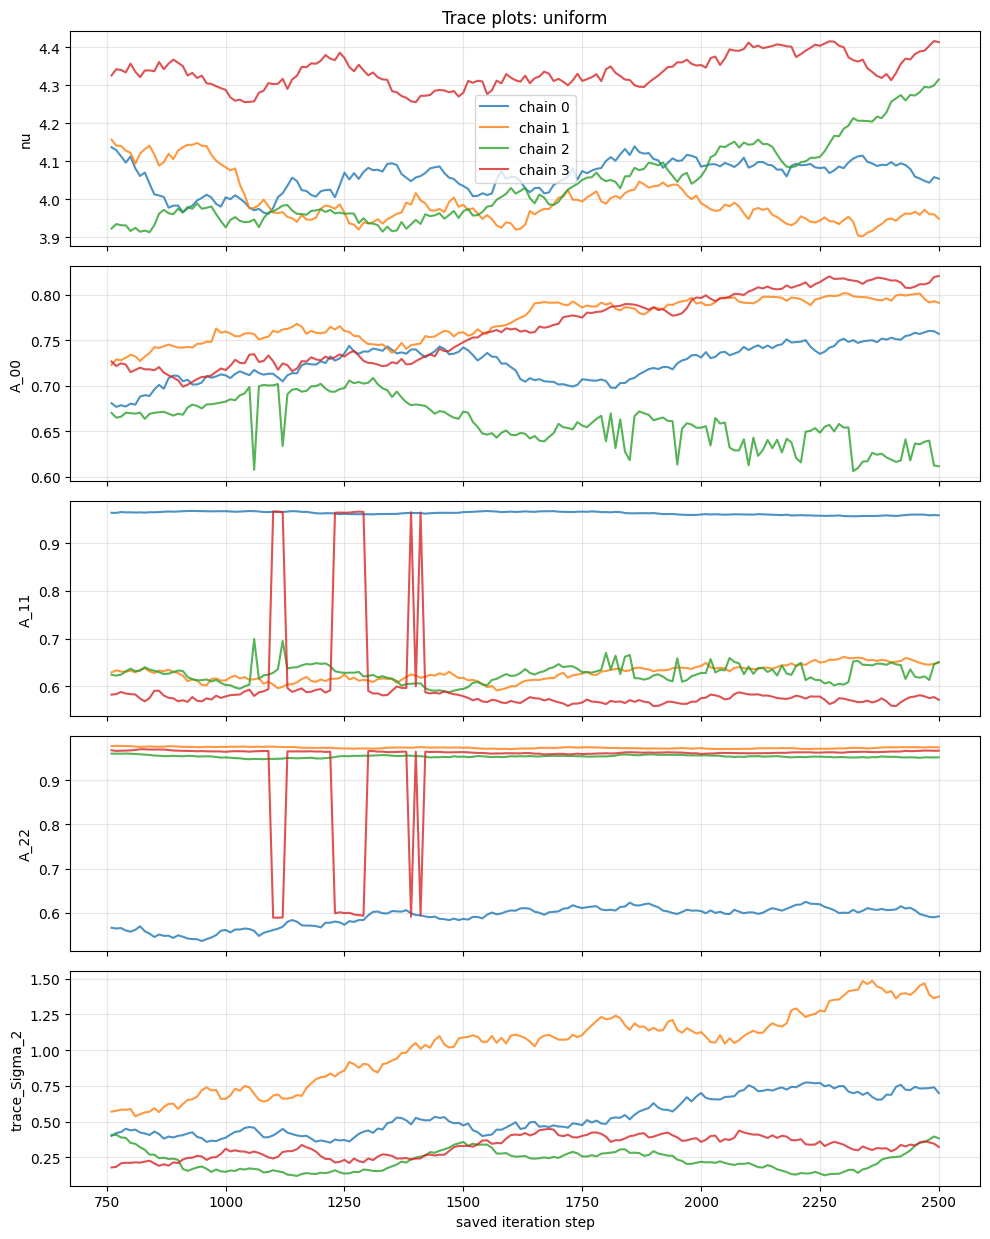

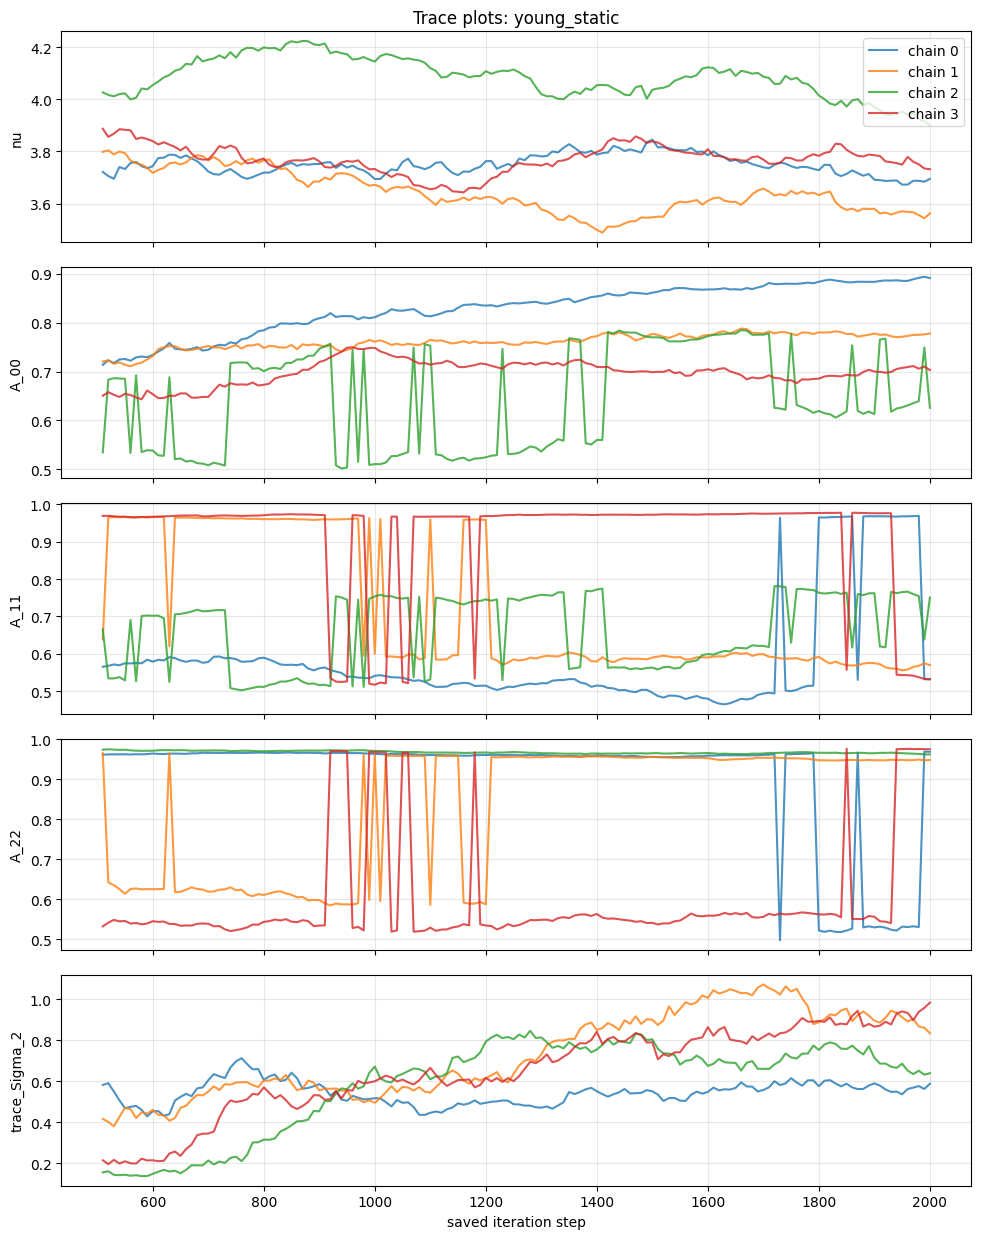

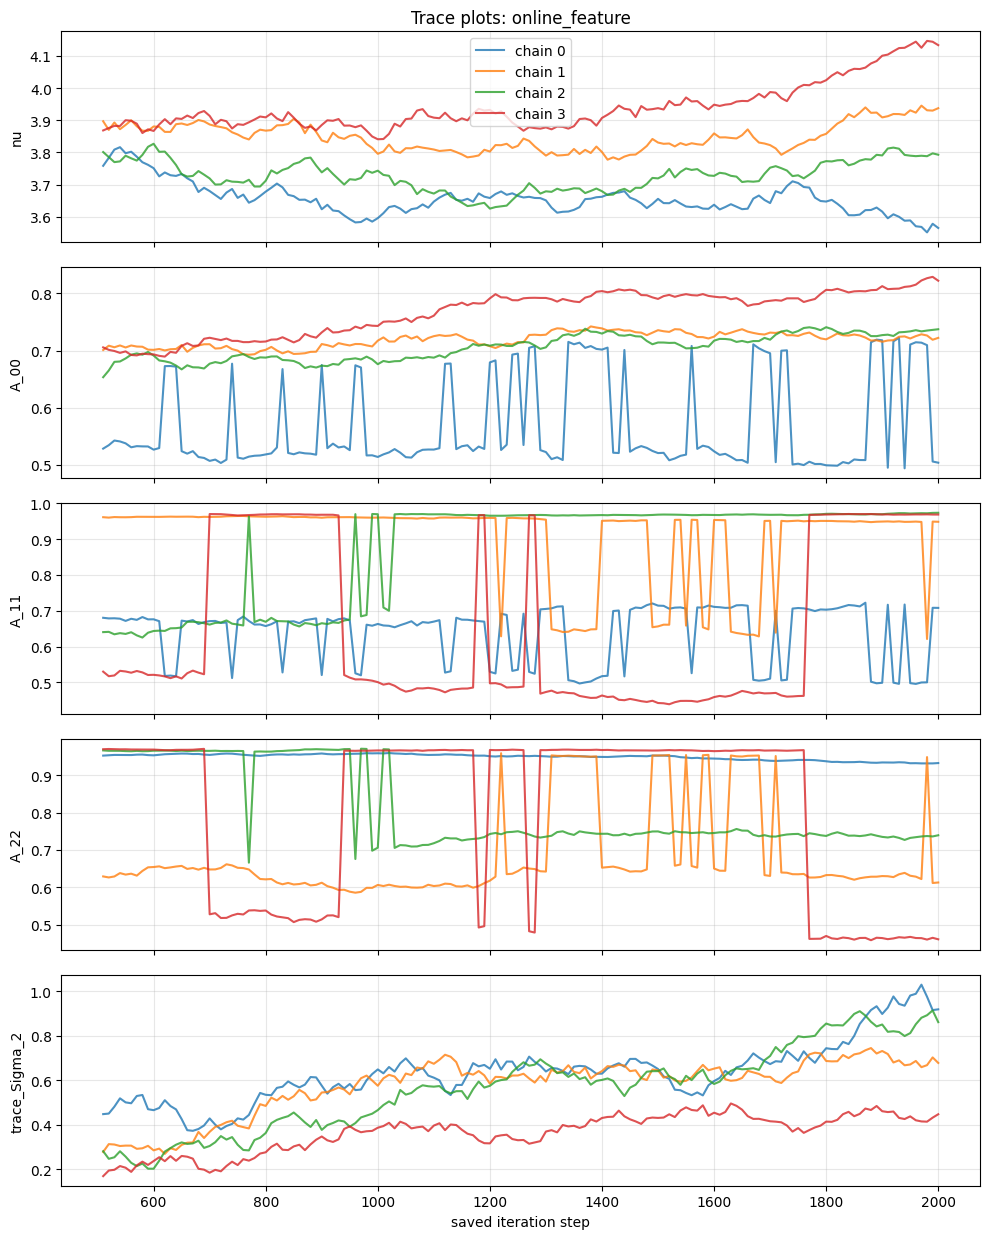

In [93]:
TRACE_VARS = ["nu", "A_00", "A_11", "A_22", "trace_Sigma_2"]

for method_name, out in method_diagnostics.items():
    plot_traces(out["chain_dfs"], TRACE_VARS, method_name)

Generate rank plots to check mixing and cross-chain agreement visually.


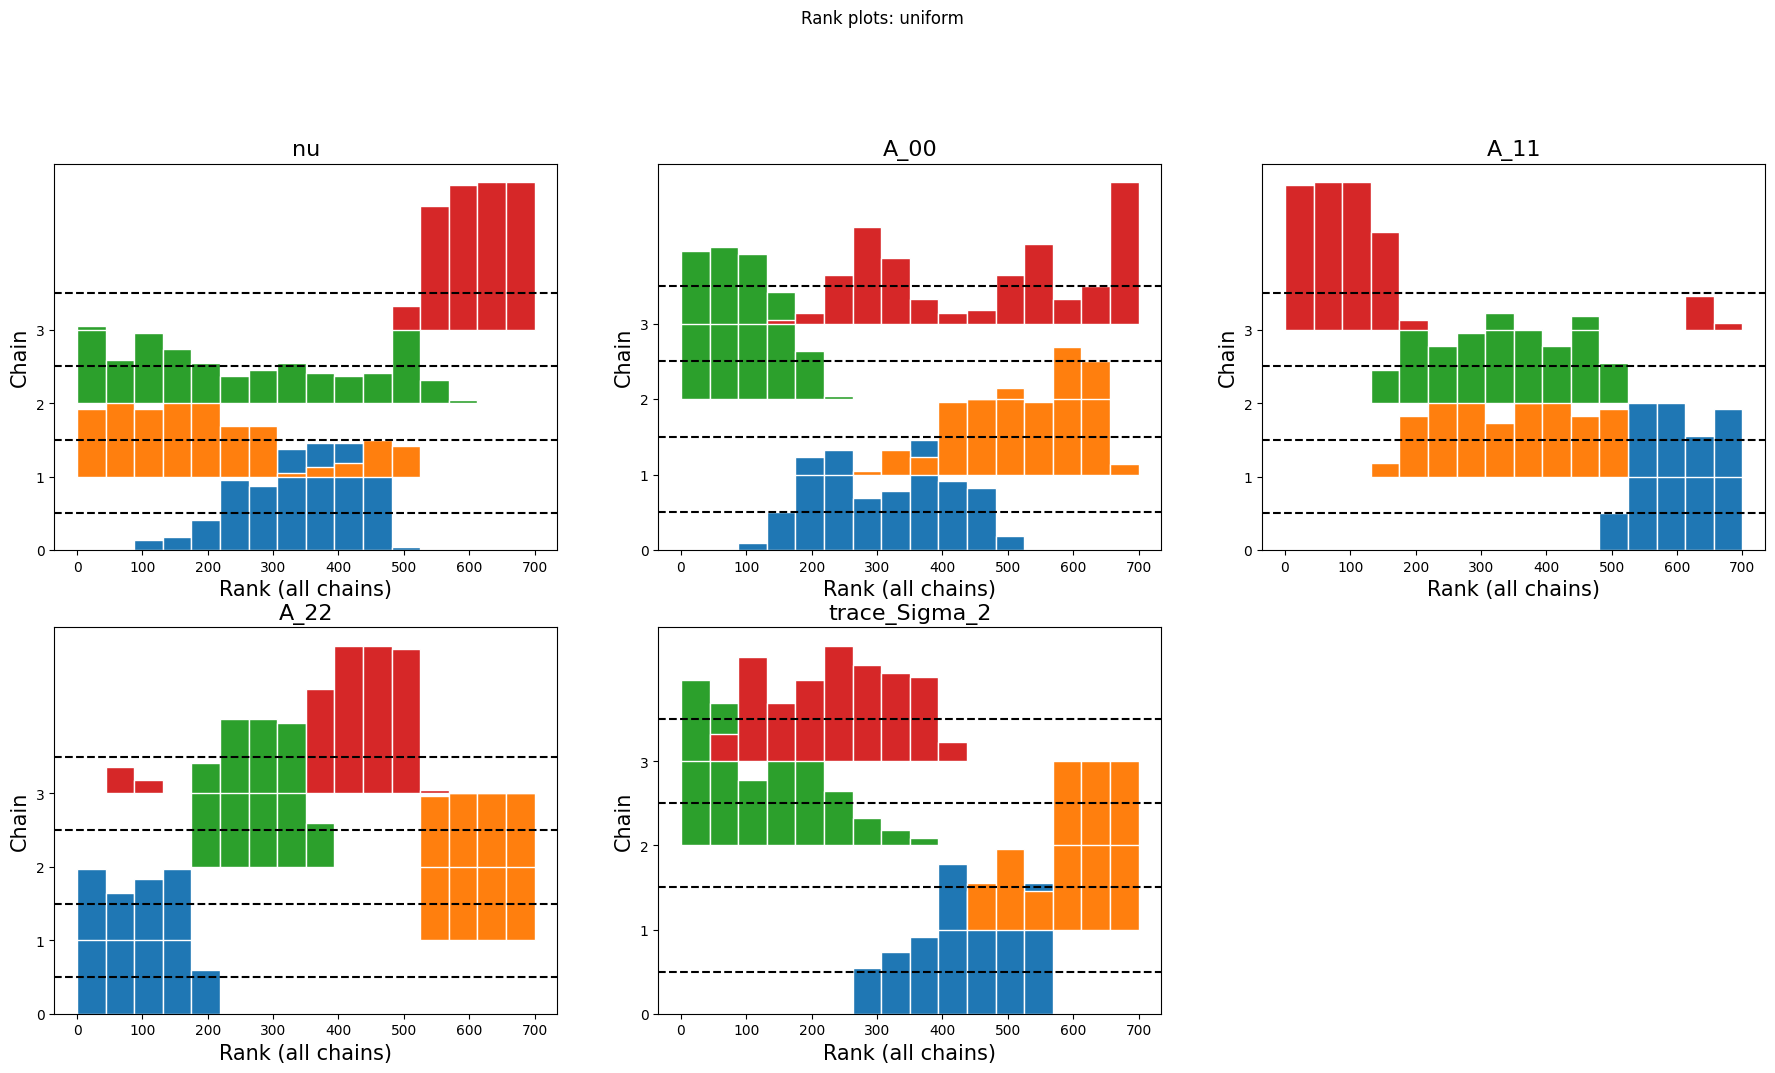

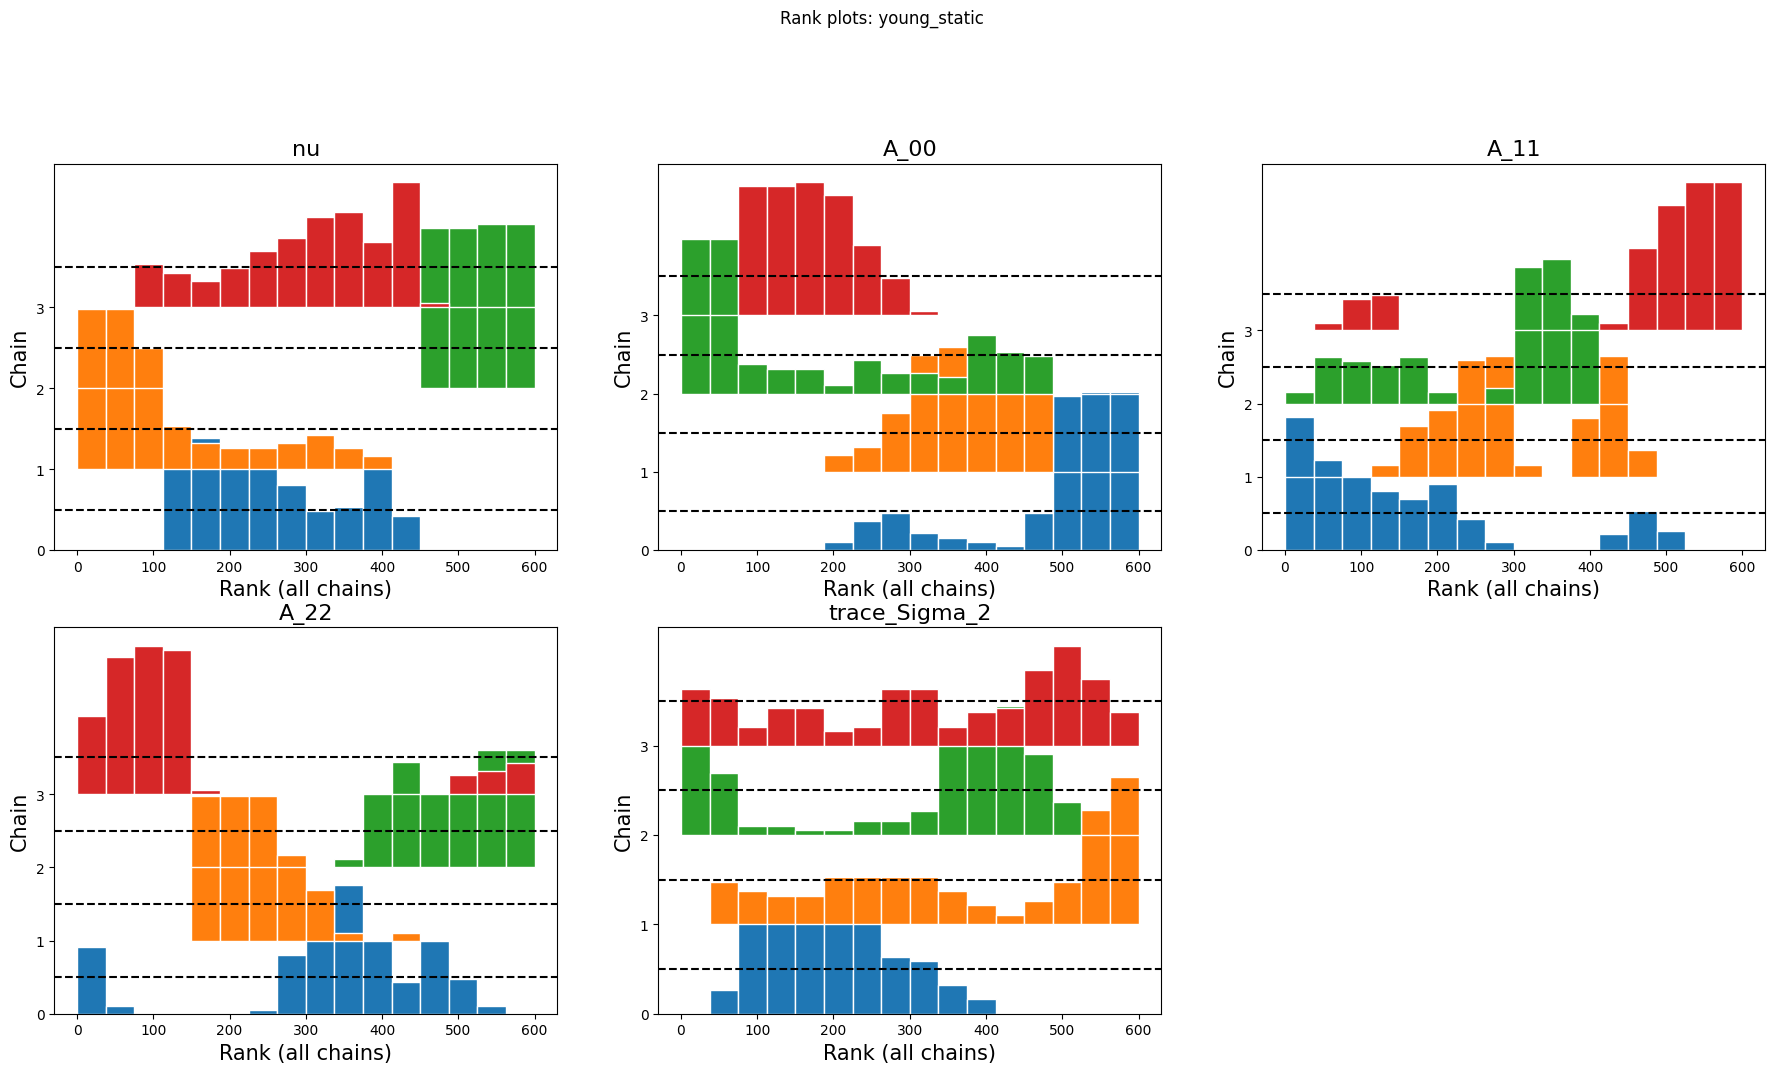

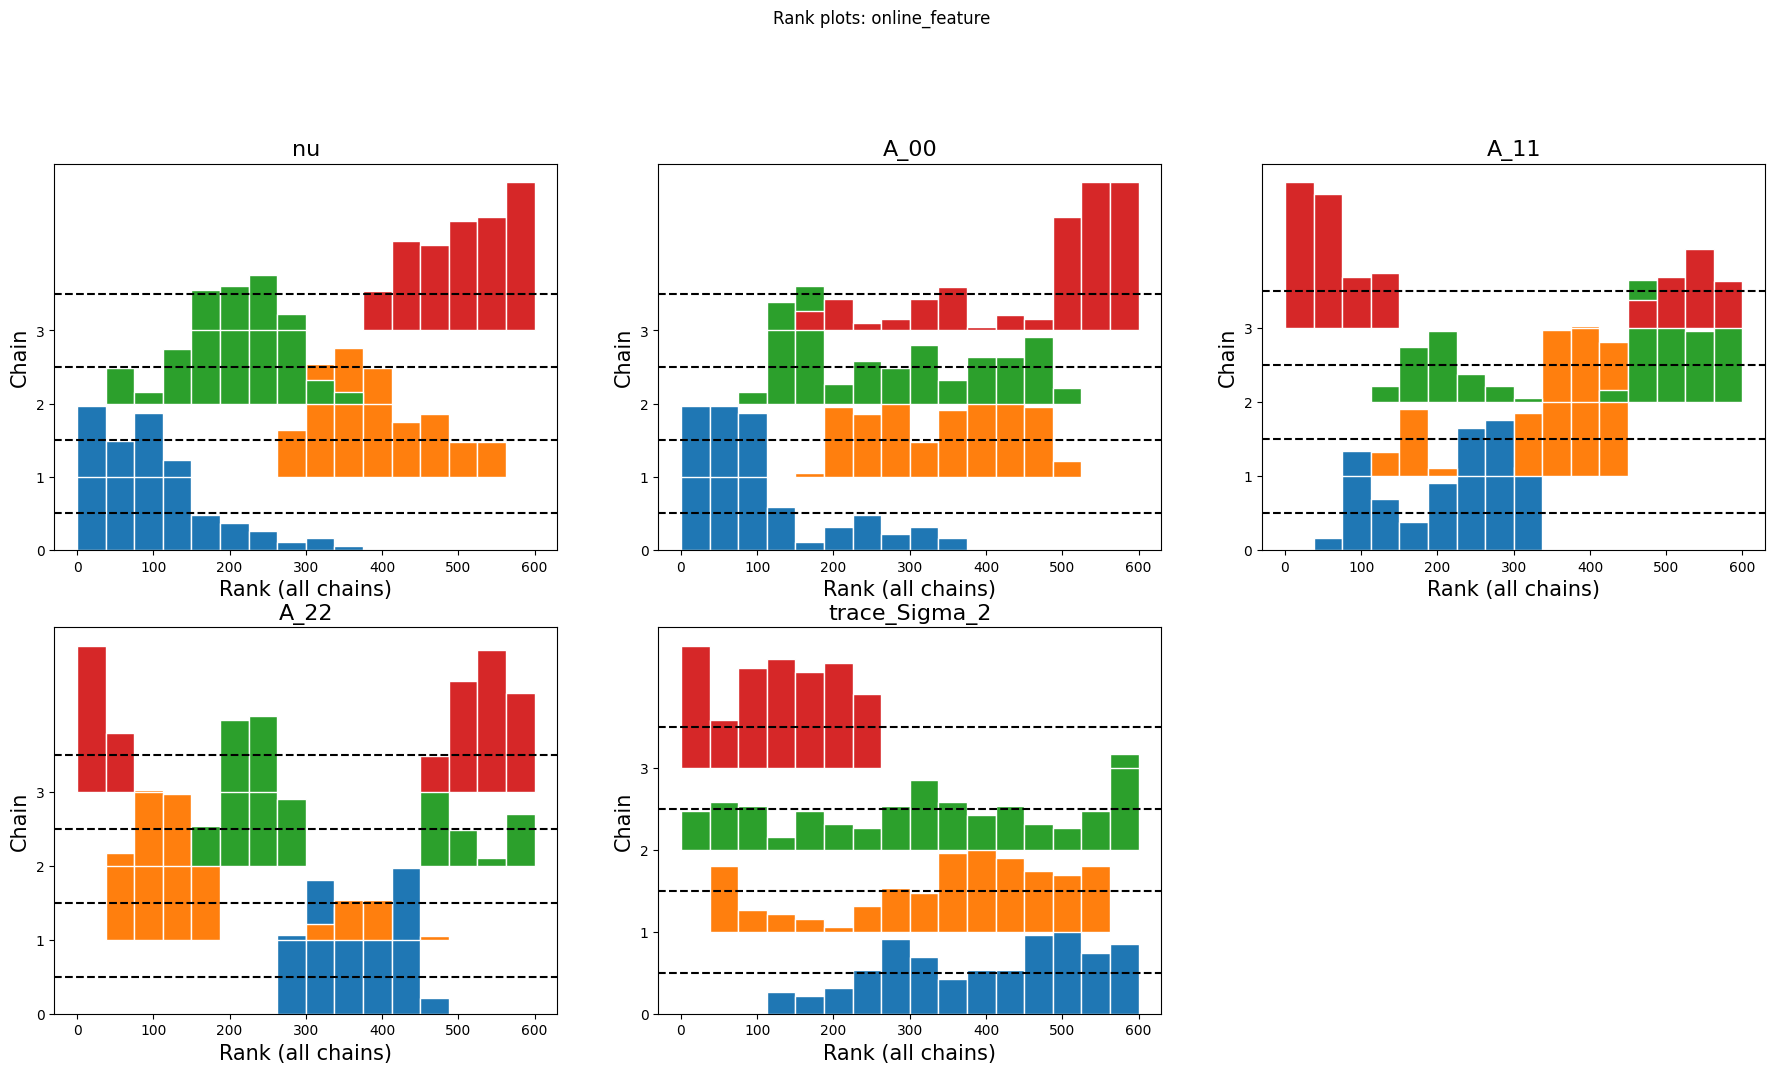

In [95]:
for method_name, out in method_diagnostics.items():
    az.plot_rank(out["idata"], var_names=TRACE_VARS)
    plt.suptitle(f"Rank plots: {method_name}", y=1.02)
    plt.show()

Plot posterior marginal summaries for the same representative parameters.


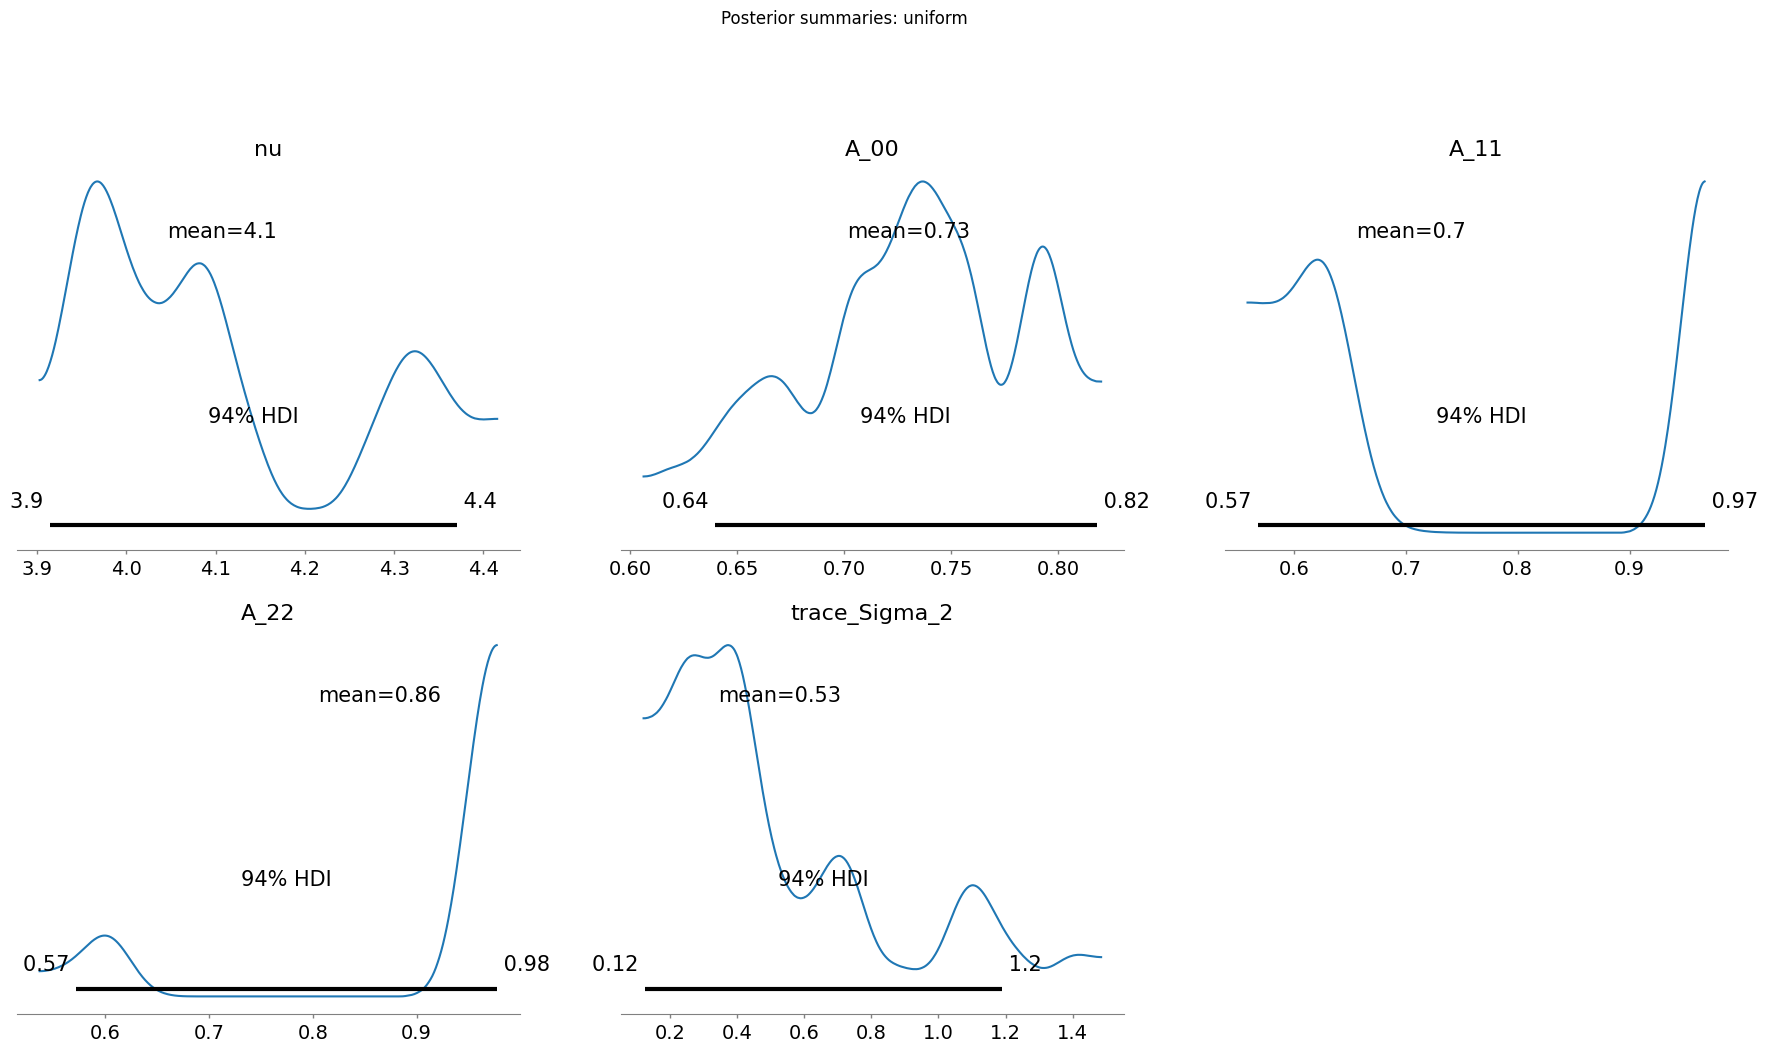

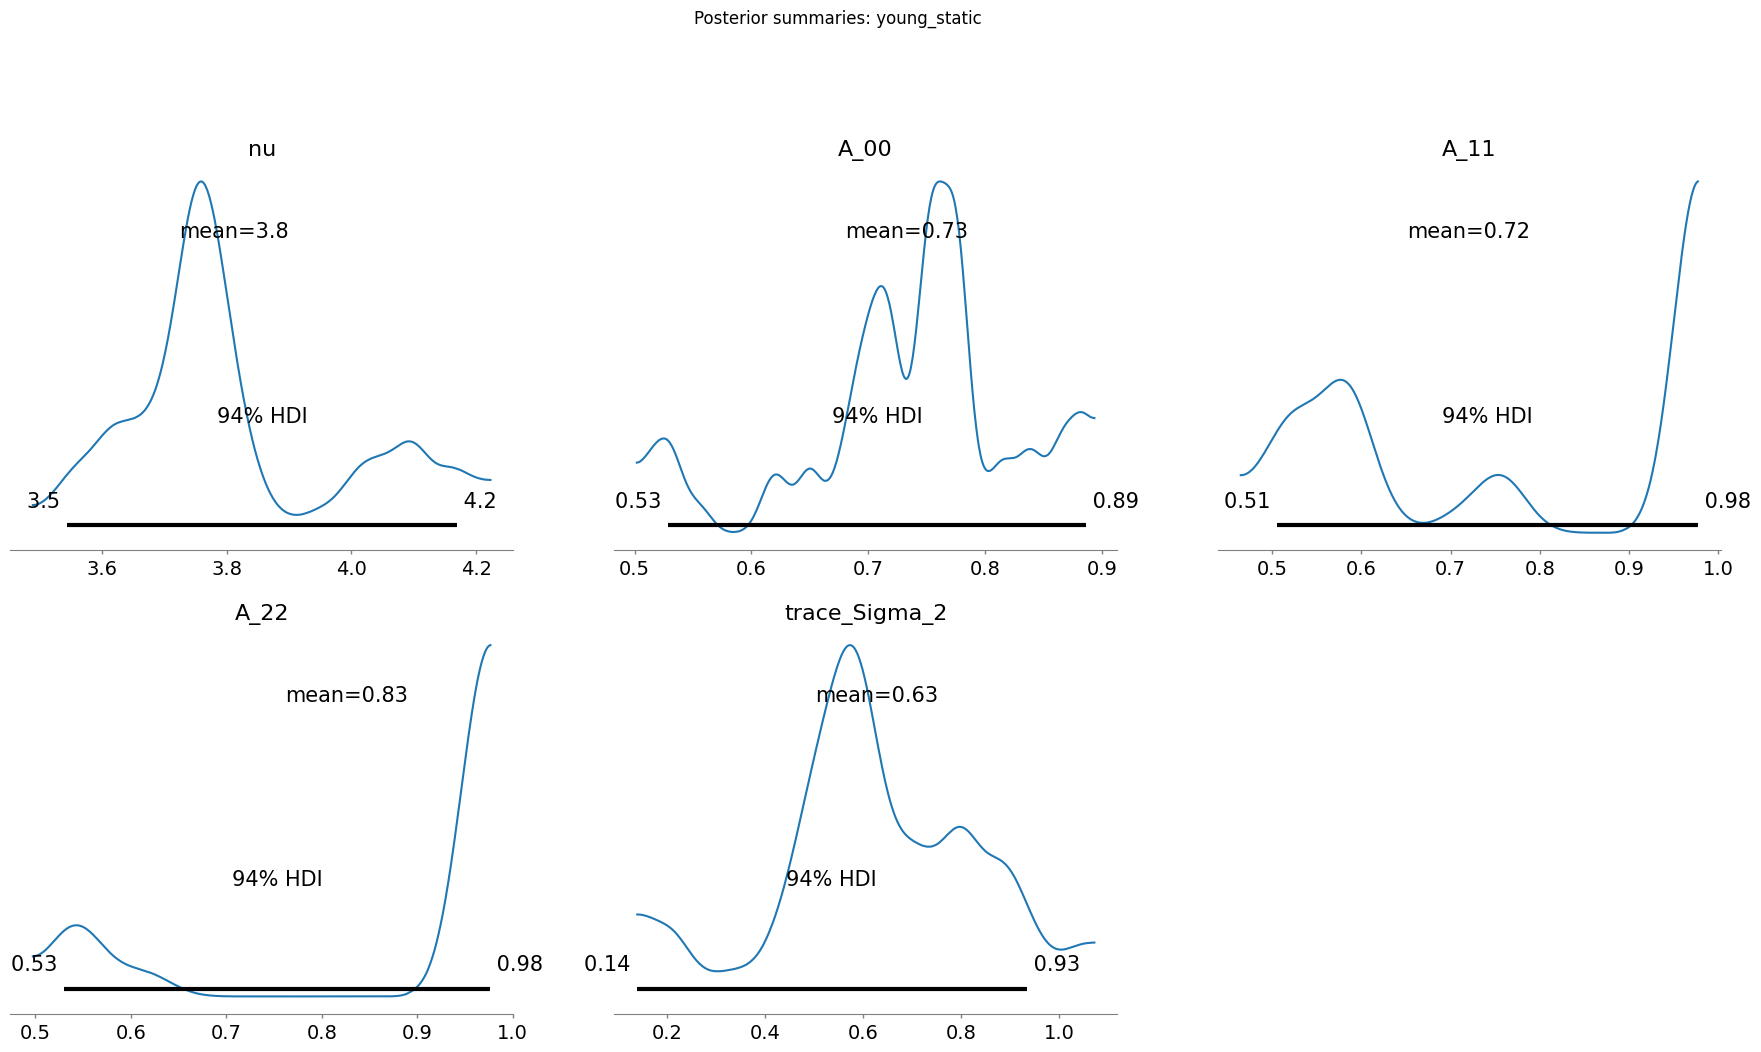

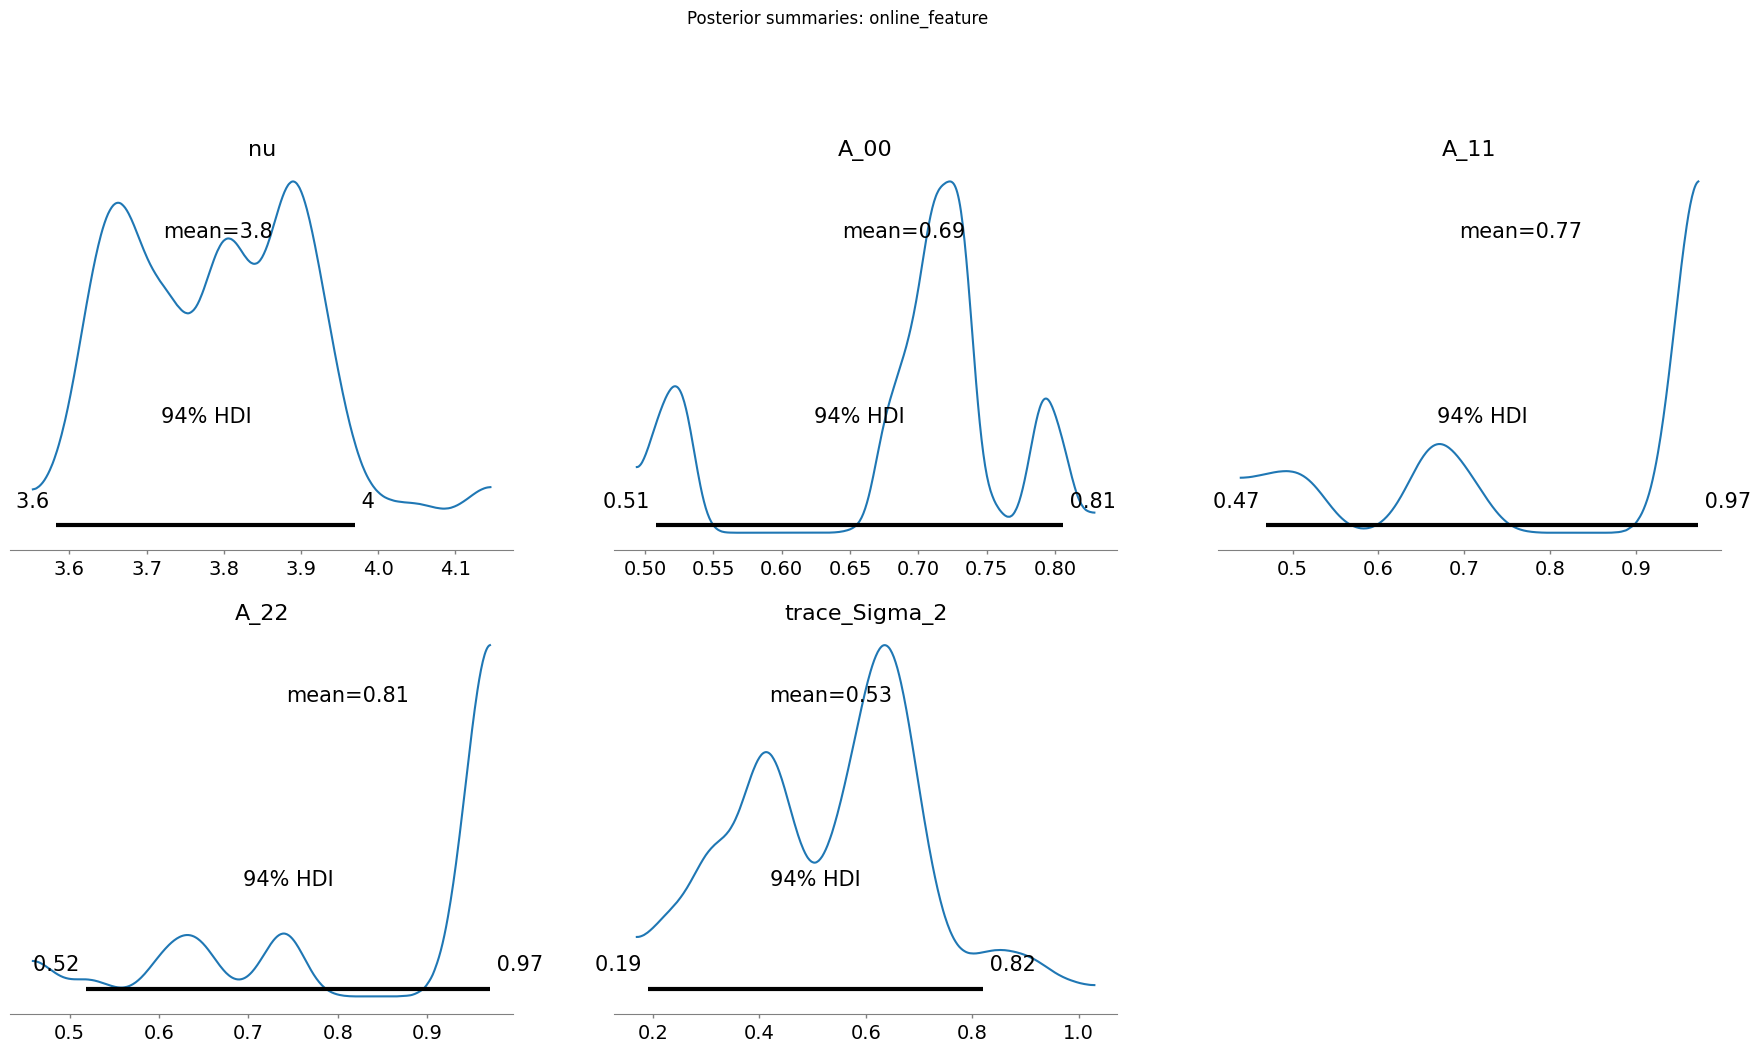

In [97]:
for method_name, out in method_diagnostics.items():
    az.plot_posterior(out["idata"], var_names=TRACE_VARS)
    plt.suptitle(f"Posterior summaries: {method_name}", y=1.02)
    plt.show()

Define a simple autocorrelation helper for single-chain diagnostics.


In [99]:
def autocorr(x, max_lag=100):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    var = np.dot(x, x)
    if var <= 0:
        return np.ones(max_lag + 1)

    acf = [1.0]
    for lag in range(1, max_lag + 1):
        acf.append(np.dot(x[:-lag], x[lag:]) / var)
    return np.array(acf)

Define an autocorrelation plotting helper for saved posterior draws.


In [101]:
def plot_acf_from_single_chain(df, vars_to_plot, method_name, max_lag=100):
    n_vars = len(vars_to_plot)
    fig, axes = plt.subplots(n_vars, 1, figsize=(8, 2.5 * n_vars), sharex=True)

    if n_vars == 1:
        axes = [axes]

    for ax, v in zip(axes, vars_to_plot):
        acf = autocorr(df[v].to_numpy(), max_lag=max_lag)
        ax.bar(np.arange(max_lag + 1), acf, width=1.0)
        ax.set_ylabel(v)
        ax.grid(alpha=0.3)

    axes[0].set_title(f"Autocorrelation: {method_name}")
    axes[-1].set_xlabel("lag")
    plt.tight_layout()
    plt.show()

Measure gradient RMSE for the uniform stochastic-gradient estimator on the development segment.


In [103]:
def grad_rmse_uniform(params, y, blocks_df, M=4, n_rep=50, seed=0):
    key = jax.random.PRNGKey(seed)
    g_full = full_grad_fn(params, y)
    errs = []

    for _ in range(n_rep):
        key, subkey = jax.random.split(key)
        g_hat, _ = uniform_stochastic_grad(params, y, blocks_df, M=M, rng_key=subkey)
        errs.append(float(tree_rmse(g_hat, g_full)))

    return np.mean(errs), np.std(errs)

Measure gradient RMSE for the static-TASS estimator on the same benchmark segment.


In [105]:
def grad_rmse_young(params, y, blocks_df, emit_probs, trans_probs,
                    M_emit=2, M_trans=2, n_rep=50, seed=0):
    key = jax.random.PRNGKey(seed)
    g_full = full_grad_fn(params, y)
    errs = []

    for _ in range(n_rep):
        key, subkey = jax.random.split(key)
        g_hat, _ = young_static_tass_grad(
            params=params,
            y=y,
            blocks_df=blocks_df,
            emit_probs=emit_probs,
            trans_probs=trans_probs,
            M_emit=M_emit,
            M_trans=M_trans,
            rng_key=subkey,
        )
        errs.append(float(tree_rmse(g_hat, g_full)))

    return np.mean(errs), np.std(errs)

Measure gradient RMSE for the online feature-informed estimator.


In [107]:
def grad_rmse_online(params, y, blocks_df, W, emit_models, trans_models,
                     M_emit=2, M_trans=2, n_rep=50, seed=0, explore_eps=0.05):
    key = jax.random.PRNGKey(seed)
    g_full = full_grad_fn(params, y)
    errs = []

    for _ in range(n_rep):
        key, subkey = jax.random.split(key)
        g_hat, _ = online_feature_grad(
            params=params,
            y=y,
            blocks_df=blocks_df,
            W=W,
            emit_models=emit_models,
            trans_models=trans_models,
            M_emit=M_emit,
            M_trans=M_trans,
            rng_key=subkey,
            use_online_probs=True,
            explore_eps=explore_eps,
        )
        errs.append(float(tree_rmse(g_hat, g_full)))

    return np.mean(errs), np.std(errs)



Compare gradient quality across the three stochastic-gradient constructions.


In [117]:
import numpy as np
import jax.numpy as jnp

DIAG_FLOOR = 1e-4

def inv_softplus(x):
    x = np.asarray(x, dtype=np.float32)
    return np.log(np.expm1(np.maximum(x, 1e-6))).astype(np.float32)

def params_from_transformed(A_np, mu_np, Sigma_np, nu_np):
    A_np = np.asarray(A_np, dtype=np.float32)
    A_np = np.clip(A_np, 1e-6, 1.0)
    A_np = A_np / A_np.sum(axis=1, keepdims=True)

    mu_np = np.asarray(mu_np, dtype=np.float32)
    Sigma_np = np.asarray(Sigma_np, dtype=np.float32)

    eye = np.eye(Sigma_np.shape[-1], dtype=np.float32)
    L_np = np.stack(
        [np.linalg.cholesky(Sigma_np[k] + 1e-6 * eye) for k in range(Sigma_np.shape[0])],
        axis=0,
    )

    chol_lower_raw = np.tril(L_np, k=-1)
    diag_vals = np.diagonal(L_np, axis1=1, axis2=2).copy()
    diag_vals = np.maximum(diag_vals - DIAG_FLOOR, 1e-6)
    chol_diag_raw = inv_softplus(diag_vals)

    nu_raw = np.array(inv_softplus(max(float(nu_np) - 2.0, 1e-6)), dtype=np.float32)

    return {
        "trans_logits": jnp.array(np.log(A_np), dtype=jnp.float32),
        "mu": jnp.array(mu_np, dtype=jnp.float32),
        "chol_lower_raw": jnp.array(chol_lower_raw, dtype=jnp.float32),
        "chol_diag_raw": jnp.array(chol_diag_raw, dtype=jnp.float32),
        "nu_raw": jnp.array(nu_raw, dtype=jnp.float32),
    }

def artifact_base(run_dir: Path, stem: str) -> Path:
    artifacts_dir = run_dir / "artifacts"
    if artifacts_dir.exists():
        return artifacts_dir / stem
    return run_dir / stem

stage2_dir = DATA_DIR / "stage2_exact_student_hmm"
with np.load(stage2_dir / "fitted_params.npz") as npz:
    params_ref = params_from_transformed(
        npz["A"],
        npz["mu"],
        npz["Sigma"],
        float(np.asarray(npz["nu"]).reshape(-1)[0]),
    )

returns_std_df = read_table(DATA_DIR / "returns_daily_standardised").copy()
asset_cols = [c for c in returns_std_df.columns if c != "date"]
R_full = jnp.asarray(returns_std_df[asset_cols].to_numpy(), dtype=jnp.float32)

T_DEV = min(800, R_full.shape[0])
R_dev = R_full[:T_DEV]

blocks_df = read_table(DATA_DIR / "stage3_buffered_gradients" / "blocks_L10_B10_dev").copy()

young_run = METHOD_DIRS["young_static"]
emit_probs = np.load(artifact_base(young_run, "emit_probs").with_suffix(".npy"))
trans_probs = np.load(artifact_base(young_run, "trans_probs").with_suffix(".npy"))

online_run = METHOD_DIRS["online_feature"]
W = np.load(artifact_base(online_run, "W_block_features").with_suffix(".npy"))

class FrozenLinearModel:
    def __init__(self, beta):
        self.beta = np.asarray(beta, dtype=np.float64)

    def predict(self, X):
        return np.asarray(X, dtype=np.float64) @ self.beta

def load_online_models_from_run(run_dir: Path):
    emit_beta_df = read_table(artifact_base(run_dir, "emit_model_coefficients"))
    trans_beta_df = read_table(artifact_base(run_dir, "trans_model_coefficients"))

    emit_cols = sorted(
        [c for c in emit_beta_df.columns if c.startswith("emit_state_")],
        key=lambda c: int(c.split("_")[-1]),
    )
    trans_cols = sorted(
        [c for c in trans_beta_df.columns if c.startswith("trans_state_")],
        key=lambda c: int(c.split("_")[-1]),
    )

    emit_models = [FrozenLinearModel(emit_beta_df[c].to_numpy()) for c in emit_cols]
    trans_models = [FrozenLinearModel(trans_beta_df[c].to_numpy()) for c in trans_cols]
    return emit_models, trans_models

emit_models, trans_models = load_online_models_from_run(online_run)

print("Loaded params_ref, R_dev, blocks_df, emit/trans probs, W, and online models.")
print("R_dev shape:", tuple(R_dev.shape))
print("blocks_df shape:", blocks_df.shape)
print("emit_probs shape:", emit_probs.shape)
print("trans_probs shape:", trans_probs.shape)
print("W shape:", W.shape)


Loaded params_ref, R_dev, blocks_df, emit/trans probs, W, and online models.
R_dev shape: (800, 5)
blocks_df shape: (38, 9)
emit_probs shape: (3, 96)
trans_probs shape: (3, 96)
W shape: (96, 37)


In [119]:
online_run = METHOD_DIRS["online_feature"]
W = np.load(artifact_base(online_run, "W_block_features").with_suffix(".npy"))

class FrozenLinearModel:
    def __init__(self, beta):
        self.beta = np.asarray(beta, dtype=np.float64)

    def predict(self, X):
        return np.asarray(X, dtype=np.float64) @ self.beta

def load_online_models_from_run(run_dir: Path):
    emit_beta_df = read_table(artifact_base(run_dir, "emit_model_coefficients"))
    trans_beta_df = read_table(artifact_base(run_dir, "trans_model_coefficients"))

    emit_cols = sorted(
        [c for c in emit_beta_df.columns if c.startswith("emit_state_")],
        key=lambda c: int(c.split("_")[-1]),
    )
    trans_cols = sorted(
        [c for c in trans_beta_df.columns if c.startswith("trans_state_")],
        key=lambda c: int(c.split("_")[-1]),
    )

    emit_models = [FrozenLinearModel(emit_beta_df[c].to_numpy()) for c in emit_cols]
    trans_models = [FrozenLinearModel(trans_beta_df[c].to_numpy()) for c in trans_cols]
    return emit_models, trans_models

emit_models, trans_models = load_online_models_from_run(online_run)


In [125]:
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree


In [127]:
grad_eval_rows = []

# Use your short dev segment from Stage 3
rmse_u_mean, rmse_u_std = grad_rmse_uniform(params_ref, R_dev, blocks_df, M=4, n_rep=50, seed=1)
grad_eval_rows.append({"method": "uniform", "rmse_mean": rmse_u_mean, "rmse_std": rmse_u_std})

rmse_y_mean, rmse_y_std = grad_rmse_young(params_ref, R_dev, blocks_df, emit_probs[:, :len(blocks_df)], trans_probs[:, :len(blocks_df)], n_rep=50, seed=2)
grad_eval_rows.append({"method": "young_static", "rmse_mean": rmse_y_mean, "rmse_std": rmse_y_std})

rmse_o_mean, rmse_o_std = grad_rmse_online(params_ref, R_dev, blocks_df, W[:len(blocks_df)], emit_models, trans_models, n_rep=50, seed=3)
grad_eval_rows.append({"method": "online_feature", "rmse_mean": rmse_o_mean, "rmse_std": rmse_o_std})

grad_eval_df = pd.DataFrame(grad_eval_rows)
display(grad_eval_df.sort_values("rmse_mean"))

NameError: name 'full_grad_fn' is not defined

Compute filtered state probabilities, which are the ingredients for one-step-ahead prediction.


In [ ]:
def filtered_probs(params, y):
    A, pi, mu, Lchol, Sigma, nu = unpack_transformed(params)
    logpi = jnp.log(pi + 1e-32)
    logA = jnp.log(A + 1e-32)

    emission_lp = emission_loglik_matrix(y, mu, Lchol, nu)
    ll, log_alpha = forward_pass(logpi, logA, emission_lp)

    log_filter = log_alpha - jsp.special.logsumexp(log_alpha, axis=1, keepdims=True)
    return np.array(jnp.exp(log_filter)), np.array(A), np.array(emission_lp)

Define the one-step predictive log-likelihood calculation used in the held-out comparison.


In [ ]:
def one_step_predictive_loglik(params, y, holdout_start, holdout_end):
    """
    Computes one-step-ahead predictive log-likelihood on y[holdout_start:holdout_end+1],
    conditioning on the preceding observations.
    """
    filt, A_np, emission_lp = filtered_probs(params, y)

    vals = []
    for t in range(holdout_start, holdout_end + 1):
        if t == 0:
            continue

        pred_state = filt[t - 1] @ A_np
        log_pred = logsumexp(np.log(pred_state + 1e-32) + emission_lp[t])
        vals.append(log_pred)

    return np.array(vals)

Evaluate held-out predictive performance for the three posterior-mean fits.


In [64]:
# Example: final 20% as held-out
holdout_start = int(0.8 * len(R_np))
holdout_end = len(R_np) - 1

params_by_method = {
    method_name: load_posterior_mean_params(run_dir)
    for method_name, run_dir in METHOD_DIRS.items()
}

predictive_loglik_by_method = {}
pred_eval_rows = []

for method_name, params_method in params_by_method.items():
    pll = one_step_predictive_loglik(params_method, R, holdout_start, holdout_end)
    predictive_loglik_by_method[method_name] = pll
    pred_eval_rows.append({
        "method": method_name,
        "mean_pred_loglik": float(np.mean(pll)),
        "sum_pred_loglik": float(np.sum(pll)),
    })

pred_eval_df = pd.DataFrame(pred_eval_rows)
display(pred_eval_df.sort_values("mean_pred_loglik", ascending=False))



NameError: name 'R_np' is not defined

Load the smoothed state-probability outputs from all three SG-MCMC methods.


In [ ]:
smoothed_by_method = {
    method_name: read_table(summary_path(run_dir, "smoothed_state_probs"))
    for method_name, run_dir in METHOD_DIRS.items()
}

sm_uniform = smoothed_by_method["uniform"]
sm_young = smoothed_by_method["young_static"]
sm_online = smoothed_by_method["online_feature"]



Plot how the inferred highest-volatility regime probability evolves over time under each method.


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(sm_uniform["date"]), sm_uniform["state_2_prob"], label="uniform")
plt.plot(pd.to_datetime(sm_young["date"]), sm_young["state_2_prob"], label="young_static")
plt.plot(pd.to_datetime(sm_online["date"]), sm_online["state_2_prob"], label="online_feature")
plt.title("Smoothed probability of highest-volatility state over time")
plt.xlabel("date")
plt.ylabel("probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Define a helper that pools chains and reports posterior means, spreads, and quantiles.


In [ ]:
def posterior_summary_from_chain_dfs(chain_dfs, vars_to_summarise):
    all_draws = pd.concat(chain_dfs, axis=0, ignore_index=True)

    rows = []
    for v in vars_to_summarise:
        x = all_draws[v].to_numpy()
        rows.append({
            "variable": v,
            "mean": np.mean(x),
            "sd": np.std(x, ddof=1),
            "q025": np.quantile(x, 0.025),
            "median": np.quantile(x, 0.5),
            "q975": np.quantile(x, 0.975),
        })
    return pd.DataFrame(rows)

Display compact posterior summary tables for representative diagnostics variables.


In [ ]:
for method_name, out in method_diagnostics.items():
    print("\nPOSTERIOR SUMMARY:", method_name)
    display(posterior_summary_from_chain_dfs(out["chain_dfs"], TRACE_VARS))

Create a placeholder table for the sensitivity analyses proposed for future tuning sweeps.


In [ ]:
class FrozenLinearModel:
    def __init__(self, beta):
        self.beta = np.asarray(beta, dtype=np.float64)

    def predict(self, X):
        return np.asarray(X, dtype=np.float64) @ self.beta



def load_online_models_from_run(run_dir: Path):
    emit_beta_df = read_table(artifact_path(run_dir, "emit_model_coefficients"))
    trans_beta_df = read_table(artifact_path(run_dir, "trans_model_coefficients"))

    emit_models = [FrozenLinearModel(emit_beta_df[f"emit_state_{k}"].to_numpy()) for k in range(K)]
    trans_models = [FrozenLinearModel(trans_beta_df[f"trans_state_{k}"].to_numpy()) for k in range(K)]
    return emit_models, trans_models



def sensitivity_blocks_from_config(cfg):
    return make_block_table(T=T_DEV, L=int(cfg["L"]), B=int(cfg["B"]))



def sensitivity_grad_rmse(method_name: str, run_dir: Path, cfg):
    blocks_dev_cfg = sensitivity_blocks_from_config(cfg)

    if method_name == "uniform":
        return grad_rmse_uniform(
            params_ref,
            R_dev,
            blocks_dev_cfg,
            M=int(cfg["M"]),
            n_rep=30,
            seed=1,
        )

    if method_name == "young_static":
        emit_probs_run = np.load(artifact_path(run_dir, "emit_probs.npy"))[:, :len(blocks_dev_cfg)]
        trans_probs_run = np.load(artifact_path(run_dir, "trans_probs.npy"))[:, :len(blocks_dev_cfg)]
        return grad_rmse_young(
            params_ref,
            R_dev,
            blocks_dev_cfg,
            emit_probs_run,
            trans_probs_run,
            M_emit=int(cfg["M_EMIT"]),
            M_trans=int(cfg["M_TRANS"]),
            n_rep=30,
            seed=2,
        )

    if method_name == "online_feature":
        W_run = np.load(artifact_path(run_dir, "W_block_features.npy"))[:len(blocks_dev_cfg)]
        emit_models_run, trans_models_run = load_online_models_from_run(run_dir)
        return grad_rmse_online(
            params_ref,
            R_dev,
            blocks_dev_cfg,
            W_run,
            emit_models_run,
            trans_models_run,
            M_emit=int(cfg["M_EMIT"]),
            M_trans=int(cfg["M_TRANS"]),
            n_rep=30,
            seed=3,
            explore_eps=float(cfg.get("EXPLORE_EPS", 0.05)),
        )

    raise ValueError(f"Unknown method: {method_name}")



def sensitivity_row_for_run(method_name: str, run_dir: Path):
    cfg = load_run_config(run_dir)
    chain_dfs, runtimes = load_chain_samples(run_dir)
    _, diag_df = compute_mcmc_diagnostics(chain_dfs, runtimes=runtimes, monitored_vars=MONITORED_VARS)

    params_run = load_posterior_mean_params(run_dir)
    pll = one_step_predictive_loglik(params_run, R, holdout_start, holdout_end)
    grad_rmse_mean, grad_rmse_std = sensitivity_grad_rmse(method_name, run_dir, cfg)

    row = {
        "method": method_name,
        "run_slug": run_dir.name,
        "n_chains": len(chain_dfs),
        "L": int(cfg["L"]),
        "B": int(cfg["B"]),
        "mean_pred_loglik": float(np.mean(pll)),
        "sum_pred_loglik": float(np.sum(pll)),
        "grad_rmse_mean": float(grad_rmse_mean),
        "grad_rmse_std": float(grad_rmse_std),
        "max_rhat": float(diag_df["rhat"].max()),
        "min_ess_bulk": float(diag_df["ess_bulk"].min()),
        "min_ess_tail": float(diag_df["ess_tail"].min()),
        "runtime_sec_mean": float(np.nanmean(runtimes)),
    }

    if "ess_bulk_per_sec" in diag_df.columns:
        row["min_ess_bulk_per_sec"] = float(diag_df["ess_bulk_per_sec"].min())
    else:
        row["min_ess_bulk_per_sec"] = np.nan

    if "ess_tail_per_sec" in diag_df.columns:
        row["min_ess_tail_per_sec"] = float(diag_df["ess_tail_per_sec"].min())
    else:
        row["min_ess_tail_per_sec"] = np.nan

    for key in [
        "M", "M_EMIT", "M_TRANS", "N_STEPS", "BURN_IN", "SAVE_EVERY",
        "N_WARMUP_UNIFORM", "ETA0", "GAMMA", "T0", "EXPLORE_EPS", "RIDGE", "DISCOUNT",
    ]:
        row[key] = cfg.get(key, np.nan)

    return row


sensitivity_rows = []

for method_name, method_root in METHOD_ROOTS.items():
    for run_dir in list_run_dirs(method_root):
        try:
            sensitivity_rows.append(sensitivity_row_for_run(method_name, run_dir))
        except Exception as exc:
            sensitivity_rows.append({
                "method": method_name,
                "run_slug": run_dir.name,
                "error": str(exc),
            })

sensitivity_df = pd.DataFrame(sensitivity_rows)

if not sensitivity_df.empty:
    write_table(sensitivity_df, RESULTS_DIR / "sensitivity_summary", index=False)
    display(sensitivity_df.sort_values(["method", "L", "B", "run_slug"]).reset_index(drop=True))
else:
    display(sensitivity_df)

